# Тестовое задание для Avito Data Science Bootcamp.

## Потапов Иван





# Как я решал задачу

## Идея

Нужно определить, перевёрнут ли текст на кропе, и выдать вероятность этого. Метрика Brier Score.

Размеченных данных нет, но для этой задачи они и не нужны. Если взять любую надпись, стоящую нормально, и перевернуть её, получится готовый пример перевёрнутого текста. Так я получал метки автоматически.

## С чего начал

Сначала взял готовую открытую модель из PaddleOCR — маленький классификатор PP-LCNet, который как раз определяет, перевёрнута ли строка текста. Каждый кроп прогоняю через неё дважды: как есть и перевёрнутым, и усредняю ответы. Если модель противоречит сама себе, итог уходит к 0.5, а не к уверенной ошибке. Уже это дало на тесте 0.922.

## Как проверял модель

Своих размеченных данных не было, поэтому валидацию собрал сам из двух частей. Первая — реальные фотографии с русским текстом из открытого датасета RusTitW: вырезал из них однострочные надписи и половину перевернул. Вторая — синтетика: написал генератор, который рисует русский и английский текст разными шрифтами на цветных плашках, обрезает его плотно, как это делает детектор, и ухудшает качество до уровня тестовых кропов.

Модель сжимает любой кроп до размера 80 на 160 пикселей, и я предположил, что длинным строкам это вредит. На реальных фото сохранение пропорций действительно помогло, но на тесте результат упал до 0.905. Разобравшись, я понял, что дело в плотности обрезки: в тесте текст вырезан вплотную, а на фото из RusTitW рамки размечены с запасом фона. Синтетика эту разницу увидела, а реальные фото нет. После этого я стал проверять каждую идею сразу на обеих частях валидации, а на самом тесте без меток смотреть, как часто модель противоречит сама себе.

## Дообучение и объединение моделей

Готовая модель обучалась в основном на китайском и английском тексте из документов, а в тесте - русский текст с рекламных баннеров. Я дообучил её на своей синтетике. На синтетических примерах она стала почти безошибочной, а на реальных фото лучше не стала: частично выучила стиль моего генератора.

Зато исходная и дообученная модели ошибаются на разных кропах, и вместе они работают лучше, чем по отдельности. Сначала я просто усреднил их ответы и подстроил уверенность - это дало 0.960. Потом подобрал, с каким весом учитывать каждую модель: дообученная получила примерно в два с лишним раза больший вес. Подбирал на одной половине валидации, проверял на другой. Итоговый результат на тесте 0.973.

## Итог

Финальное решение - ансамбль из двух версий небольшой модели PP-LCNet, по 1.7 миллиона параметров каждая, и по два прогона на каждый кроп.

## Что можно было бы улучшить

Дообучать модель не только на синтетике, но и на реальных фотографиях, чтобы она не подстраивалась под стиль генератора. Сделать синтетику разнообразнее: текст поверх настоящих фотографий, больше шрифтов. Попробовать ещё более компактную версию модели, чтобы решение работало быстрее.

In [1]:
!pip install -q -U transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 88.2 MB/s eta 0:00:00


In [49]:
!pip install -q wordfreq
!for p in fonts-dejavu fonts-liberation fonts-freefont-ttf fonts-paratype \
          fonts-noto-core fonts-roboto fonts-open-sans fonts-ubuntu; do \
     apt-get install -y -qq $p > /dev/null 2>&1 && echo "ok   $p" || echo "нет  $p"; \
  done

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 MB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.1/183.1 kB 9.7 MB/s eta 0:00:00
нет  /content/test_data/sample_submission.csv
нет  /content/test_data/sample_submission.csv
нет  /content/test_data/sample_submission.csv
нет  /content/test_data/sample_submission.csv
нет  /content/test_data/sample_submission.csv
нет  /content/test_data/sample_submission.csv
нет  /content/test_data/sample_submission.csv
нет  /content/test_data/sample_submission.csv


In [50]:
%%bash
pip install -q wordfreq
for p in fonts-dejavu fonts-liberation fonts-freefont-ttf fonts-paratype \
         fonts-noto-core fonts-roboto fonts-open-sans fonts-ubuntu; do
    apt-get install -y -qq $p > /dev/null 2>&1 && echo "ok   $p" || echo "нет  $p"
done

ok   fonts-dejavu
ok   fonts-liberation
ok   fonts-freefont-ttf
ok   fonts-paratype
ok   fonts-noto-core
ok   fonts-roboto
ok   fonts-open-sans
ok   fonts-ubuntu


In [2]:
import os
import random
import time
import zipfile
from pathlib import Path


import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import transformers
from transformers import AutoImageProcessor, AutoModelForImageClassification

In [26]:
import re

In [31]:
from PIL import ImageOps

In [51]:
from fontTools.ttLib import TTFont
from wordfreq import top_n_list
from PIL import ImageDraw, ImageFont, ImageFilter

In [3]:
SEED = 42

def set_seed(seed: int = SEED) -> None:
    """Фиксирует все источники случайности."""
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()
print("seed зафиксирован:", SEED)

seed зафиксирован: 42


### Знакомство с данными.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
!find /content/drive/MyDrive -name "*.zip"

/content/drive/MyDrive/test data avito/test.zip
/content/drive/MyDrive/test data avito/rustitw_test_real.zip


In [6]:
ZIP_ON_DRIVE = Path('/content/drive/MyDrive/test data avito/test.zip')

In [7]:
data_dir = Path('/content/test_data')
with zipfile.ZipFile(ZIP_ON_DRIVE) as z:
    z.extractall(data_dir)

images = sorted(
    p for p in data_dir.rglob('*')
    if p.suffix.lower() in {'.png', '.jpg', '.jpeg', '.webp'}
)
print("Количество изображений:", len(images))
print("Первые файлы:", [p.name for p in images[:5]])

Количество изображений: 20000
Первые файлы: ['test_00000.png', 'test_00001.png', 'test_00002.png', 'test_00003.png', 'test_00004.png']


In [8]:
rows = []
for p in images:
    with Image.open(p) as im:
        rows.append({'image_id': p.name, 'path': str(p),
                     'w': im.width, 'h': im.height, 'mode': im.mode})

df = pd.DataFrame(rows)
df['aspect'] = df.w / df.h

pd.set_option('display.width', 120)
print(df[['w', 'h', 'aspect']].describe(
    percentiles=[.01, .05, .25, .5, .75, .95, .99]).round(2))
print("\nЦветовые режимы:\n", df['mode'].value_counts())
print(f"\nВысота < 16 px:                  {(df.h < 16).mean():.1%}")
print(f"Почти квадратные (aspect < 1.5): {(df.aspect < 1.5).mean():.1%}")
print(f"Вертикальные (h > w):            {(df.h > df.w).mean():.1%}")

              w         h    aspect
count  20000.00  20000.00  20000.00
mean     357.60     64.40      6.22
std      318.93     59.34      4.27
min       25.00     10.00      0.72
1%        40.00     12.00      1.76
5%        61.00     16.00      2.32
25%      129.00     27.00      3.50
50%      238.00     42.00      4.89
75%      479.25     76.00      7.52
95%     1047.00    195.00     14.45
99%     1406.00    289.00     22.61
max     1599.00    492.00     49.67

Цветовые режимы:
 mode
RGB    20000
Name: count, dtype: int64

Высота < 16 px:                  4.8%
Почти квадратные (aspect < 1.5): 0.3%
Вертикальные (h > w):            0.0%


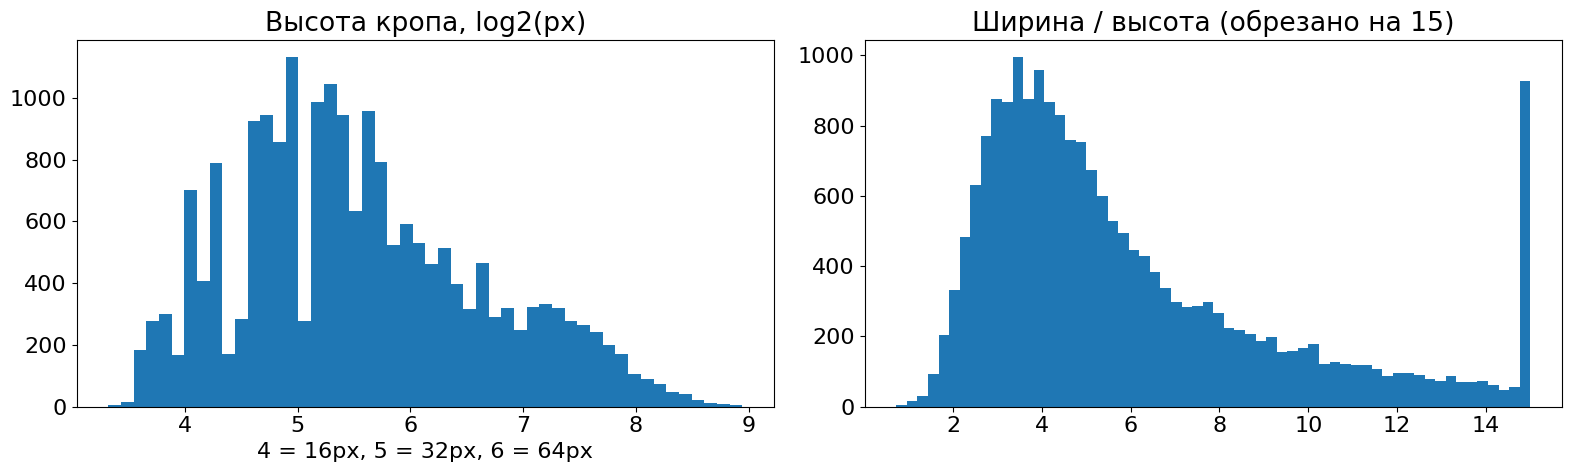

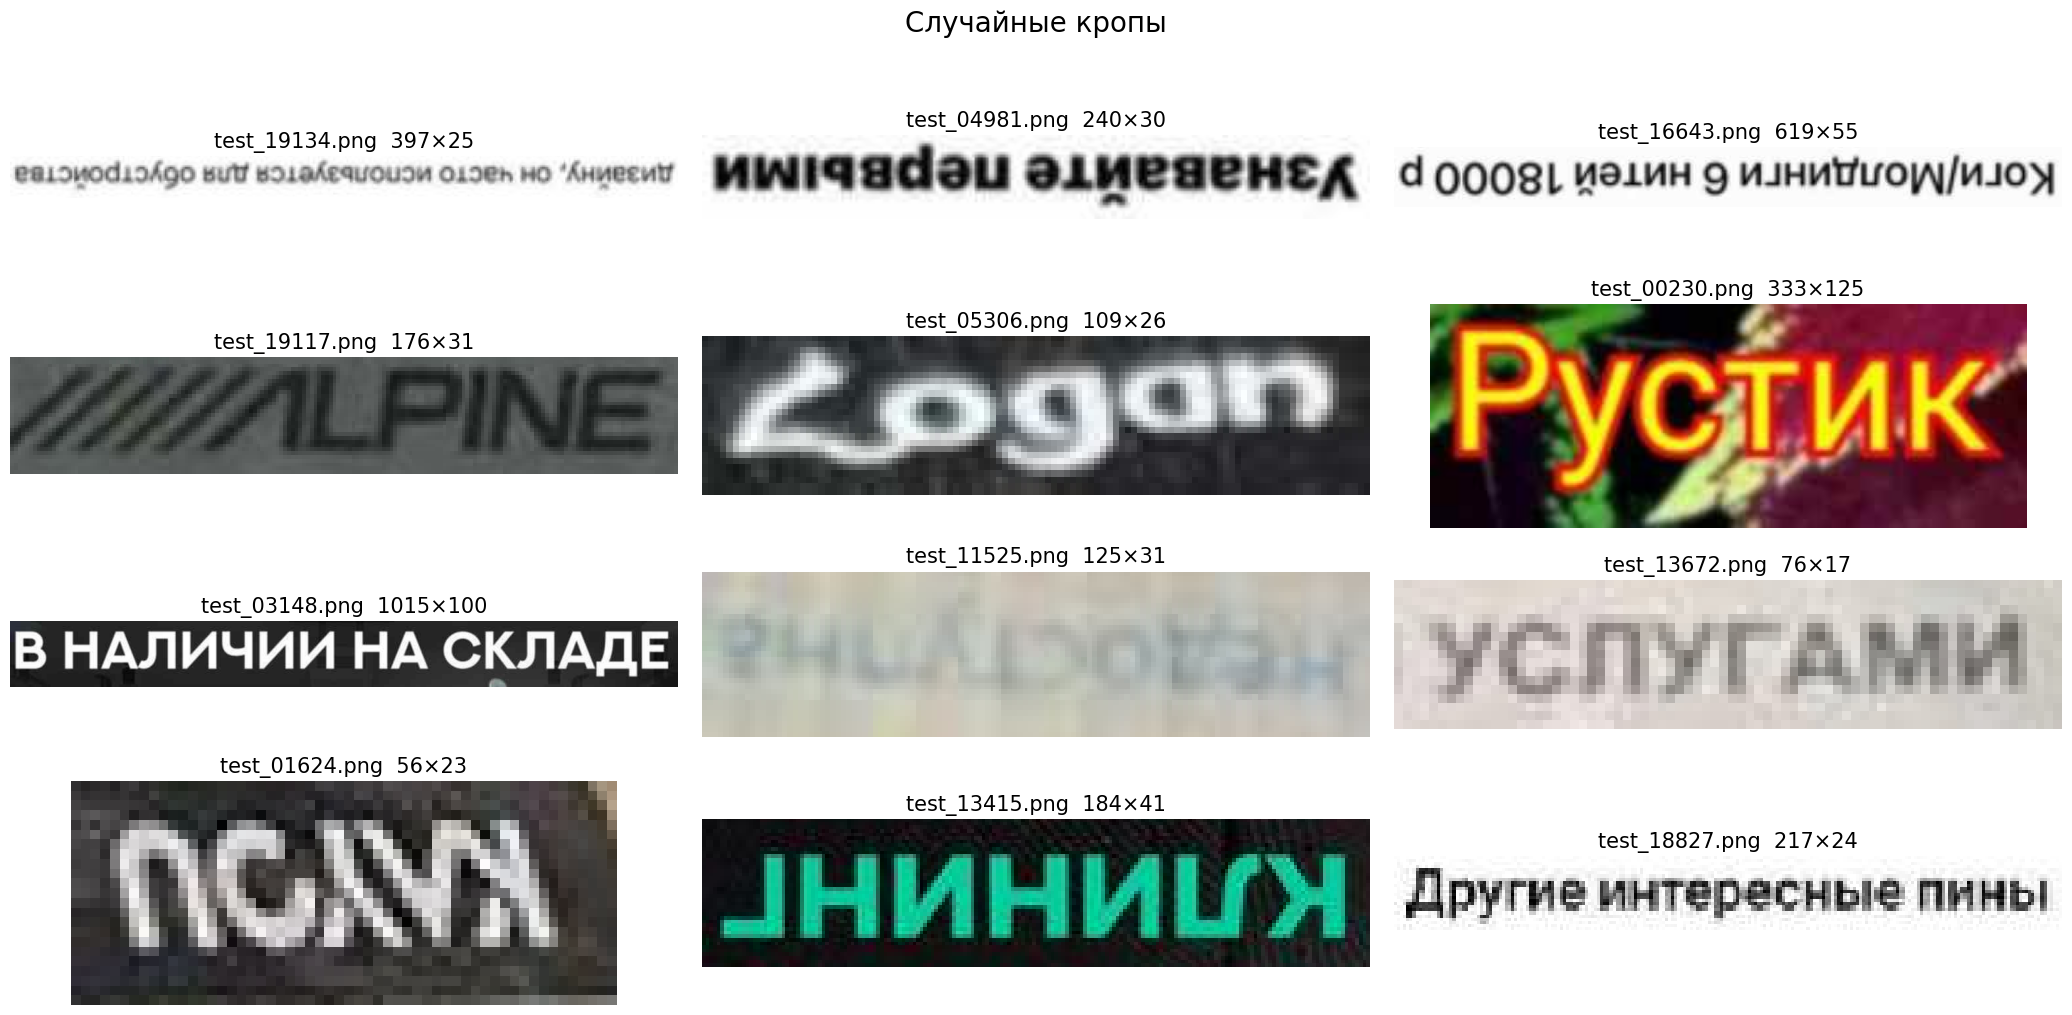

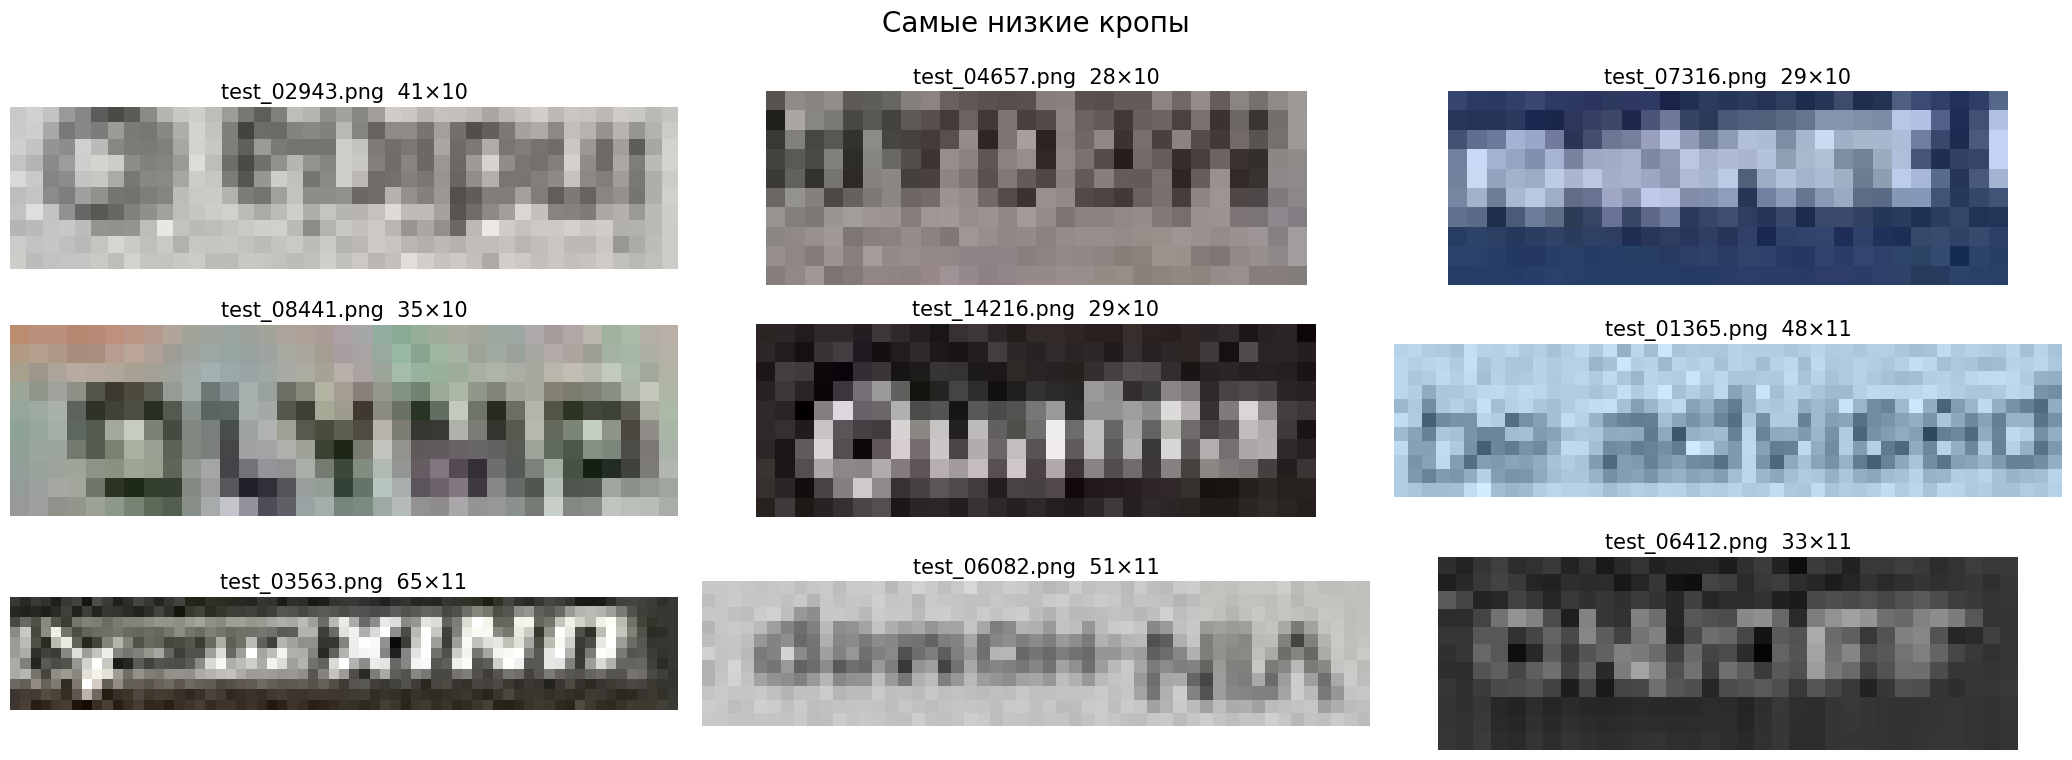

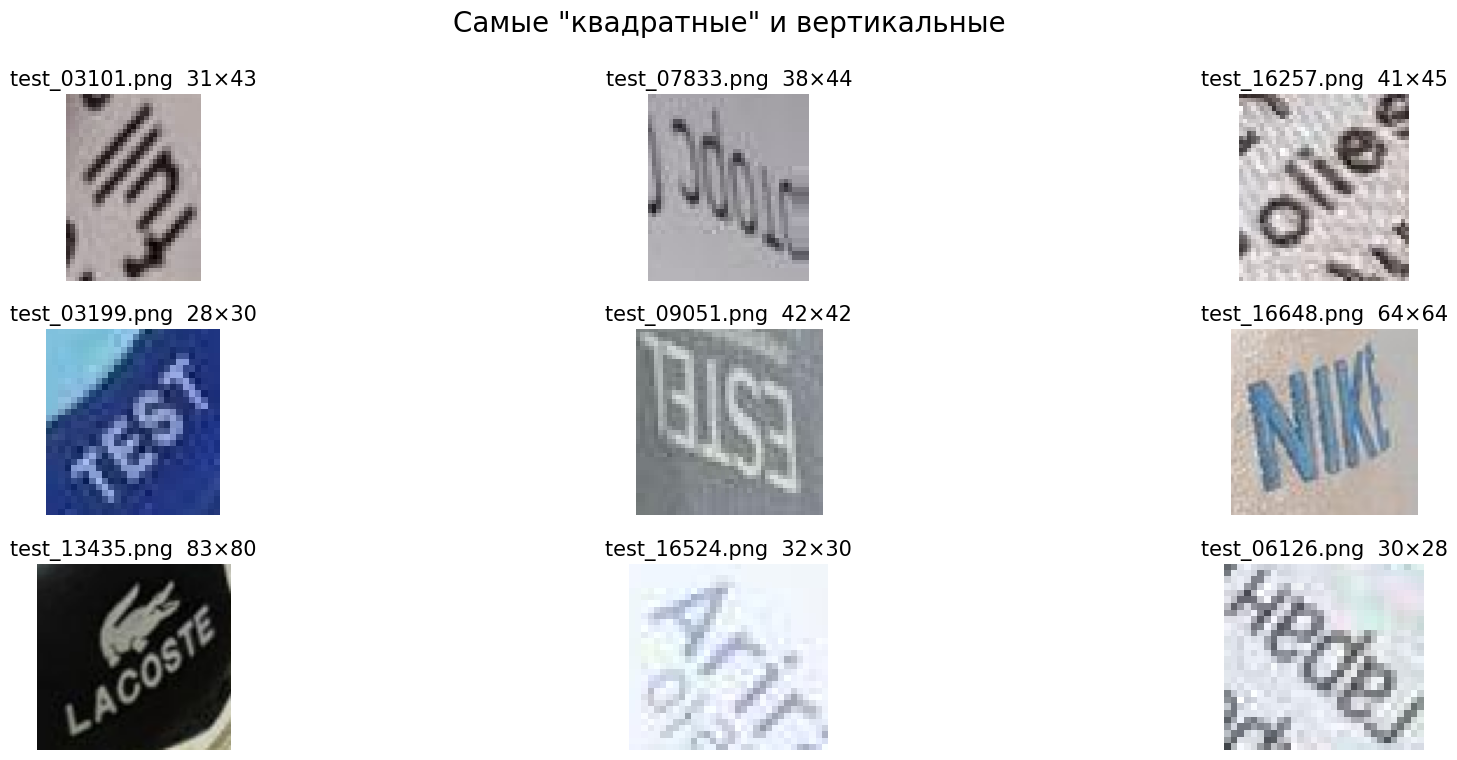

In [9]:
plt.rcParams.update({'font.size': 16})

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].hist(np.log2(df.h), bins=50)
axes[0].set_title('Высота кропа, log2(px)')
axes[0].set_xlabel('4 = 16px, 5 = 32px, 6 = 64px')
axes[1].hist(df.aspect.clip(upper=15), bins=60)
axes[1].set_title('Ширина / высота (обрезано на 15)')
plt.tight_layout(); plt.show()


def show_grid(sub_df, n_cols=3, title=''):
    """Показывает кропы крупно, в подписи имя файла и размер w×h."""
    n_rows = int(np.ceil(len(sub_df) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 2.6 * n_rows))
    for ax in np.ravel(axes):
        ax.axis('off')
    for ax, (_, r) in zip(np.ravel(axes), sub_df.iterrows()):
        ax.imshow(Image.open(r.path).convert('RGB'))
        ax.set_title(f"{r.image_id}  {r.w}×{r.h}", fontsize=15)
    fig.suptitle(title, fontsize=20)
    plt.tight_layout(); plt.show()


show_grid(df.sample(12, random_state=0), title='Случайные кропы')
show_grid(df.nsmallest(9, 'h'), title='Самые низкие кропы')
show_grid(df.nsmallest(9, 'aspect'), title='Самые "квадратные" и вертикальные')

h
28    563
24    548
26    520
31    472
38    446
36    441
27    424
30    411
18    408
19    395
20    393
16    384
25    376
42    364
43    326
Name: count, dtype: int64

Высота < 16 px:                  4.8%
Почти квадратные (aspect < 1.5): 0.3%
Вертикальные (h > w):            0.0%


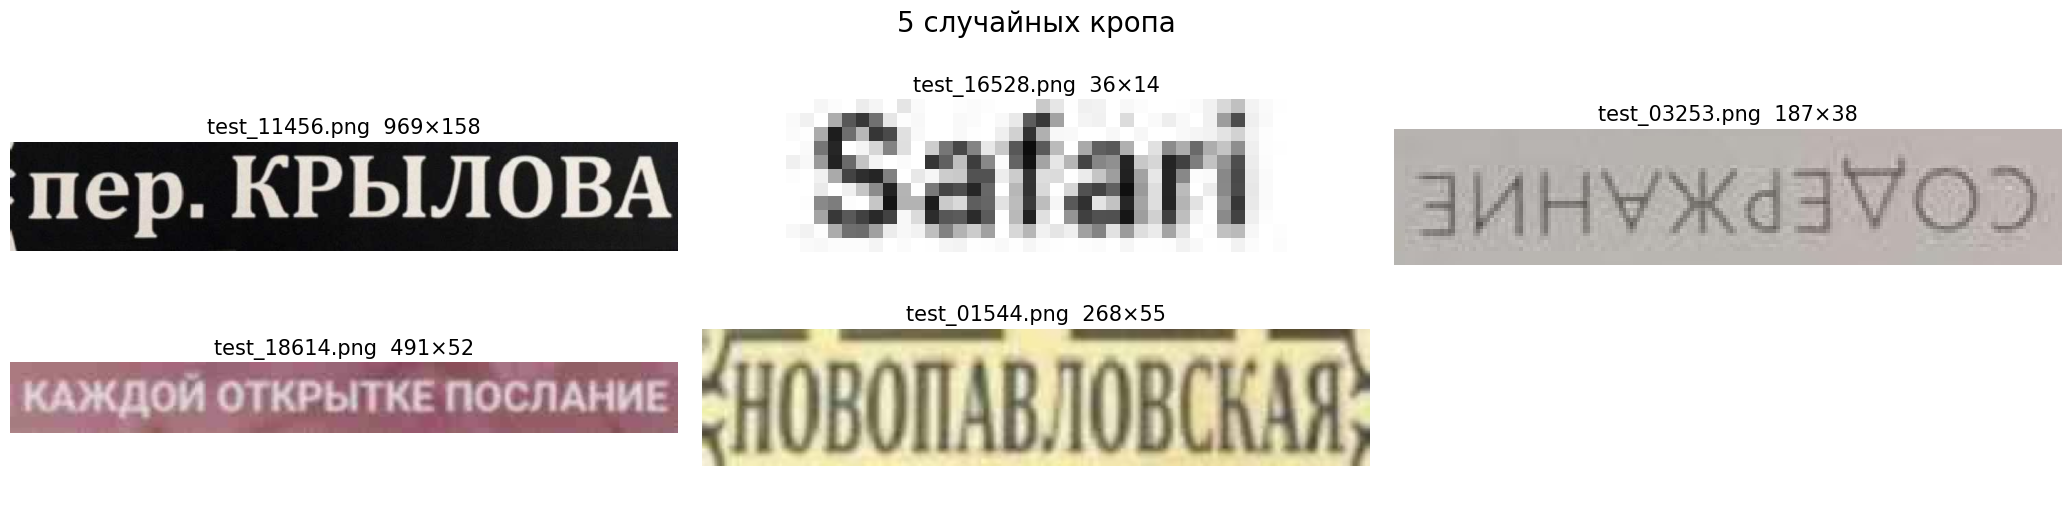

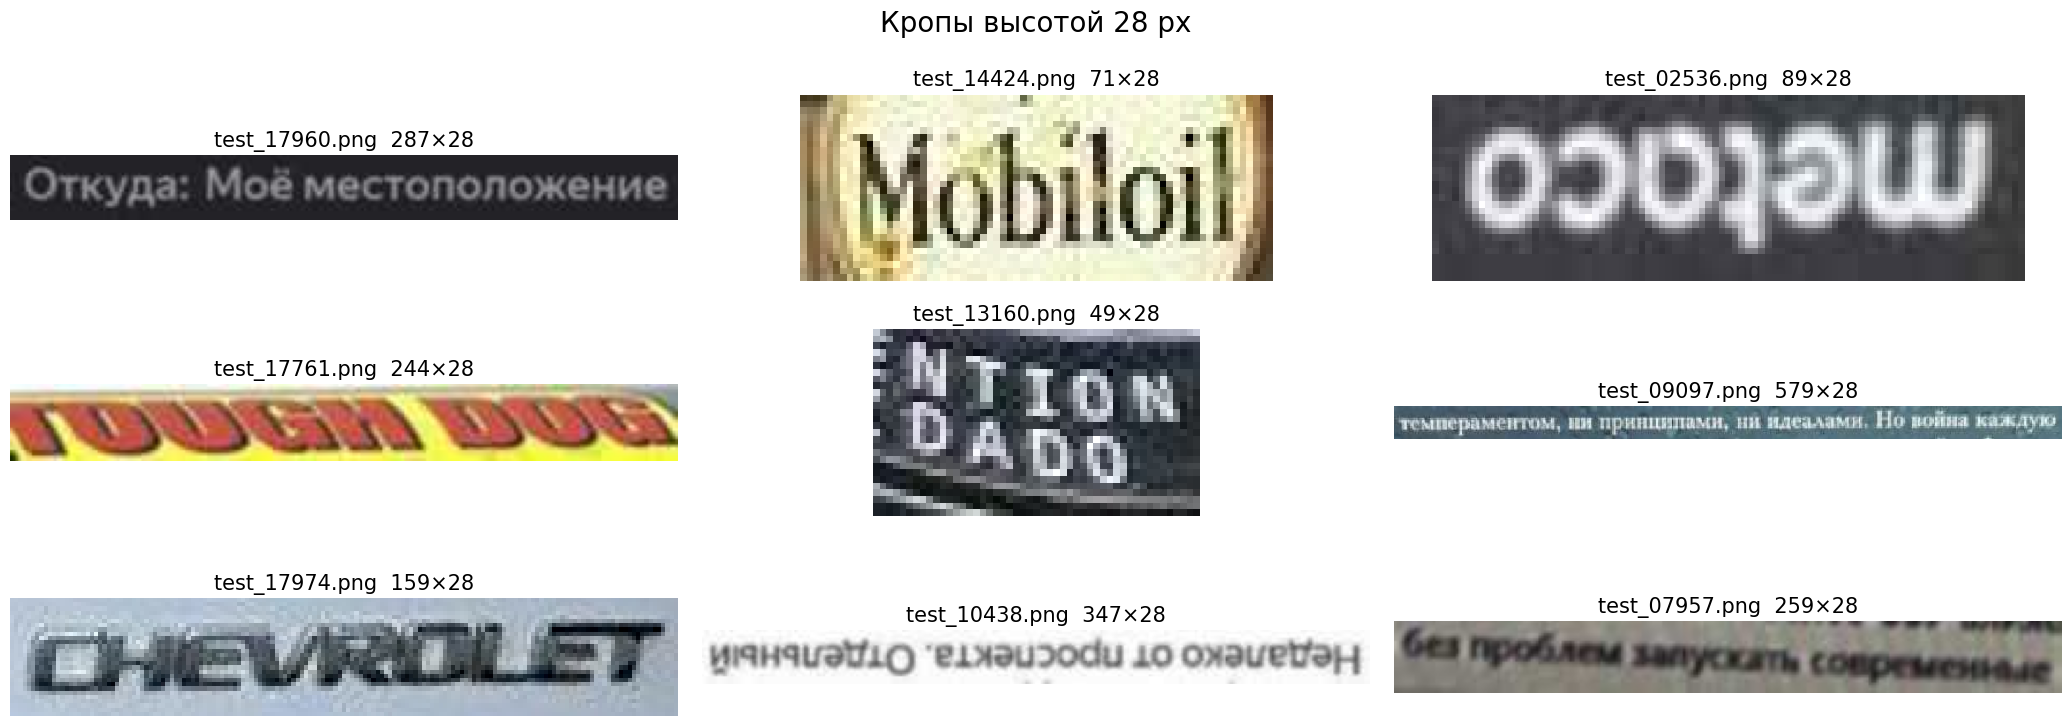

In [10]:
# 1. Какие высоты встречаются часто
print(df['h'].value_counts().head(15))

# 2. Доли по порогам
print(f"\nВысота < 16 px:                  {(df.h < 16).mean():.1%}")
print(f"Почти квадратные (aspect < 1.5): {(df.aspect < 1.5).mean():.1%}")
print(f"Вертикальные (h > w):            {(df.h > df.w).mean():.1%}")


show_grid(df.sample(5, random_state=1), n_cols=3, title='5 случайных кропа')

# 3. Кропы с самой частой высотой: одинаково ли они выглядят
top_h = df['h'].value_counts().index[0]
show_grid(df[df.h == top_h].sample(9, random_state=0), title=f'Кропы высотой {top_h} px')

## Бейзлайн: готовый классификатор ориентации строки

В качестве отправной точки используем готовую открытую модель **PP-LCNet_x1_0_textline_ori** из PaddleOCR (лицензия Apache-2.0). Модель обучена ровно на нашу задачу: определять, повёрнута текстовая строка на 0° или на 180°.

Веса загружаются один раз с Hugging Face (`PaddlePaddle/PP-LCNet_x1_0_textline_ori_safetensors`) и запускаются локально через `transformers` на PyTorch.

Задачи бейзлайна:
- получить первый корректный сабмит без обучения своей модели;
- зафиксировать точку отсчёта по качеству, размеру и скорости, с которой будем сравнивать собственное решение;
- проверить, как модель, обученная в основном на китайском и английском тексте, ведёт себя на кириллице.

In [11]:
!nvidia-smi
print("CUDA доступна:", torch.cuda.is_available())

Sun Sep 27 13:24:39 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [12]:
MODEL_ID = "PaddlePaddle/PP-LCNet_x1_0_textline_ori_safetensors"
device = "cuda" if torch.cuda.is_available() else "cpu"

# processor готовит картинку так, как модель видела при обучении
processor = AutoImageProcessor.from_pretrained(MODEL_ID)
# eval() переключает модель в режим предсказаний (отключает то, что нужно только при обучении)
model = AutoModelForImageClassification.from_pretrained(MODEL_ID).to(device).eval()

print("Устройство:", device)
print("Классы:", model.config.id2label)
print(f"Параметров: {sum(p.numel() for p in model.parameters()) / 1e6:.2f} млн")
print("\nПредобработка:\n", processor)

preprocessor_config.json:   0%|          | 0.00/783 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/652 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 6.76MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

Устройство: cuda
Классы: {0: '0_degree', 1: '180_degree'}
Параметров: 1.67 млн

Предобработка:
 PPLCNetImageProcessor {
  "channel_first": false,
  "crop_size": {
    "height": 224,
    "width": 224
  },
  "do_center_crop": false,
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.406,
    0.456,
    0.485
  ],
  "image_mode": "BGR",
  "image_processor_type": "PPLCNetImageProcessor",
  "image_std": [
    0.225,
    0.224,
    0.229
  ],
  "keep_keys": [
    "image",
    "shape",
    "polys",
    "ignore_tags"
  ],
  "model_input_names": [
    "pixel_values",
    "original_image_size"
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "resize_short": null,
  "size": {
    "height": 80,
    "width": 160
  },
  "size_divisor": 1
}



size: SizeDict(height=80, width=160, longest_edge=None, shortest_edge=None, max_height=None, max_width=None, min_pixels=None, max_pixels=None) | mean: (0.406, 0.456, 0.485) | std: (0.225, 0.224, 0.229)
Вход модели: (12, 3, 80, 160)


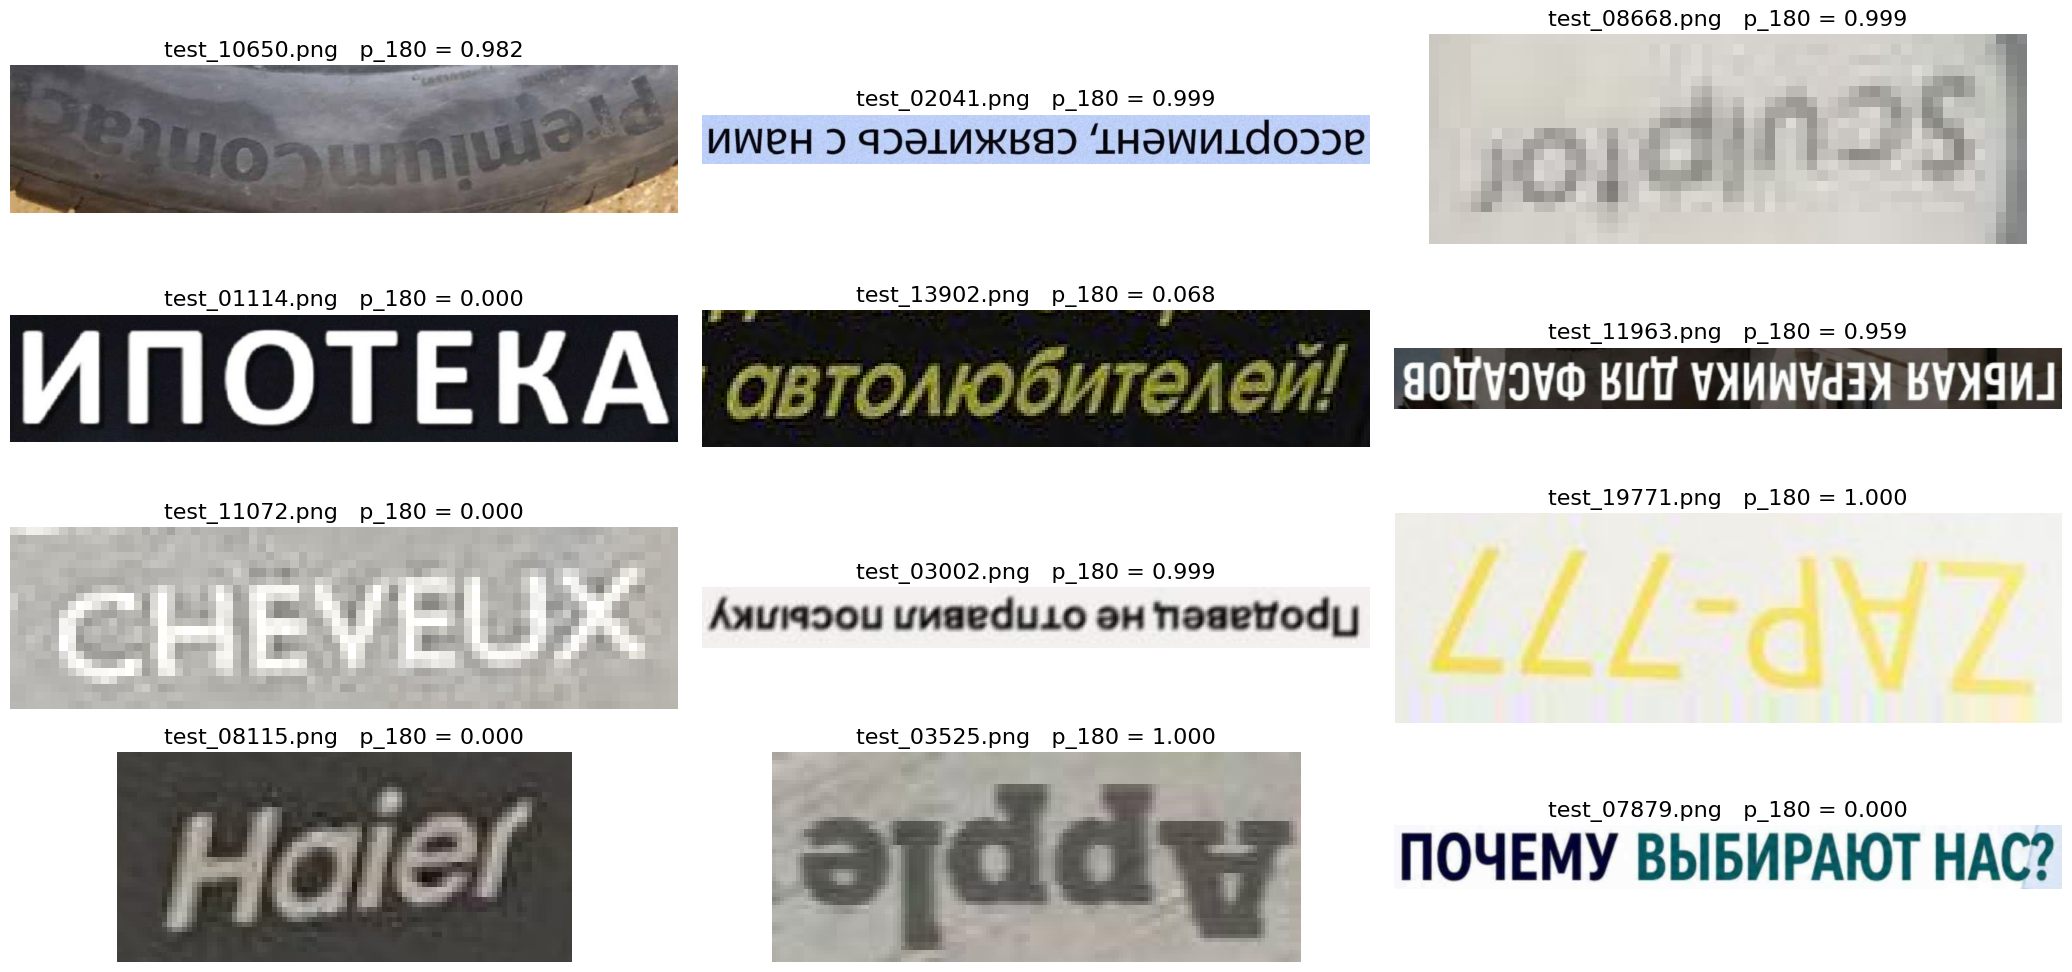

In [15]:
IDX_180 = next(int(k) for k, v in model.config.id2label.items() if '180' in v)

@torch.no_grad()
def predict_p180(imgs):
    inputs = processor(images=imgs, return_tensors='pt').to(device)
    out = model(**inputs)
    logits = out.logits if getattr(out, 'logits', None) is not None else out.last_hidden_state
    return logits.softmax(-1)[:, IDX_180].cpu().numpy()


sample = df.sample(12, random_state=SEED).copy()
imgs = [Image.open(p).convert('RGB') for p in sample.path]
sample['p_180'] = predict_p180(imgs)

print("size:", processor.size, "| mean:", processor.image_mean, "| std:", processor.image_std)
print("Вход модели:", tuple(processor(images=imgs, return_tensors='pt')['pixel_values'].shape))

fig, axes = plt.subplots(4, 3, figsize=(21, 10))
for ax, img, (_, r) in zip(axes.ravel(), imgs, sample.iterrows()):
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"{r.image_id}   p_180 = {r.p_180:.3f}", fontsize=16)
plt.tight_layout()
plt.show()

### Два прогона: исходный кроп и повёрнутый на 180° (TTA)

Модель выдаёт `p(x)` — вероятность того, что текст на кропе `x` перевёрнут. Если повернуть кроп на 180°, нормальный текст станет перевёрнутым и наоборот. Поэтому для идеальной модели выполняется равенство:

$$p(\text{rot}(x)) = 1 - p(x)$$

Реальная модель выполняет его не всегда, поэтому у нас есть две оценки одной и той же величины: прямая `p(x)` и `1 − p(rot(x))`, полученная через повёрнутую копию. В ответ идёт их среднее:

$$p_{180} = \frac{p(x) + 1 - p(\text{rot}(x))}{2}$$

test-time augmentation. Он даёт два эффекта:
- сглаживает случайные ошибки: если модель ошиблась только в одном из прогонов, итог уходит к середине, а не к уверенному неправильному ответу. Для Brier Score это важно: уверенная ошибка стоит почти 1, неуверенная — около 0.25;
- даёт 0.5 для симметричных кропов: надписи, которые при повороте выглядят так же, получают одинаковую оценку в обоих прогонах, и итог равен ровно 0.5.

Цена — вдвое больше

      image_id  p_orig  p_rot  1 - p_rot  p_180
test_10650.png   0.982  0.004      0.996  0.989
test_02041.png   0.999  0.000      1.000  1.000
test_08668.png   0.999  0.000      1.000  0.999
test_01114.png   0.000  0.125      0.875  0.437
test_13902.png   0.068  1.000      0.000  0.034
test_11963.png   0.959  0.000      1.000  0.979


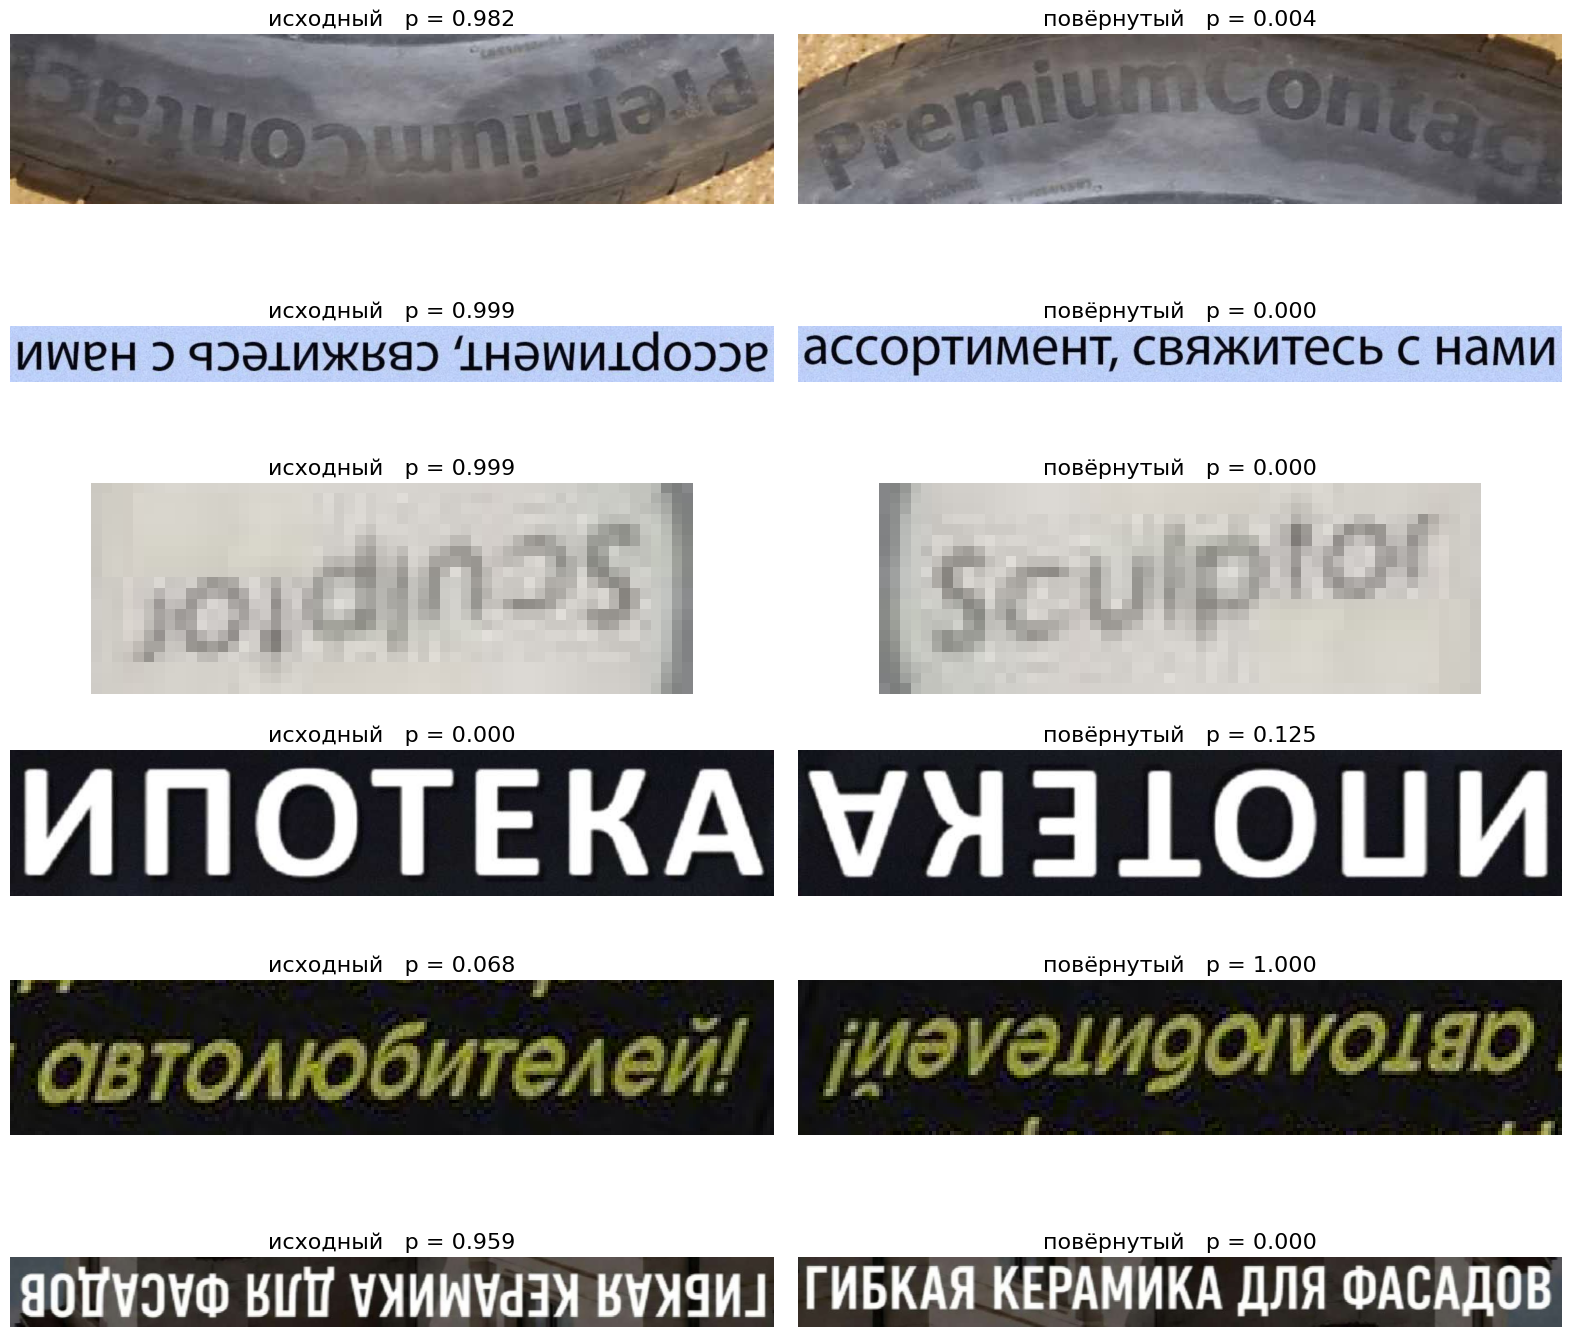

In [16]:
demo = df.sample(6, random_state=SEED).copy()
imgs = [Image.open(p).convert('RGB') for p in demo.path]
# transpose вместо rotate: поворот на 180° без интерполяции, пиксели не меняются
rot = [im.transpose(Image.Transpose.ROTATE_180) for im in imgs]

demo['p_orig'] = predict_p180(imgs)
demo['p_rot'] = predict_p180(rot)
demo['1 - p_rot'] = 1 - demo.p_rot
demo['p_180'] = (demo.p_orig + demo['1 - p_rot']) / 2

print(demo[['image_id', 'p_orig', 'p_rot', '1 - p_rot', 'p_180']].round(3).to_string(index=False))

fig, axes = plt.subplots(len(demo), 2, figsize=(16, 2.4 * len(demo)))
for row, img, r_img, (_, r) in zip(axes, imgs, rot, demo.iterrows()):
    row[0].imshow(img)
    row[0].set_title(f"исходный   p = {r.p_orig:.3f}", fontsize=16)
    row[1].imshow(r_img)
    row[1].set_title(f"повёрнутый   p = {r.p_rot:.3f}", fontsize=16)
    for ax in row:
        ax.axis('off')
plt.tight_layout()
plt.show()

In [17]:
OUT_DIR = ZIP_ON_DRIVE.parent / 'outputs'
OUT_DIR.mkdir(exist_ok=True)
BATCH = 256

def predict_dataset(paths, batch=BATCH):
    p_orig, p_rot = [], []
    for i in tqdm(range(0, len(paths), batch)):
        imgs = [Image.open(p).convert('RGB') for p in paths[i:i + batch]]
        rot = [im.transpose(Image.Transpose.ROTATE_180) for im in imgs]
        p_orig.append(predict_p180(imgs))
        p_rot.append(predict_p180(rot))
    return np.concatenate(p_orig), np.concatenate(p_rot)

t0 = time.time()
df['p_orig'], df['p_rot'] = predict_dataset(df.path.tolist())
elapsed = time.time() - t0
print(f"Время: {elapsed:.0f} с, {2 * len(df) / elapsed:.0f} картинок/с (оба прохода, включая чтение файлов)")

df['p_180'] = (df.p_orig + 1 - df.p_rot) / 2
df.to_csv(OUT_DIR / 'baseline_raw_preds.csv', index=False)

print(df[['p_orig', 'p_rot', 'p_180']].describe().round(3))
print(f"\nСредний p_180: {df.p_180.mean():.3f}")
print(f"Неуверенных (0.2 < p_180 < 0.8): {df.p_180.between(0.2, 0.8).mean():.1%}")
print(f"Прогоны противоречат друг другу: {((df.p_orig > 0.5) == (df.p_rot > 0.5)).mean():.1%}")

  0%|          | 0/79 [00:00<?, ?it/s]

Время: 83 с, 480 картинок/с (оба прохода, включая чтение файлов)
          p_orig      p_rot      p_180
count  20000.000  20000.000  20000.000
mean       0.575      0.558      0.509
std        0.446      0.449      0.385
min        0.000      0.000      0.000
25%        0.020      0.014      0.070
50%        0.834      0.780      0.500
75%        1.000      1.000      0.951
max        1.000      1.000      1.000

Средний p_180: 0.509
Неуверенных (0.2 < p_180 < 0.8): 34.5%
Прогоны противоречат друг другу: 30.2%


### Результаты бейзлайна на тесте (без меток)

**Скорость:** 476 картинок/с на T4 для двух прогонов, включая чтение файлов. Весь тест (20 000 кропов × 2 прогона) обрабатывается за 84 с.

| | `p_orig` | `p_rot` | `p_180` (TTA) |
|---|---|---|---|
| среднее | 0.575 | 0.558 | 0.509 |
| медиана | 0.834 | 0.780 | 0.500 |

**Наблюдения:**
- **30.2% противоречий между прогонами:** для почти трети кропов модель считает перевёрнутыми (или нормальными) одновременно и кроп, и его поворот на 180°. Для корректной модели эта доля должна быть близка к нулю, потому что из двух картинок перевёрнута ровно одна.
- **Смещение в сторону класса «180°»:** средние `p_orig` и `p_rot` оба больше 0.5, их сумма больше 1. Модель склонна отвечать «перевёрнут» независимо от содержимого.
- **Медиана `p_180` = 0.5:** противоречивые прогоны после усреднения дают значения около 0.5. TTA превращает уверенные ошибки в неуверенные ответы, это снижает штраф Brier, но 34.5% кропов остаются в зоне неуверенности (0.2–0.8).
- **Средний `p_180` = 0.509 не является надёжной оценкой доли перевёрнутых кропов:** треть значений принудительно близка к 0.5 и тянет среднее к середине.

**Вывод:** готовая модель на наших данных работает заметно хуже, чем на данных, на которых её обучали. Доля противоречий не требует меток, поэтому по ней можно искать причины прямо на тесте. Гипотезы для проверки:
1. сжатие длинных строк до фиксированного размера 80×160 без сохранения пропорций;
2. порядок цветовых каналов (RGB против BGR, на который указывают параметры нормализации);
3. мелкие кропы с сильным увеличением при ресайзе.

In [18]:
sub = df[['image_id', 'p_180']].sort_values('image_id').reset_index(drop=True)

assert list(sub.columns) == ['image_id', 'p_180']
assert len(sub) == 20000
assert sub.image_id.is_unique
assert set(sub.image_id) == {p.name for p in images}
assert sub.p_180.notna().all()
assert sub.p_180.between(0, 1).all()

sub.to_csv('submission.csv', index=False, float_format='%.6f')
sub.to_csv(OUT_DIR / 'sub_01_baseline_tta.csv', index=False, float_format='%.6f')
print(sub.head())

from google.colab import files
files.download('submission.csv')

         image_id     p_180
0  test_00000.png  0.434813
1  test_00001.png  0.973035
2  test_00002.png  0.999413
3  test_00003.png  0.152475
4  test_00004.png  0.994782


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
print("Не-картинки в архиве:")
for p in data_dir.rglob('*'):
    if p.is_file() and p.suffix.lower() not in {'.png', '.jpg', '.jpeg', '.webp'}:
        print("  ", p)

print("\nФайлы рядом с архивом на Drive:")
for p in ZIP_ON_DRIVE.parent.iterdir():
    print("  ", p.name)

for p in list(data_dir.rglob('sample_submission*.csv')) + list(ZIP_ON_DRIVE.parent.glob('sample_submission*.csv')):
    s = pd.read_csv(p)
    print(f"\n{p}\nстрок: {len(s)}, колонки: {list(s.columns)}")
    print(s.head())

Не-картинки в архиве:
   /content/test_data/sample_submission.csv

Файлы рядом с архивом на Drive:
   test.zip
   outputs
   rustitw_test_real.zip

/content/test_data/sample_submission.csv
строк: 20000, колонки: ['image_id', 'p_180']
     image_id  p_180
0  test_00000    0.5
1  test_00001    0.5
2  test_00002    0.5
3  test_00003    0.5
4  test_00004    0.5


In [20]:
sample_sub = pd.read_csv(data_dir / 'sample_submission.csv')

preds = df.assign(image_id=df.image_id.str.rsplit('.', n=1).str[0])[['image_id', 'p_180']]
sub = sample_sub[['image_id']].merge(preds, on='image_id', how='left')

assert list(sub.columns) == ['image_id', 'p_180']
assert len(sub) == len(sample_sub)
assert sub.image_id.tolist() == sample_sub.image_id.tolist()
assert sub.p_180.notna().all(), "Для части image_id нет предсказаний"
assert sub.p_180.between(0, 1).all()

sub.to_csv('submission.csv', index=False, float_format='%.6f')
sub.to_csv(OUT_DIR / 'sub_01_baseline_tta.csv', index=False, float_format='%.6f')
print(sub.head())

files.download('submission.csv')

     image_id     p_180
0  test_00000  0.434813
1  test_00001  0.973035
2  test_00002  0.999413
3  test_00003  0.152475
4  test_00004  0.994782


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
!head -3 submission.csv

image_id,p_180
test_00000,0.434813
test_00001,0.973035


### Сабмит 1: бейзлайн + TTA

**Результат на платформе:** 1 − Brier = **0.9223** (Brier = 0.0777). Ориентир снизу: константа 0.5 даёт 0.75.

Файл: `outputs/sub_01_baseline_tta.csv`. Формат `image_id` берётся из `sample_submission.csv` (имена без расширения).

**Разбор ошибки:** противоречивые кропы (30.2% теста) после TTA получают `p_180 ≈ 0.5`, и каждый из них стоит около 0.25. Их вклад в Brier ≈ 0.302 × 0.25 ≈ 0.075, то есть почти весь итоговый Brier (0.078). Там, где два прогона согласны, модель практически не ошибается.

**Следующий шаг:** снизить долю противоречий.

In [22]:
df['contradiction'] = (df.p_orig > 0.5) == (df.p_rot > 0.5)
df['disagreement'] = (df.p_orig - (1 - df.p_rot)).abs()

def by_group(col, bins):
    g = df.groupby(pd.cut(df[col], bins), observed=True)
    return pd.DataFrame({
        'доля кропов': g.size() / len(df),
        'противоречий': g.contradiction.mean(),
        'несогласованность': g.disagreement.mean(),
    }).round(3)

print("По отношению ширины к высоте:")
print(by_group('aspect', [0, 2, 3, 5, 8, 12, np.inf]))
print("\nПо высоте кропа, px:")
print(by_group('h', [0, 16, 24, 32, 48, 96, np.inf]))

По отношению ширины к высоте:
             доля кропов  противоречий  несогласованность
aspect                                                   
(0.0, 2.0]         0.023         0.520              0.501
(2.0, 3.0]         0.133         0.458              0.452
(3.0, 5.0]         0.362         0.334              0.337
(5.0, 8.0]         0.262         0.214              0.227
(8.0, 12.0]        0.132         0.180              0.199
(12.0, inf]        0.089         0.321              0.320

По высоте кропа, px:
              доля кропов  противоречий  несогласованность
h                                                         
(0.0, 16.0]         0.067         0.239              0.259
(16.0, 24.0]        0.126         0.344              0.349
(24.0, 32.0]        0.165         0.333              0.342
(32.0, 48.0]        0.208         0.395              0.393
(48.0, 96.0]        0.246         0.355              0.350
(96.0, inf]         0.188         0.094              0.117


## Валидационные данные: RusTitW (test)

Размеченной обучающей выборки в задаче нет, поэтому валидацию собираем сами из внешних данных. Метки для задачи ориентации не требуют разметки: берём кропы с нормально расположенным текстом и половину из них поворачиваем на 180°. Повёрнутые получают метку 1, остальные — 0.

**Источник:** RusTitW — Russian Language Text Dataset for Visual Text in-the-Wild Recognition (Markov et al., 2023, [arXiv:2303.16531](https://arxiv.org/abs/2303.16531)). Используется копия на Kaggle (`hardtype/rustitw-russian-language-visual-text-recognition`), лицензия Apache 2.0. Архив подготовлен вручную через веб-интерфейс Kaggle и загружен на Google Drive, внешние API в коде не используются.

**Почему этот датасет:** это открытый набор реальных фотографий с кириллическим текстом. Как и в нашем тесте, там в основном русские надписи, есть английские и цифры, текст на вывесках, упаковках и объявлениях.

**Что берём:** часть `test/real` — 3 795 фотографий с ручной разметкой рамок текста. Часть `train/real` оставляем для возможного дообучения. Это разные фотографии, поэтому утечки между обучением и валидацией нет.

**Отличия от теста и как их учитываем:**
- рамки размечены по абзацам, а тестовые кропы в основном однострочные → оставляем только однострочные рамки;
- рамки нестрогие, с запасом фона → фильтруем по отношению ширины к высоте в диапазоне теста;
- надписи крупнее, чем в тесте → уменьшаем кропы до распределения высот тестовых кропов.

**Проверка соответствия тесту:** прогоняем на валидации бейзлайн и сравниваем с известными значениями на тесте (1 − Brier = 0.922, 30% противоречий между прогонами). Близкие значения означают, что валидация отражает трудность теста.

In [24]:
import json

RUSTITW_ZIP = Path('/content/drive/MyDrive/test data avito/rustitw_test_real.zip')
RUSTITW_DIR = Path('/content/rustitw_test')

with zipfile.ZipFile(RUSTITW_ZIP) as z:
    z.extractall(RUSTITW_DIR)

info = pd.read_csv(RUSTITW_DIR / 'real' / 'info.csv')
images_dir = RUSTITW_DIR / 'real' / 'images'

print("Колонки:", info.columns.tolist(), "| строк:", len(info))
print("Картинок в папке:", len(list(images_dir.iterdir())))

row = info.iloc[2]
print("\nФайл:", row.image_name, row.width, "x", row.height)
print(json.dumps(json.loads(row.box_and_label), ensure_ascii=False, indent=1)[:1500])
print("\ntext:", repr(row.text))

Колонки: ['image_name', 'box_and_label', 'width', 'height', 'aspect_ratio', 'text', 'image_path'] | строк: 3795
Картинок в папке: 3795

Файл: 00012.jpg 736 x 736
[
 [
  {
   "left": 0.009510869565217392,
   "top": 0.19429347826086957,
   "width": 0.4293478260869565,
   "height": 0.3383152173913044,
   "label": "Мангальные \\/n блюда \\/n шашлык \\/n баранина говядина \\/n курица сёмга \\/n домашняя свинина",
   "shape": "rectangle"
  },
  {
   "left": 0.014945652173913044,
   "top": 0.5475543478260869,
   "width": 0.4470108695652174,
   "height": 0.29891304347826086,
   "label": "печень \\/n домашняя в сетке \\/n цыплёнок \\/n табака",
   "shape": "rectangle"
  },
  {
   "left": 0.4592391304347826,
   "top": 0.19021739130434784,
   "width": 0.26086956521739135,
   "height": 0.25407608695652173,
   "label": "хачапури \\/n под \\/n заказ",
   "shape": "rectangle"
  },
  {
   "left": 0.7296195652173914,
   "top": 0.19701086956521738,
   "width": 0.21875,
   "height": 0.2459239130434783,
 

In [27]:
LINE_SEP = '\\/n'

rows = []
for r in info.itertuples():
    for group in json.loads(r.box_and_label):
        for b in group:
            rows.append({
                'image_name': r.image_name,
                'shape': b.get('shape'),
                'label': b.get('label', ''),
                'x': b['left'] * r.width,
                'y': b['top'] * r.height,
                'w': b['width'] * r.width,
                'h': b['height'] * r.height,
            })

boxes = pd.DataFrame(rows)
boxes['n_lines'] = boxes.label.str.count(re.escape(LINE_SEP)) + 1
boxes['aspect'] = boxes.w / boxes.h

single = boxes[(boxes.n_lines == 1) & (boxes.shape_ == 'rectangle')] if 'shape_' in boxes else \
         boxes[(boxes.n_lines == 1) & (boxes['shape'] == 'rectangle')]

print("Всего рамок:", len(boxes))
print("Формы:", boxes['shape'].value_counts().to_dict())
print(f"Однострочных прямоугольных: {len(single)} ({len(single) / len(boxes):.0%})")

q = [.01, .05, .25, .5, .75, .95, .99]
print("\nОтношение ширины к высоте:")
print(pd.DataFrame({'валидация (однострочные)': single.aspect.quantile(q),
                    'тест': df.aspect.quantile(q)}).round(2))
print("\nВысота рамки, px:")
print(single.h.quantile(q).round(0))

Всего рамок: 10739
Формы: {'rectangle': 10739}
Однострочных прямоугольных: 10611 (99%)

Отношение ширины к высоте:
      валидация (однострочные)   тест
0.01                      0.33   1.76
0.05                      0.70   2.32
0.25                      1.37   3.50
0.50                      2.15   4.89
0.75                      3.31   7.52
0.95                      6.56  14.45
0.99                     10.86  22.61

Высота рамки, px:
0.01     13.0
0.05     19.0
0.25     35.0
0.50     59.0
0.75    102.0
0.95    256.0
0.99    572.0
Name: h, dtype: float64


In [28]:
ex = boxes.label.iloc[:3].tolist()
for s in ex:
    print(repr(s))

print("\nСколько меток содержат:")
for name, pat in [('\\/n (обратная косая + /n)', '\\/n'),
                  ('/n', '/n'),
                  ('перенос строки \\n', '\n')]:
    print(f"  {name:28s} {boxes.label.str.contains(pat, regex=False).mean():.0%}")

'ALL you NEED\nis 20 SECONDS\nof Insane'
'COURAGE\nAND I PROMISE YOU\nsomething GREAT'
'will come of it\nBenjmin Mee'

Сколько меток содержат:
  \/n (обратная косая + /n)    1%
  /n                           1%
  перенос строки \n            40%


In [29]:
LINE_SEP_RE = r'\n|\\/n'

boxes['n_lines'] = boxes.label.str.count(LINE_SEP_RE) + 1
single = boxes[(boxes.n_lines == 1) & (boxes['shape'] == 'rectangle')]

print(f"Однострочных: {len(single)} ({len(single) / len(boxes):.0%})")

q = [.01, .05, .25, .5, .75, .95, .99]
print("\nОтношение ширины к высоте:")
print(pd.DataFrame({'валидация (однострочные)': single.aspect.quantile(q),
                    'тест': df.aspect.quantile(q)}).round(2))
print("\nВысота рамки, px:")
print(single.h.quantile(q).round(0))

Однострочных: 6286 (59%)

Отношение ширины к высоте:
      валидация (однострочные)   тест
0.01                      0.26   1.76
0.05                      0.65   2.32
0.25                      1.33   3.50
0.50                      2.23   4.89
0.75                      3.52   7.52
0.95                      7.26  14.45
0.99                     12.45  22.61

Высота рамки, px:
0.01     11.0
0.05     16.0
0.25     28.0
0.50     45.0
0.75     76.0
0.95    204.0
0.99    499.0
Name: h, dtype: float64


In [30]:
ASPECT_BINS = [1.5, 2, 3, 5, 8, 12, np.inf]

cand = single[single.aspect >= 1.5].copy()
cand['bin'] = pd.cut(cand.aspect, ASPECT_BINS)
test_bin = pd.cut(df.aspect.clip(lower=1.5), ASPECT_BINS)

stat = pd.DataFrame({
    'доля в тесте': test_bin.value_counts(normalize=True).sort_index(),
    'рамок в валидации': cand.bin.value_counts().sort_index(),
})
# Размер выборки ограничен самым «дефицитным» интервалом
stat['макс. размер выборки'] = (stat['рамок в валидации'] / stat['доля в тесте']).astype(int)

print(f"Рамок с отношением ≥ 1.5: {len(cand)}")
print(stat.round(3))
print("\nМаксимальный размер валидации с долями как в тесте:", stat['макс. размер выборки'].min())

Рамок с отношением ≥ 1.5: 4426
             доля в тесте  рамок в валидации  макс. размер выборки
(1.5, 2.0]          0.020                875                 44380
(2.0, 3.0]          0.133               1490                 11194
(3.0, 5.0]          0.363               1268                  3493
(5.0, 8.0]          0.263                552                  2100
(8.0, 12.0]         0.132                163                  1231
(12.0, inf]         0.089                 72                   808

Максимальный размер валидации с долями как в тесте: 808


### Отбор рамок и взвешивание валидации

**Фильтрация.** Из 10 739 рамок RusTitW оставляем:
- однострочные (в тексте метки нет переноса строки `\n` или `\/n`) — 6 286 рамок, потому что тестовые кропы почти всегда однострочные;
- с отношением ширины к высоте не меньше 1.5 — 4 426 рамок. Более узкие рамки — это вертикальный текст (разметчики RusTitW выделяли каждый столбец отдельно) и почти квадратные рамки с большим запасом фона. В тесте таких кропов практически нет (1-й перцентиль отношения сторон — 1.76).

Высоты рамок близки к тестовым (медиана 45 px против 42 px), поэтому размер кропов не меняем.

**Проблема: доли кропов разной формы в валидации и в тесте отличаются.**

| Отношение ширины к высоте | Доля в тесте | Доля в валидации |
|---|---|---|
| 1.5–2 | 2% | 20% |
| 2–3 | 13% | 34% |
| 3–5 | 36% | 29% |
| 5–8 | 26% | 12% |
| 8–12 | 13% | 4% |
| > 12 | 9% | 2% |

Диагностика на тесте показала, что качество модели сильно зависит от формы кропа: на коротких кропах прогоны противоречат друг другу примерно в половине случаев, на средних — примерно в 20%. Если считать метрику без поправки, валидация будет в основном отражать качество на коротких кропах, хотя в тесте их всего 2%. Вариант модели, который улучшает короткие кропы и ухудшает длинные, на такой валидации выглядел бы лучше, а на тесте оказался бы хуже.

Строгая выборка с долями как в тесте дала бы всего 808 кропов (ограничивают длинные строки: в валидации их 72) — слишком мало для сравнения вариантов.

**Решение: importance weighting.** Используем все 4 426 кропов, но при подсчёте метрики даём каждому кропу вес

$$w = \frac{\text{доля его интервала в тесте}}{\text{доля его интервала в валидации}}$$

Тогда взвешенный Brier Score равен тому, что получилось бы на выборке с распределением форм как в тесте. Например, длинные строки получают вес около 5.5, короткие — около 0.1.

Недостаток: кропы с большим весом увеличивают разброс оценки. Поэтому дополнительно показываем метрику по каждому интервалу отдельно и невзвешенную. Решения принимаем по взвешенной.

In [32]:
VAL_CROPS = Path('/content/val_crops')
VAL_CROPS.mkdir(exist_ok=True)
MIN_SIDE = 8

img_size = info.set_index('image_name')[['width', 'height']]
records, n_exif, n_skipped = [], 0, 0

for img_name, group in tqdm(cand.groupby('image_name')):
    im = Image.open(images_dir / img_name)
    expected = tuple(img_size.loc[img_name])
    if im.size != expected:
        # Разметку делали по фото с учётом EXIF-поворота, а PIL сам его не применяет
        im = ImageOps.exif_transpose(im)
        n_exif += 1
        if im.size != expected:
            n_skipped += 1
            continue
    im = im.convert('RGB')
    W, H = im.size

    for b in group.itertuples():
        x0, y0 = max(0, round(b.x)), max(0, round(b.y))
        x1, y1 = min(W, round(b.x + b.w)), min(H, round(b.y + b.h))
        if x1 - x0 < MIN_SIDE or y1 - y0 < MIN_SIDE:
            continue
        crop_id = f"val_{len(records):05d}.png"
        im.crop((x0, y0, x1, y1)).save(VAL_CROPS / crop_id)
        records.append({'crop_id': crop_id, 'image_name': img_name, 'text': b.label,
                        'w': x1 - x0, 'h': y1 - y0, 'bin': b.bin})

val = pd.DataFrame(records)
val['aspect'] = val.w / val.h
val.to_csv(OUT_DIR / 'val_rustitw_crops.csv', index=False)

print(f"Кропов: {len(val)} | фото с EXIF-поворотом: {n_exif} | пропущено фото: {n_skipped}")
print(val[['w', 'h', 'aspect']].describe().round(1))

  0%|          | 0/2187 [00:00<?, ?it/s]

Кропов: 4407 | фото с EXIF-поворотом: 0 | пропущено фото: 0
            w       h  aspect
count  4407.0  4407.0  4407.0
mean    198.4    60.6     3.6
std     212.9    66.3     2.7
min      14.0     8.0     0.7
25%      79.0    27.0     2.1
50%     134.0    42.0     2.9
75%     227.0    69.0     4.2
max    2651.0   967.0    59.7


Доля перевёрнутых: 0.500
             кропов   вес
bin                      
(1.5, 2.0]      874  0.10
(2.0, 3.0]     1485  0.39
(3.0, 5.0]     1267  1.26
(5.0, 8.0]      547  2.11
(8.0, 12.0]     156  3.74
(12.0, inf]      72  5.45


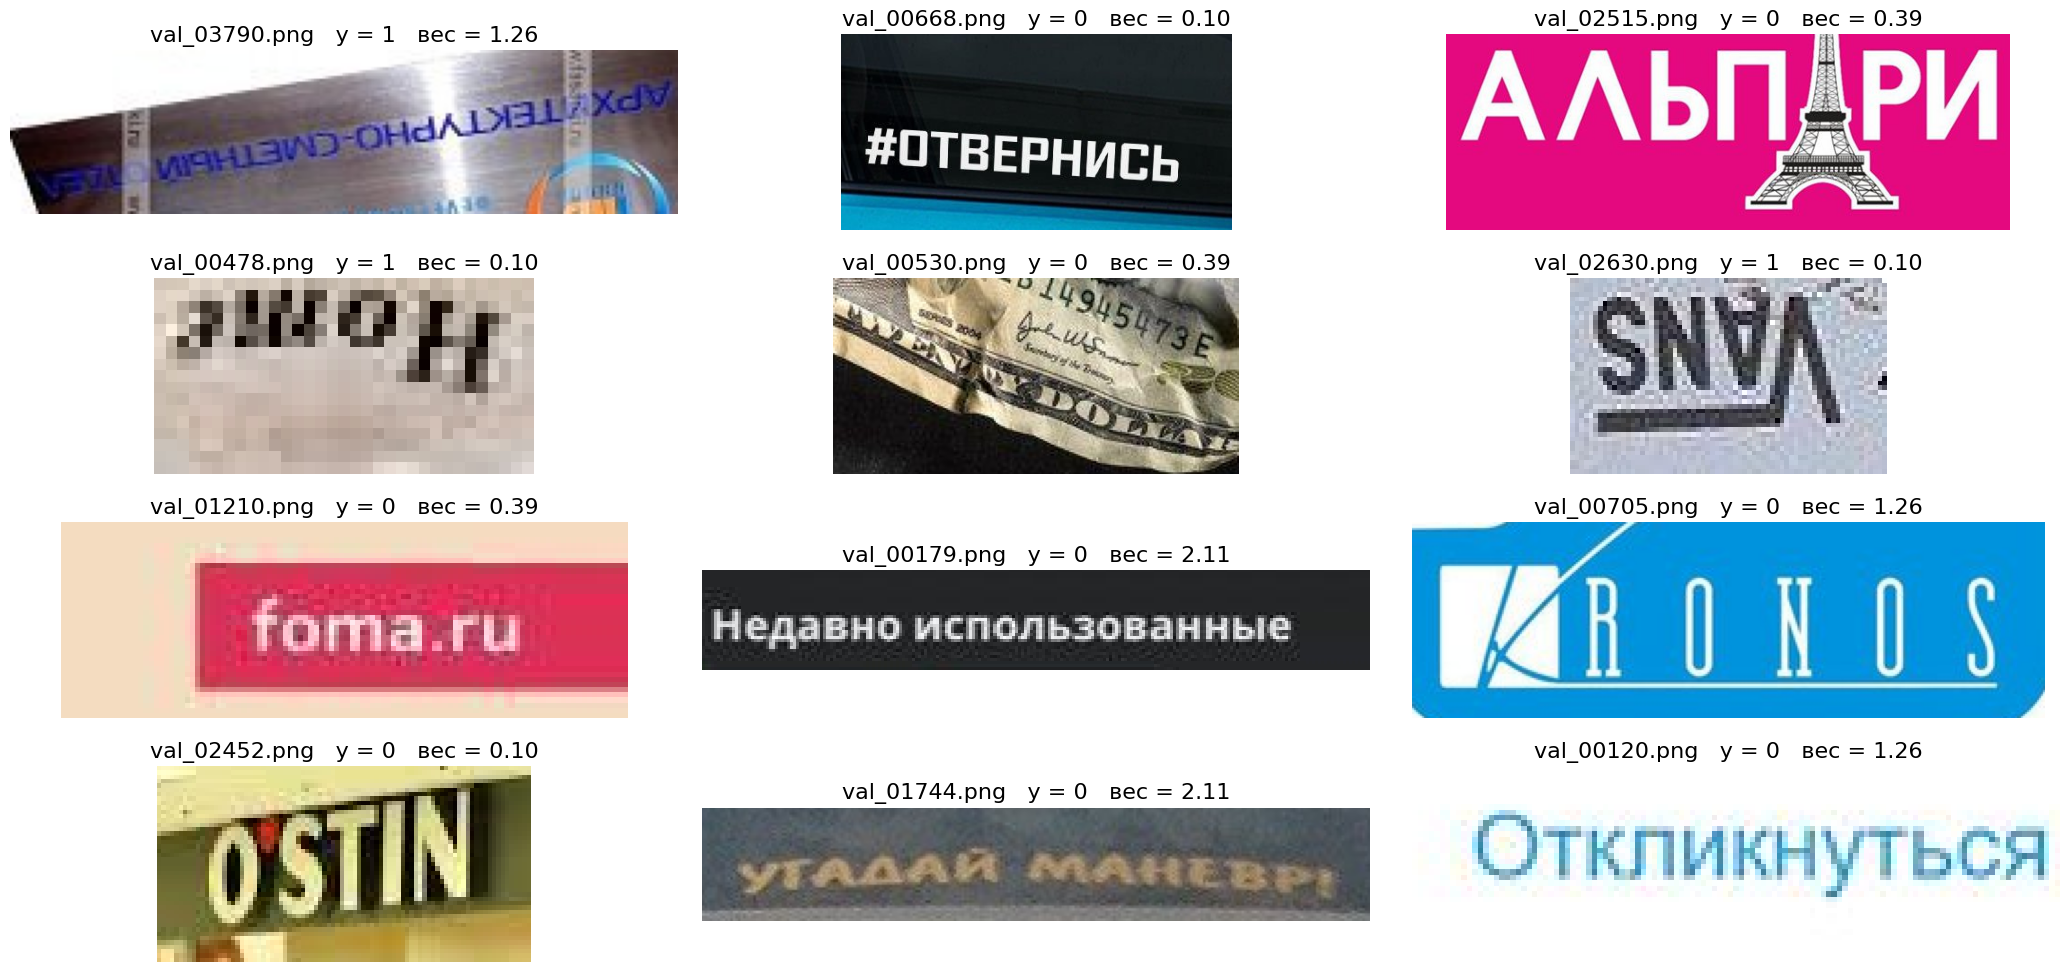

In [33]:
rng = np.random.default_rng(SEED)
# Ровно половина единиц, перемешанных случайно
val['y'] = rng.permutation(np.arange(len(val)) % 2)

test_share = test_bin.value_counts(normalize=True)
val_share = val.bin.value_counts(normalize=True)
val['weight'] = val.bin.map(test_share / val_share).astype(float)
val['weight'] /= val.weight.mean()

val.to_csv(OUT_DIR / 'val_rustitw_crops.csv', index=False)


def load_val_image(row):
    im = Image.open(VAL_CROPS / row.crop_id).convert('RGB')
    return im.transpose(Image.Transpose.ROTATE_180) if row.y == 1 else im


print(f"Доля перевёрнутых: {val.y.mean():.3f}")
print(val.groupby('bin', observed=True).agg(кропов=('y', 'size'), вес=('weight', 'first')).round(2))

sample = val.sample(12, random_state=SEED)
fig, axes = plt.subplots(4, 3, figsize=(21, 10))
for ax, (_, r) in zip(axes.ravel(), sample.iterrows()):
    ax.imshow(load_val_image(r))
    ax.axis('off')
    ax.set_title(f"{r.crop_id}   y = {r.y}   вес = {r.weight:.2f}", fontsize=16)
plt.tight_layout()
plt.show()

In [34]:
print("Кропов без интервала:", val.bin.isna().sum())
val = val[val.bin.notna()].reset_index(drop=True)

val_share = val.bin.value_counts(normalize=True)
val['weight'] = val.bin.map(test_share / val_share).astype(float)
val['weight'] /= val.weight.mean()
val.to_csv(OUT_DIR / 'val_rustitw_crops.csv', index=False)

print(f"Кропов: {len(val)} | доля перевёрнутых: {val.y.mean():.3f} | пустых весов: {val.weight.isna().sum()}")

Кропов без интервала: 6
Кропов: 4401 | доля перевёрнутых: 0.500 | пустых весов: 0


In [35]:
def brier_score(y, p, w=None):
    return np.average((p - y) ** 2, weights=w)


def predict_val(frame, batch=BATCH):
    p_orig, p_rot = [], []
    for i in tqdm(range(0, len(frame), batch)):
        imgs = [load_val_image(r) for r in frame.iloc[i:i + batch].itertuples()]
        rot = [im.transpose(Image.Transpose.ROTATE_180) for im in imgs]
        p_orig.append(predict_p180(imgs))
        p_rot.append(predict_p180(rot))
    return np.concatenate(p_orig), np.concatenate(p_rot)


val['p_orig'], val['p_rot'] = predict_val(val)
val['p_180'] = (val.p_orig + 1 - val.p_rot) / 2
val['contradiction'] = (val.p_orig > 0.5) == (val.p_rot > 0.5)

y, w = val.y, val.weight
print(f"{'':22s}{'без весов':>12s}{'с весами':>12s}")
print(f"{'1 − Brier, один прогон':22s}{1 - brier_score(y, val.p_orig):12.4f}{1 - brier_score(y, val.p_orig, w):12.4f}")
print(f"{'1 − Brier, TTA':22s}{1 - brier_score(y, val.p_180):12.4f}{1 - brier_score(y, val.p_180, w):12.4f}")
print(f"{'противоречий':22s}{val.contradiction.mean():12.1%}{np.average(val.contradiction, weights=w):12.1%}")

by_bin = val.groupby('bin', observed=True).apply(lambda g: pd.Series({
    'кропов': len(g),
    '1 − Brier (TTA)': 1 - brier_score(g.y, g.p_180),
    'противоречий': g.contradiction.mean(),
}), include_groups=False)
print("\nПо интервалам пропорций:")
print(by_bin.round(3))

  0%|          | 0/18 [00:00<?, ?it/s]

                         без весов    с весами
1 − Brier, один прогон      0.8515      0.8740
1 − Brier, TTA              0.9019      0.9090
противоречий                 30.7%       24.2%

По интервалам пропорций:
             кропов  1 − Brier (TTA)  противоречий
bin                                               
(1.5, 2.0]    874.0            0.871         0.445
(2.0, 3.0]   1485.0            0.894         0.324
(3.0, 5.0]   1267.0            0.924         0.257
(5.0, 8.0]    547.0            0.933         0.212
(8.0, 12.0]   156.0            0.885         0.154
(12.0, inf]    72.0            0.843         0.236


In [36]:
def to_bgr(im):
    return Image.merge('RGB', im.split()[::-1])


def evaluate(name, frame, transform=lambda im: im, batch=BATCH):
    p_orig, p_rot = [], []
    for i in tqdm(range(0, len(frame), batch), desc=name):
        imgs = [transform(load_val_image(r)) for r in frame.iloc[i:i + batch].itertuples()]
        rot = [im.transpose(Image.Transpose.ROTATE_180) for im in imgs]
        p_orig.append(predict_p180(imgs))
        p_rot.append(predict_p180(rot))
    p_orig, p_rot = np.concatenate(p_orig), np.concatenate(p_rot)
    p_tta = (p_orig + 1 - p_rot) / 2
    y, w = frame.y, frame.weight
    return {
        'вариант': name,
        '1−Brier, один прогон': 1 - brier_score(y, p_orig, w),
        '1−Brier, TTA': 1 - brier_score(y, p_tta, w),
        'противоречий': np.average((p_orig > 0.5) == (p_rot > 0.5), weights=w),
    }


experiments = [evaluate('RGB (бейзлайн)', val), evaluate('BGR', val, to_bgr)]
print(pd.DataFrame(experiments).set_index('вариант').round(4))

RGB (бейзлайн):   0%|          | 0/18 [00:00<?, ?it/s]

BGR:   0%|          | 0/18 [00:00<?, ?it/s]

                1−Brier, один прогон  1−Brier, TTA  противоречий
вариант                                                         
RGB (бейзлайн)                0.8740        0.9090        0.2424
BGR                           0.8751        0.9096        0.2391


**Предположение.** Если подавать кроп высотой 80 px, а ширину считать по его пропорциям, буквы сохранят свою форму, и модель будет ошибаться реже, особенно на коротких и длинных кропах.

**Почему это возможно.** PP-LCNet — свёрточная сеть, которая в конце усредняет признаки по всей площади картинки. Поэтому она может принимать вход произвольной ширины, а не только 80×160.

**Проверка.**
1. Пишем свою предобработку (ресайз, перевод в 0–1, нормализация) и убеждаемся, что при размере 80×160 она совпадает с `processor`. Так любое последующее изменение метрики будет вызвано только сохранением пропорций.
2. Подаём кропы с сохранёнными пропорциями и сравниваем взвешенную метрику на валидации с бейзлайном, в целом и по интервалам пропорций.

In [37]:
H_IN = processor.size['height']
W_REF = processor.size['width']
MEAN = torch.tensor(processor.image_mean).view(3, 1, 1)
STD = torch.tensor(processor.image_std).view(3, 1, 1)


def to_tensor(im, w, h=H_IN):
    im = im.resize((w, h), Image.BILINEAR)
    x = torch.from_numpy(np.asarray(im, dtype=np.float32) / 255).permute(2, 0, 1)
    return (x - MEAN) / STD


imgs = [load_val_image(r) for r in val.head(8).itertuples()]
ours = torch.stack([to_tensor(im, W_REF) for im in imgs])
ref = processor(images=imgs, return_tensors='pt')['pixel_values']

print("resample у processor:", getattr(processor, 'resample', None))
print("Форма: наша", tuple(ours.shape), "| processor", tuple(ref.shape))
print("Макс. разница:", (ours - ref).abs().max().item())

resample у processor: 2
Форма: наша (8, 3, 80, 160) | processor (8, 3, 80, 160)
Макс. разница: 0.641949474811554


In [38]:
import torch.nn.functional as F

def torch_resize(im, w, h=H_IN, antialias=True, bgr=False):
    x = torch.from_numpy(np.asarray(im, dtype=np.float32) / 255).permute(2, 0, 1)
    if bgr:
        x = x[[2, 1, 0]]
    x = F.interpolate(x[None], size=(h, w), mode='bilinear', align_corners=False, antialias=antialias)[0]
    return (x - MEAN) / STD

candidates = {
    'PIL, RGB':                 lambda im: to_tensor(im, W_REF),
    'PIL, BGR':                 lambda im: to_tensor(to_bgr(im), W_REF),
    'torch, antialias, RGB':    lambda im: torch_resize(im, W_REF),
    'torch, antialias, BGR':    lambda im: torch_resize(im, W_REF, bgr=True),
    'torch, без antialias, RGB': lambda im: torch_resize(im, W_REF, antialias=False),
    'torch, без antialias, BGR': lambda im: torch_resize(im, W_REF, antialias=False, bgr=True),
}

print("Класс processor:", type(processor).__name__, "\n")
for name, fn in candidates.items():
    d = (torch.stack([fn(im) for im in imgs]) - ref).abs()
    print(f"{name:28s} макс. {d.max().item():.4f}   средняя {d.mean().item():.4f}")

Класс processor: PPLCNetImageProcessor 

PIL, RGB                     макс. 0.6419   средняя 0.2564
PIL, BGR                     макс. 0.4012   средняя 0.2222
torch, antialias, RGB        макс. 0.6457   средняя 0.2579
torch, antialias, BGR        макс. 0.4049   средняя 0.2237
torch, без antialias, RGB    макс. 2.2094   средняя 0.2754
torch, без antialias, BGR    макс. 2.1845   средняя 0.2413


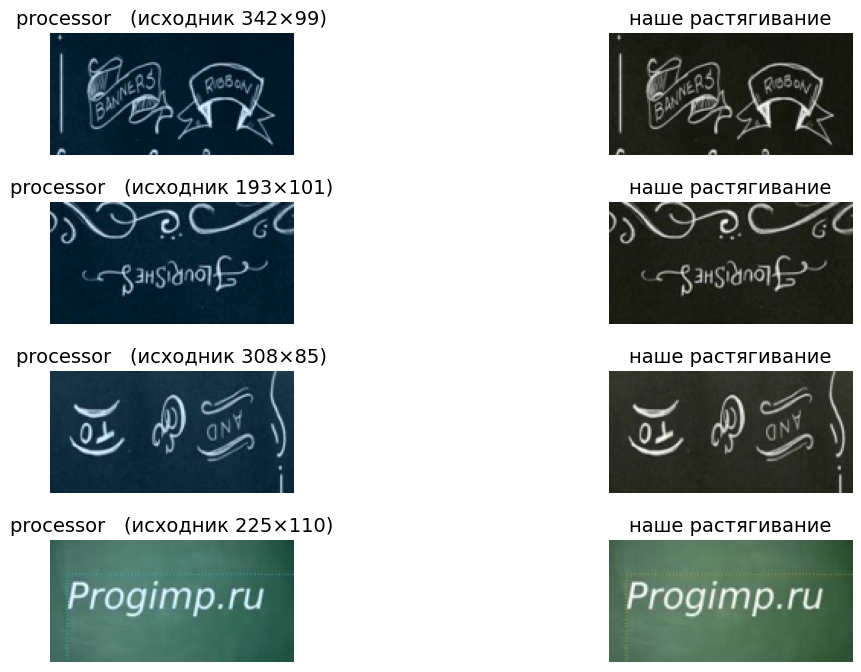

@auto_docstring
@requires(backends=("torch",))
class PPLCNetImageProcessor(TorchvisionBackend):
    resample = 2
    image_mean = [0.406, 0.456, 0.485]
    image_std = [0.225, 0.224, 0.229]
    size = {"height": 256, "width": 256}
    do_resize = True
    do_rescale = True
    do_normalize = True
    do_center_crop = True
    crop_size = 224
    resize_short = 256
    size_divisor = 1
    valid_kwargs = PPLCNetImageProcessorKwargs

    def _preprocess(
        self,
        images: list["torch.Tensor"],
        do_resize: bool,
        size: SizeDict,
        resample: "PILImageResampling | tvF.InterpolationMode | int | None",
        resize_short: int,
        size_divisor: int,
        do_center_crop: bool,
        crop_size: SizeDict,
        do_rescale: bool,
        rescale_factor: float,
        do_normalize: bool,
        image_mean: float | list[float] | None,
        image_std: float | list[float] | None,
        return_tensors: str | TensorType | None,
        disable_groupin

In [39]:
import inspect

def show_tensor(x):
    return (x * STD + MEAN).clamp(0, 1).permute(1, 2, 0).numpy()

fig, axes = plt.subplots(4, 2, figsize=(14, 7))
for i, (ax_ref, ax_our) in enumerate(axes):
    ax_ref.imshow(show_tensor(ref[i]))
    ax_ref.set_title(f"processor   (исходник {imgs[i].width}×{imgs[i].height})", fontsize=14)
    ax_our.imshow(show_tensor(ours[i]))
    ax_our.set_title("наше растягивание", fontsize=14)
    for ax in (ax_ref, ax_our):
        ax.axis('off')
plt.tight_layout()
plt.show()

src = inspect.getsource(type(processor))
print(src[:4000])

In [40]:
def to_tensor(im, w, h=H_IN):
    x = torch.from_numpy(np.asarray(im, dtype=np.float32) / 255).permute(2, 0, 1)
    x = F.interpolate(x[None], size=(h, w), mode='bilinear', align_corners=False, antialias=True)[0]
    x = (x - MEAN) / STD
    # Как в processor: нормализация в порядке RGB, затем разворот каналов в BGR
    return x[[2, 1, 0]]


ours = torch.stack([to_tensor(im, W_REF) for im in imgs])
d = (ours - ref).abs()
print(f"Макс. разница: {d.max().item():.4f}   средняя: {d.mean().item():.4f}")

Макс. разница: 0.0173   средняя: 0.0044


In [42]:
MAX_ASPECT = 25
BATCH_KA = 64

@torch.no_grad()
def predict_p180_tensors(x):
    out = model(pixel_values=x.to(device))
    logits = out.logits if getattr(out, 'logits', None) is not None else out.last_hidden_state
    return logits.softmax(-1)[:, IDX_180].cpu().numpy()


def keep_aspect_batch(imgs, min_w=0):
    widths = [int(np.clip(round(H_IN * im.width / im.height), 8, H_IN * MAX_ASPECT)) for im in imgs]
    target = max(max(widths), min_w)
    batch = []
    for im, w in zip(imgs, widths):
        pad = target - w
        # Поля поровну с двух сторон, чтобы поворот на 180° не менял положение текста в кадре
        batch.append(F.pad(to_tensor(im, w), (pad // 2, pad - pad // 2)))
    return torch.stack(batch)


def evaluate(name, frame, predict_fn, batch=BATCH_KA):
    # Сортируем по пропорциям, чтобы в батче были кропы похожей ширины и меньше полей
    order = np.argsort(frame.aspect.values)
    p_orig, p_rot = np.empty(len(frame)), np.empty(len(frame))
    for i in tqdm(range(0, len(frame), batch), desc=name):
        idx = order[i:i + batch]
        imgs = [load_val_image(r) for r in frame.iloc[idx].itertuples()]
        rot = [im.transpose(Image.Transpose.ROTATE_180) for im in imgs]
        p_orig[idx], p_rot[idx] = predict_fn(imgs), predict_fn(rot)
    p_tta = (p_orig + 1 - p_rot) / 2
    y, w = frame.y.values, frame.weight.values
    row = {
        'вариант': name,
        '1−Brier, один прогон': 1 - brier_score(y, p_orig, w),
        '1−Brier, TTA': 1 - brier_score(y, p_tta, w),
        'противоречий': np.average((p_orig > 0.5) == (p_rot > 0.5), weights=w),
    }
    return row, p_tta


variants = {
    'растягивание 80×160': predict_p180,
    'пропорции': lambda imgs: predict_p180_tensors(keep_aspect_batch(imgs)),
    'пропорции + добивка до 160': lambda imgs: predict_p180_tensors(keep_aspect_batch(imgs, W_REF)),
}

rows, preds = [], {}
for name, fn in variants.items():
    row, preds[name] = evaluate(name, val, fn)
    rows.append(row)

print(pd.DataFrame(rows).set_index('вариант').round(4))

print("\n1 − Brier (TTA) по интервалам пропорций:")
print(pd.DataFrame({
    name: val.assign(p=p).groupby('bin', observed=True)
             .apply(lambda g: 1 - brier_score(g.y, g.p), include_groups=False)
    for name, p in preds.items()
}).round(3))

растягивание 80×160:   0%|          | 0/69 [00:00<?, ?it/s]

пропорции:   0%|          | 0/69 [00:00<?, ?it/s]

пропорции + добивка до 160:   0%|          | 0/69 [00:00<?, ?it/s]

                            1−Brier, один прогон  1−Brier, TTA  противоречий
вариант                                                                     
растягивание 80×160                       0.8740        0.9090        0.2424
пропорции                                 0.8890        0.9316        0.2545
пропорции + добивка до 160                0.8892        0.9317        0.2547

1 − Brier (TTA) по интервалам пропорций:
             растягивание 80×160  пропорции  пропорции + добивка до 160
bin                                                                    
(1.5, 2.0]                 0.871      0.869                       0.873
(2.0, 3.0]                 0.894      0.895                       0.895
(3.0, 5.0]                 0.924      0.925                       0.925
(5.0, 8.0]                 0.933      0.942                       0.942
(8.0, 12.0]                0.885      0.947                       0.947
(12.0, inf]                0.843      0.970                       0.9

## Сабмит 2

In [43]:
def predict_test(frame, predict_fn, batch=BATCH_KA):
    order = np.argsort(frame.aspect.values)
    p_orig, p_rot = np.empty(len(frame)), np.empty(len(frame))
    for i in tqdm(range(0, len(frame), batch)):
        idx = order[i:i + batch]
        imgs = [Image.open(p).convert('RGB') for p in frame.path.values[idx]]
        rot = [im.transpose(Image.Transpose.ROTATE_180) for im in imgs]
        p_orig[idx], p_rot[idx] = predict_fn(imgs), predict_fn(rot)
    return p_orig, p_rot


best_fn = variants['пропорции + добивка до 160']
df['p_orig_ka'], df['p_rot_ka'] = predict_test(df, best_fn)
df['p_180_ka'] = (df.p_orig_ka + 1 - df.p_rot_ka) / 2

preds = df.assign(image_id=df.image_id.str.rsplit('.', n=1).str[0])[['image_id', 'p_180_ka']]
sub = sample_sub[['image_id']].merge(preds.rename(columns={'p_180_ka': 'p_180'}), on='image_id', how='left')

assert sub.image_id.tolist() == sample_sub.image_id.tolist()
assert sub.p_180.notna().all() and sub.p_180.between(0, 1).all()

backup = OUT_DIR / 'sub_02_keep_aspect_tta.csv'
assert not backup.exists(), f"{backup.name} уже есть"
sub.to_csv('submission.csv', index=False, float_format='%.6f')
sub.to_csv(backup, index=False, float_format='%.6f')

print(sub.head())
print(f"Средний p_180: {sub.p_180.mean():.3f}")
files.download('submission.csv')

  0%|          | 0/313 [00:00<?, ?it/s]

     image_id     p_180
0  test_00000  0.200029
1  test_00001  0.990845
2  test_00002  0.999132
3  test_00003  0.106260
4  test_00004  0.951163
Средний p_180: 0.507


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [45]:
files.download('submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [46]:
df['bin'] = pd.cut(df.aspect.clip(lower=1.5), ASPECT_BINS)
df['contr_ka'] = (df.p_orig_ka > 0.5) == (df.p_rot_ka > 0.5)

cmp = df.groupby('bin', observed=True).apply(lambda g: pd.Series({
    'доля теста': len(g) / len(df),
    'средн. |Δp|': (g.p_180_ka - g.p_180).abs().mean(),
    'смена решения': ((g.p_180_ka > 0.5) != (g.p_180 > 0.5)).mean(),
    'противоречий: растяг.': g.contradiction.mean(),
    'противоречий: пропорции': g.contr_ka.mean(),
    'неуверенных: растяг.': g.p_180.between(0.2, 0.8).mean(),
    'неуверенных: пропорции': g.p_180_ka.between(0.2, 0.8).mean(),
}), include_groups=False)
print(cmp.round(3))

             доля теста  средн. |Δp|  смена решения  противоречий: растяг.  противоречий: пропорции  \
bin                                                                                                   
(1.5, 2.0]        0.020        0.102          0.059                  0.496                    0.445   
(2.0, 3.0]        0.133        0.084          0.033                  0.458                    0.482   
(3.0, 5.0]        0.362        0.109          0.033                  0.334                    0.451   
(5.0, 8.0]        0.262        0.145          0.026                  0.214                    0.460   
(8.0, 12.0]       0.132        0.187          0.046                  0.180                    0.480   
(12.0, inf]       0.089        0.245          0.229                  0.321                    0.499   

             неуверенных: растяг.  неуверенных: пропорции  
bin                                                        
(1.5, 2.0]                  0.567                   0.5

  0%|          | 0/69 [00:00<?, ?it/s]

  0%|          | 0/69 [00:00<?, ?it/s]

                        средн. p_orig  средн. p_rot  оба > 0.5  оба < 0.5
валидация растягивание          0.565         0.568      0.219      0.088
          пропорции             0.623         0.628      0.291      0.038
тест      растягивание          0.575         0.558      0.218      0.083
          пропорции             0.674         0.660      0.406      0.060


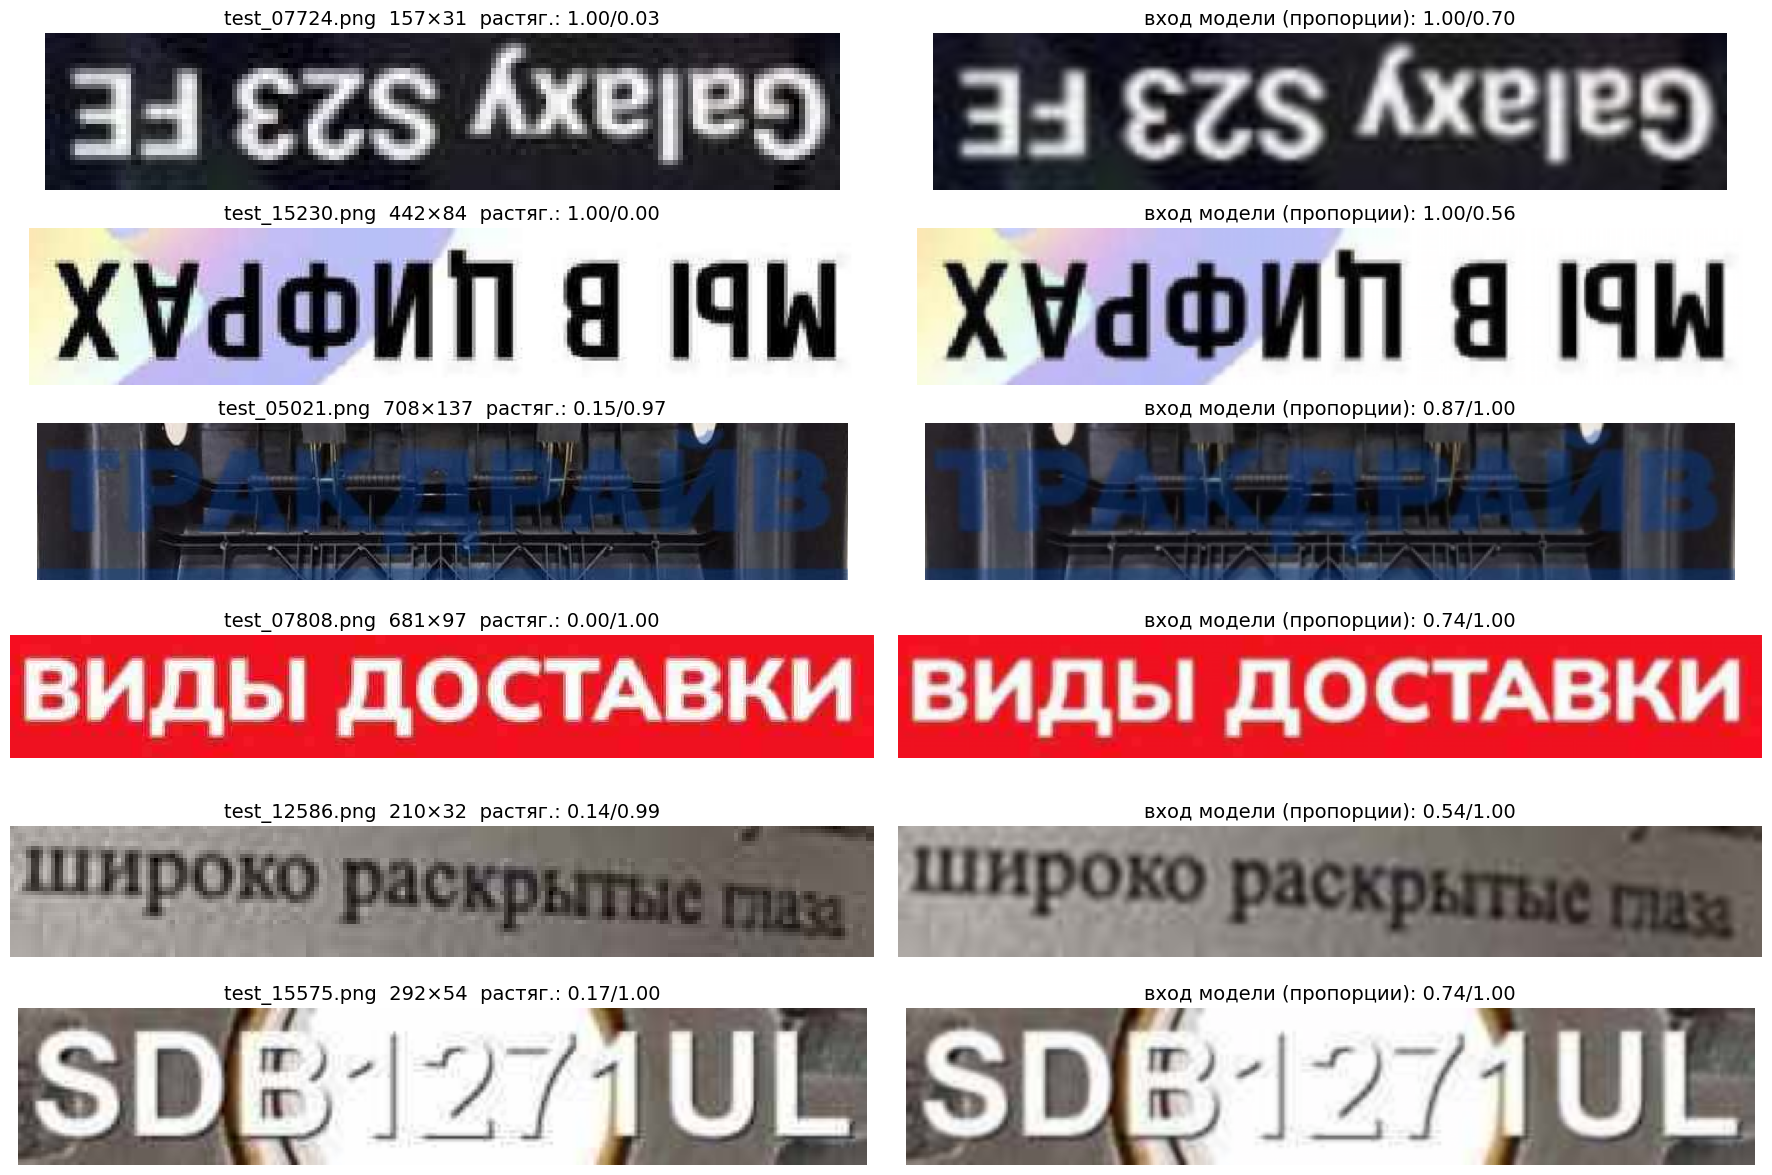

In [47]:
def two_passes(frame, load_fn, predict_fn, batch=BATCH_KA):
    order = np.argsort(frame.aspect.values)
    p_o, p_r = np.empty(len(frame)), np.empty(len(frame))
    for i in tqdm(range(0, len(frame), batch)):
        idx = order[i:i + batch]
        imgs = [load_fn(r) for r in frame.iloc[idx].itertuples()]
        rot = [im.transpose(Image.Transpose.ROTATE_180) for im in imgs]
        p_o[idx], p_r[idx] = predict_fn(imgs), predict_fn(rot)
    return p_o, p_r


load_test = lambda r: Image.open(r.path).convert('RGB')
stretch, keep = variants['растягивание 80×160'], variants['пропорции + добивка до 160']

runs = {
    ('валидация', 'растягивание'): two_passes(val, load_val_image, stretch),
    ('валидация', 'пропорции'):    two_passes(val, load_val_image, keep),
    ('тест', 'растягивание'):      (df.p_orig.values, df.p_rot.values),
    ('тест', 'пропорции'):         (df.p_orig_ka.values, df.p_rot_ka.values),
}

print(pd.DataFrame({k: {
    'средн. p_orig': p_o.mean(),
    'средн. p_rot': p_r.mean(),
    'оба > 0.5': ((p_o > .5) & (p_r > .5)).mean(),
    'оба < 0.5': ((p_o < .5) & (p_r < .5)).mean(),
} for k, (p_o, p_r) in runs.items()}).T.round(3))

bad = df[(df.aspect.between(5, 8)) & (~df.contradiction) & (df.contr_ka)].sample(6, random_state=SEED)
fig, axes = plt.subplots(6, 2, figsize=(18, 12))
for (ax_img, ax_in), (_, r) in zip(axes, bad.iterrows()):
    im = Image.open(r.path).convert('RGB')
    x = keep_aspect_batch([im], W_REF)[0][[2, 1, 0]]
    ax_img.imshow(im)
    ax_img.set_title(f"{r.image_id}  {r.w}×{r.h}  растяг.: {r.p_orig:.2f}/{r.p_rot:.2f}", fontsize=14)
    ax_in.imshow(show_tensor(x))
    ax_in.set_title(f"вход модели (пропорции): {r.p_orig_ka:.2f}/{r.p_rot_ka:.2f}", fontsize=14)
    for ax in (ax_img, ax_in):
        ax.axis('off')
plt.tight_layout()
plt.show()

### Сабмит 2 и разбор расхождения валидации с тестом

| Сабмит | Вариант | Валидация (с весами) | Тест |
|---|---|---|---|
| 1 | растягивание 80×160 + TTA | 0.9090 | **0.9223** |
| 2 | сохранение пропорций + добивка до 160 + TTA | 0.9317 | 0.9054 |

На валидации сохранение пропорций дало +0.023, а на тесте −0.017.

**Что показала диагностика на тесте (без меток).** С сохранением пропорций доля противоречий между двумя прогонами выросла до 45–50% во всех интервалах пропорций, включая средние кропы, где при растягивании было 21–33%. Противоречия направлены в одну сторону: модель чаще отвечает «перевёрнут» и для кропа, и для его поворота. Просмотр входных тензоров показал, что ошибки в коде нет: модель получает корректные картинки.

**Причина.** Тестовые кропы вырезаны детектором плотно: текст занимает почти всю высоту кропа. Широкий вход с плотно обрезанным текстом непривычен для модели: при обучении в PaddleOCR длинные строки тоже сжимались до ширины 160. Рамки RusTitW размечены с запасом фона, поэтому на валидации этот эффект не проявился.

**Выводы.**
1. Возвращаемся к растягиванию 80×160.
2. Валидация на RusTitW не отражает важное свойство теста — плотность кропов. Одной её недостаточно.
3. Доля противоречий на тесте предупредила об ухудшении (рост с ~30% до ~48%). Правило для следующих сабмитов: отправляем вариант, только если метрика на валидации выросла **и** доля противоречий на тесте не выросла.

### Следующий шаг: синтетические кропы и дообучение

Модель плохо знает наш тип данных: плотные кропы, кириллица, много отрисованного текста с рекламных баннеров («ВИДЫ ДОСТАВКИ», «МЫ В ЦИФРАХ»). Такие кропы хорошо воспроизводятся генератором: текст с кириллицей, разными шрифтами и фонами, плотная обрезка, как у детектора, деградации до размеров и качества тестовых кропов.

План:
1. Генератор синтетических кропов: шрифты с кириллицей, словарь частых русских и английских слов, рендер с плотной обрезкой, деградации.
2. Вторая часть валидации из синтетики — чтобы валидация видела плотные кропы.
3. Дообучение модели на реальных кропах RusTitW (`train/real`) и синтетике с метками, полученными поворотом на 180°.

In [53]:
REQUIRED_CHARS = 'АБВЖЯабвжяёЁ' + 'ABCGQabgqy' + '0123456789'

def font_supports(path, chars=REQUIRED_CHARS):
    try:
        cmap = TTFont(path, fontNumber=0, lazy=True).getBestCmap()
        return all(ord(c) in cmap for c in chars)
    except Exception:
        return False

all_fonts = sorted({p for ext in ('*.ttf', '*.otf') for p in Path('/usr/share/fonts').rglob(ext)})
FONTS = [str(p) for p in all_fonts if font_supports(p)]
families = sorted({Path(f).stem.split('-')[0] for f in FONTS})

RU_WORDS = [w for w in top_n_list('ru', 30000) if w.isalpha() and len(w) > 1]
EN_WORDS = [w for w in top_n_list('en', 10000) if w.isalpha() and len(w) > 1]

print(f"Шрифтов: {len(FONTS)}, семейств: {len(families)}")
print(f"Русских слов: {len(RU_WORDS)}, английских: {len(EN_WORDS)}")

Шрифтов: 135, семейств: 53
Русских слов: 29881, английских: 9816


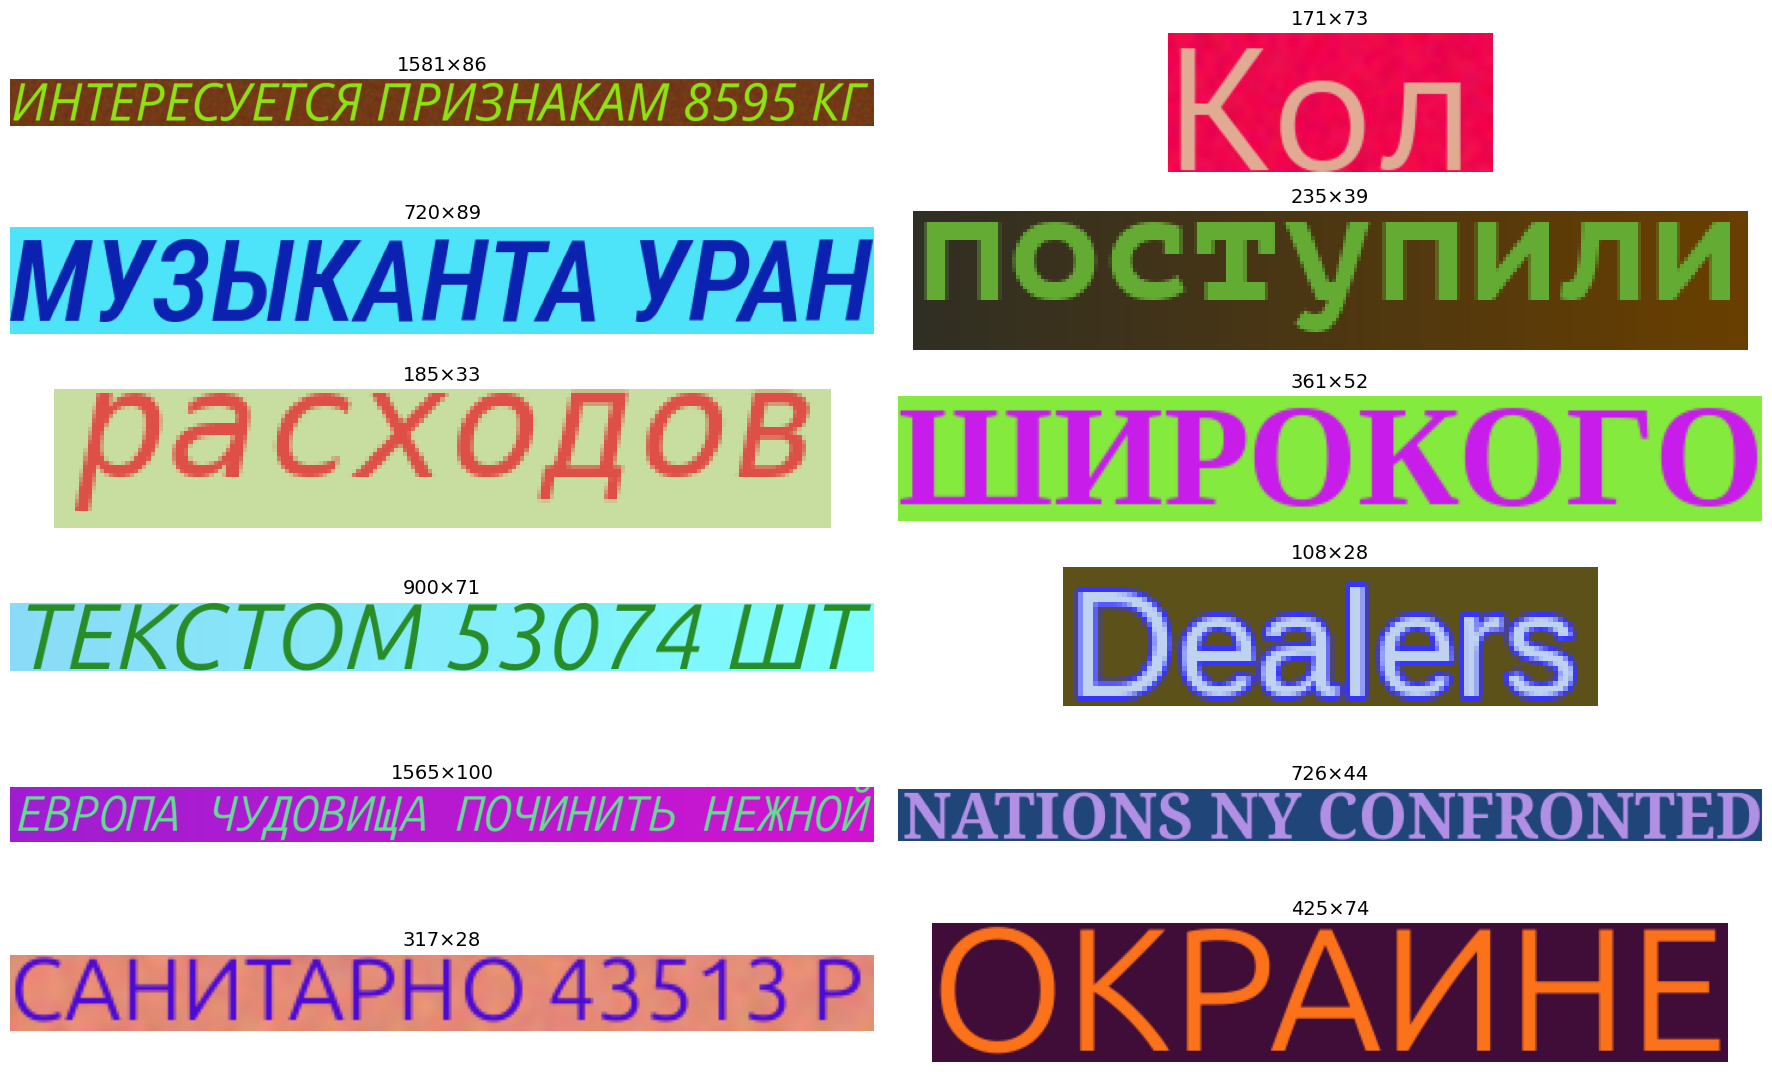

In [54]:
UNITS = ['р', 'руб', 'шт', '%', 'кг', 'м²']

def random_color(rng):
    return tuple(int(c) for c in rng.integers(0, 256, 3))

def luminance(c):
    return 0.299 * c[0] + 0.587 * c[1] + 0.114 * c[2]

def contrasting_colors(rng, min_diff=80):
    while True:
        bg, fg = random_color(rng), random_color(rng)
        if abs(luminance(bg) - luminance(fg)) >= min_diff:
            return bg, fg

def make_text(rng):
    kind = rng.random()
    if kind < 0.60:
        words = list(rng.choice(RU_WORDS, rng.integers(1, 5)))
    elif kind < 0.75:
        words = list(rng.choice(EN_WORDS, rng.integers(1, 4)))
    else:
        words = list(rng.choice(RU_WORDS, rng.integers(1, 3)))
        words.insert(int(rng.integers(0, len(words) + 1)), f"{rng.integers(1, 100000)} {rng.choice(UNITS)}")
    text = ' '.join(words)
    case = rng.random()
    return text.upper() if case < 0.4 else text.title() if case < 0.7 else text

def make_background(rng, w, h, bg):
    mode = rng.random()
    base = np.array(bg, dtype=np.float32)
    if mode < 0.5:
        arr = np.broadcast_to(base, (h, w, 3))
    elif mode < 0.8:
        # Сдвиг второго цвета ограничен, чтобы градиент не съел контраст с текстом
        end = np.clip(base + rng.uniform(-60, 60, 3), 0, 255)
        t = np.linspace(0, 1, w, dtype=np.float32)[None, :, None]
        arr = np.broadcast_to(base * (1 - t) + end * t, (h, w, 3))
    else:
        noise = rng.normal(0, 25, (h, w, 3)).astype(np.float32)
        arr = base + np.asarray(Image.fromarray(np.clip(noise + 128, 0, 255).astype(np.uint8))
                                .filter(ImageFilter.GaussianBlur(2)), dtype=np.float32) - 128
    return Image.fromarray(np.clip(arr, 0, 255).astype(np.uint8))

def render_crop(rng):
    text = make_text(rng)
    font = ImageFont.truetype(str(rng.choice(FONTS)), int(rng.integers(28, 97)))
    bg, fg = contrasting_colors(rng)
    stroke = int(rng.integers(1, 4)) if rng.random() < 0.15 else 0

    x0, y0, x1, y1 = font.getbbox(text, stroke_width=stroke)
    tw, th = x1 - x0, y1 - y0
    mt, mb = (rng.uniform(-0.05, 0.20, 2) * th).astype(int)
    ml, mr = (rng.uniform(-0.03, 0.15, 2) * th).astype(int)
    W, H = max(tw + ml + mr, 8), max(th + mt + mb, 8)

    img = make_background(rng, W, H, bg)
    ImageDraw.Draw(img).text((ml - x0, mt - y0), text, font=font, fill=fg,
                             stroke_width=stroke, stroke_fill=random_color(rng))
    return img, text


rng = np.random.default_rng(SEED)
fig, axes = plt.subplots(6, 2, figsize=(18, 11))
for ax in axes.ravel():
    img, text = render_crop(rng)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"{img.width}×{img.height}", fontsize=14)
plt.tight_layout()
plt.show()

### Генератор синтетических кропов

Синтетика нужна, чтобы закрыть то, чего нет в RusTitW: плотно обрезанные кропы с кириллицей, похожие на текст с рекламных баннеров из теста. Генератор полностью воспроизводим (один seed — одни и те же картинки), использует только системные шрифты и словарь из библиотеки `wordfreq`.

**Шрифты и словарь.** Шрифты ставятся через `apt` (DejaVu, Liberation, FreeFont, PT (ParaType), Noto, Roboto, Open Sans, Ubuntu). Оставляются только те, в которых есть кириллица, латиница и цифры, — проверка по таблице символов шрифта (`fontTools`). Слова — частотные списки `wordfreq`: 30 000 русских и 10 000 английских, только из букв.

**Рендер кропа (`render_crop`).**
- Текст: 60% — 1–4 русских слова, 15% — 1–3 английских, 25% — русские слова с числом и единицей измерения («18000 р», «25 %»). Регистр: 40% заглавные, 30% с заглавной буквы, 30% строчные.
- Шрифт случайный, размер 28–96 px; в 15% случаев — обводка букв.
- Фон: сплошной цвет, градиент или шумная текстура; цвет текста контрастен фону по яркости.
- Плотная обрезка, как у детектора: поля сверху и снизу от −5% до 20% высоты текста, по бокам от −3% до 15% (отрицательное поле срезает край текста). Все четыре поля случайны и независимы, чтобы их размер не подсказывал ориентацию.

**Метка и деградации (`make_sample`, `degrade`).**
- С вероятностью 0.5 кроп переворачивается на 180° (метка 1). Поворот делается **до** деградаций: иначе сетка JPEG-сжатия у перевёрнутых кропов была бы смещена относительно краёв, и модель могла бы различать классы по этому артефакту.
- Высота кропа выбирается случайно из реальных высот тестовых кропов, ширина — по пропорциям. Так распределение размеров совпадает с тестом.
- Дополнительно: эффект низкого разрешения (30%), размытие (40%), шум (25%), JPEG-сжатие с качеством 30–95 (70%).

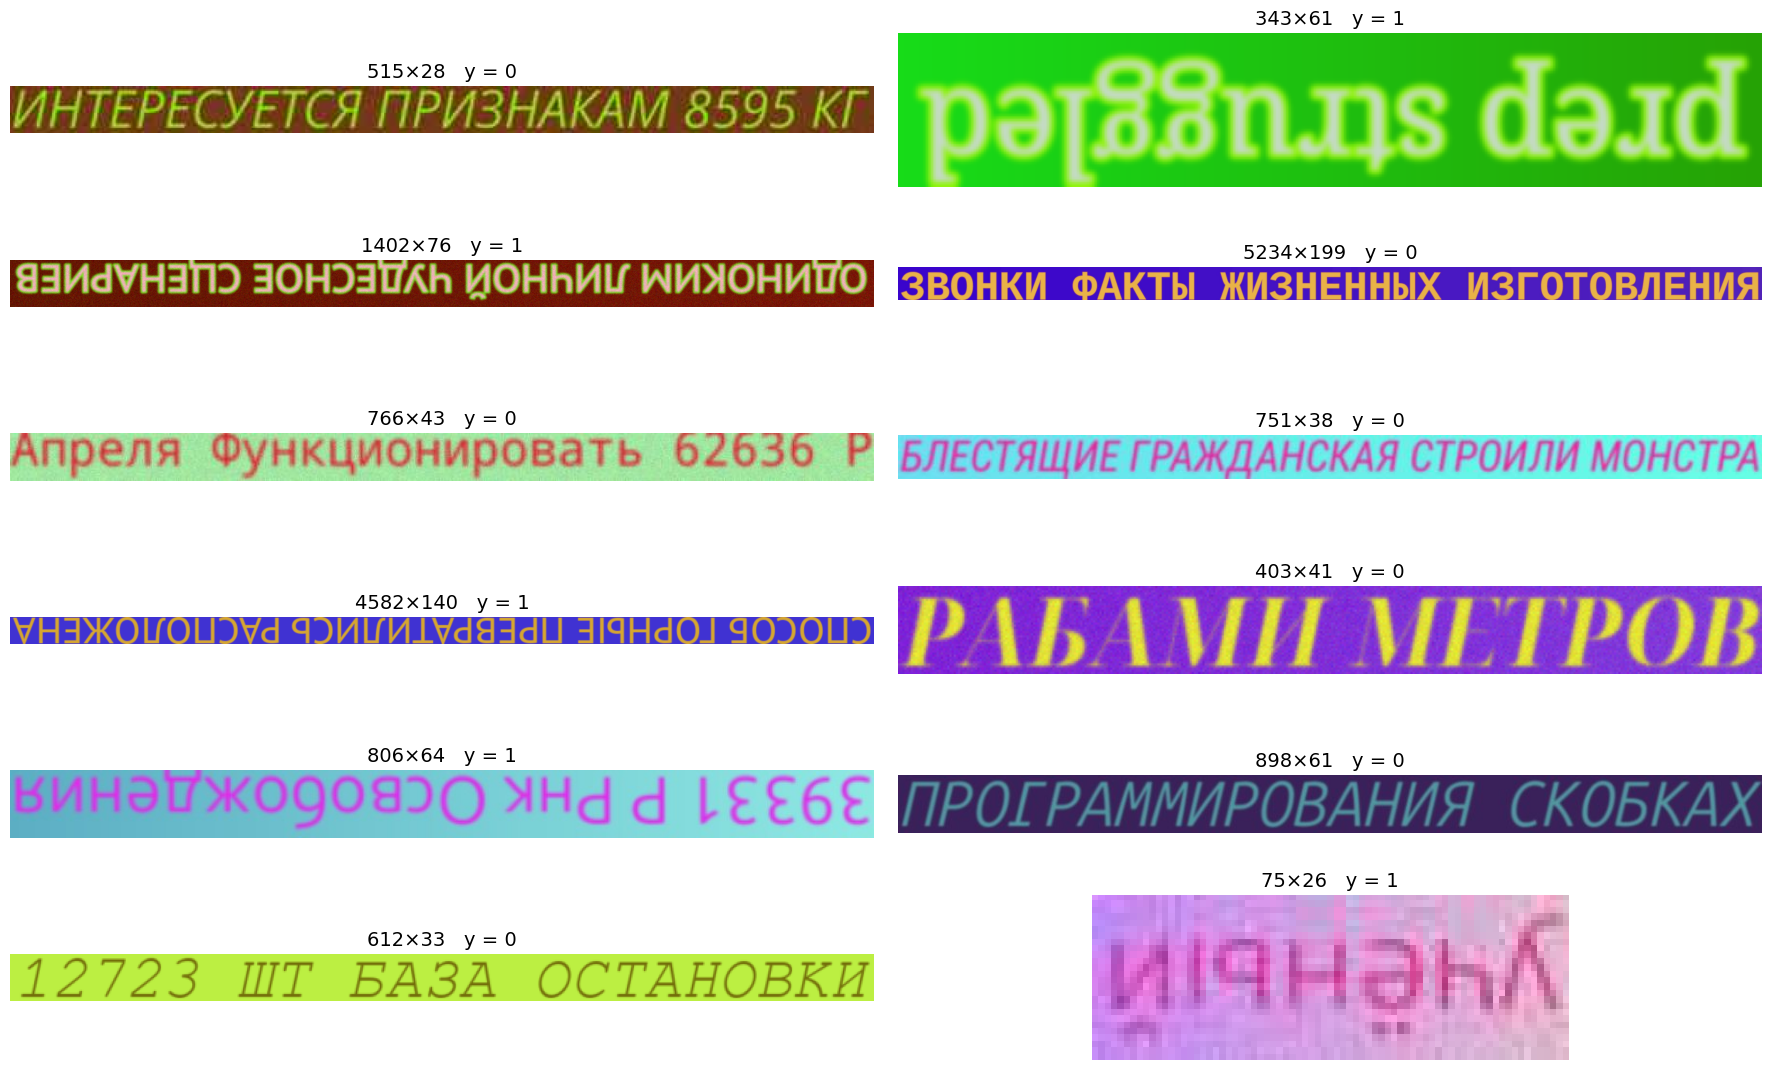

In [55]:
import io

TEST_HEIGHTS = df.h.values

def degrade(img, rng):
    h = int(rng.choice(TEST_HEIGHTS))
    w = max(8, round(img.width * h / img.height))
    img = img.resize((w, h), Image.BILINEAR)

    if rng.random() < 0.3:
        f = rng.uniform(1.5, 3.0)
        small = img.resize((max(4, round(w / f)), max(4, round(h / f))), Image.BILINEAR)
        img = small.resize((w, h), Image.BILINEAR)
    if rng.random() < 0.4:
        img = img.filter(ImageFilter.GaussianBlur(rng.uniform(0.3, 1.2)))
    if rng.random() < 0.25:
        arr = np.asarray(img, dtype=np.float32) + rng.normal(0, rng.uniform(3, 12), (h, w, 3))
        img = Image.fromarray(np.clip(arr, 0, 255).astype(np.uint8))
    if rng.random() < 0.7:
        buf = io.BytesIO()
        img.save(buf, format='JPEG', quality=int(rng.integers(30, 96)))
        img = Image.open(io.BytesIO(buf.getvalue())).convert('RGB')
    return img


def make_sample(rng):
    img, text = render_crop(rng)
    y = int(rng.integers(0, 2))
    # Поворот до деградаций: иначе сетка JPEG у перевёрнутых кропов смещена и выдаёт класс
    if y == 1:
        img = img.transpose(Image.Transpose.ROTATE_180)
    return degrade(img, rng), y, text


rng = np.random.default_rng(SEED)
fig, axes = plt.subplots(6, 2, figsize=(18, 11))
for ax in axes.ravel():
    img, y, text = make_sample(rng)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"{img.width}×{img.height}   y = {y}", fontsize=14)
plt.tight_layout()
plt.show()

In [56]:
SYN_DIR = Path('/content/syn_val')
SYN_DIR.mkdir(exist_ok=True)
N_SYN = 4000

shares = test_bin.value_counts(normalize=True).sort_index()
quota = (shares.values * N_SYN).round().astype(int)
edges = np.array(ASPECT_BINS)

def bin_index(aspect):
    # Интервалы вида (a, b]; всё, что ≤ 1.5, относим к первому, как и в тесте
    return max(int(np.searchsorted(edges, aspect, side='left')) - 1, 0)

rng = np.random.default_rng(SEED + 1)
filled = np.zeros(len(quota), dtype=int)
records, attempts = [], 0

with tqdm(total=int(quota.sum())) as bar:
    while (filled < quota).any():
        attempts += 1
        img, y, text = make_sample(rng)
        b = bin_index(img.width / img.height)
        if filled[b] >= quota[b]:
            continue
        filled[b] += 1
        crop_id = f"syn_{len(records):05d}.png"
        img.save(SYN_DIR / crop_id)
        records.append({'crop_id': crop_id, 'y': y, 'text': text, 'w': img.width, 'h': img.height,
                        'bin': shares.index[b]})
        bar.update(1)

syn = pd.DataFrame(records)
syn['aspect'] = syn.w / syn.h
syn['weight'] = 1.0
syn.to_csv(OUT_DIR / 'val_synth.csv', index=False)

print(f"Кропов: {len(syn)}, попыток: {attempts}, доля перевёрнутых: {syn.y.mean():.3f}")
print(pd.DataFrame({'тест': shares.values, 'синтетика': syn.bin.value_counts(normalize=True).sort_index().values},
                   index=shares.index).round(3))
print("\nВысота: синтетика", syn.h.quantile([.05, .5, .95]).values, "| тест", df.h.quantile([.05, .5, .95]).values)

  0%|          | 0/4000 [00:00<?, ?it/s]

Кропов: 4000, попыток: 23431, доля перевёрнутых: 0.493
              тест  синтетика
aspect                       
(1.5, 2.0]   0.020      0.020
(2.0, 3.0]   0.133      0.133
(3.0, 5.0]   0.363      0.363
(5.0, 8.0]   0.263      0.263
(8.0, 12.0]  0.132      0.132
(12.0, inf]  0.089      0.089

Высота: синтетика [ 16.  42. 188.] | тест [ 16.  42. 195.]


In [57]:
load_syn = lambda r: Image.open(SYN_DIR / r.crop_id).convert('RGB')

def metrics(frame, p_o, p_r):
    y, w = frame.y.values, frame.weight.values
    p = (p_o + 1 - p_r) / 2
    return {
        '1−Brier, один прогон': 1 - brier_score(y, p_o, w),
        '1−Brier, TTA': 1 - brier_score(y, p, w),
        'противоречий': np.average((p_o > 0.5) == (p_r > 0.5), weights=w),
    }

syn_runs = {name: two_passes(syn, load_syn, variants[name])
            for name in ['растягивание 80×160', 'пропорции + добивка до 160']}

print(pd.DataFrame({name: metrics(syn, *p) for name, p in syn_runs.items()}).T.round(4))
print("\nДля сравнения, тест: растягивание 0.9223 (противоречий 30%), пропорции 0.9054 (~48%)")

  0%|          | 0/63 [00:00<?, ?it/s]

  0%|          | 0/63 [00:00<?, ?it/s]

                            1−Brier, один прогон  1−Brier, TTA  противоречий
растягивание 80×160                       0.8588        0.9293        0.2972
пропорции + добивка до 160                0.8150        0.9133        0.4075

Для сравнения, тест: растягивание 0.9223 (противоречий 30%), пропорции 0.9054 (~48%)


In [58]:
rng = np.random.default_rng(SEED + 100)
gen_bins = np.bincount([bin_index(render_crop(rng)[0].size[0] / render_crop(rng)[0].size[1])
                        for _ in range(0)], minlength=len(shares))

оценка пропорций генератора:   0%|          | 0/3000 [00:00<?, ?it/s]

              тест  генератор  вероятность принять
aspect                                            
(1.5, 2.0]   0.020      0.006                0.499
(2.0, 3.0]   0.133      0.021                1.000
(3.0, 5.0]   0.363      0.091                0.639
(5.0, 8.0]   0.263      0.167                0.253
(8.0, 12.0]  0.132      0.293                0.072
(12.0, inf]  0.089      0.421                0.034


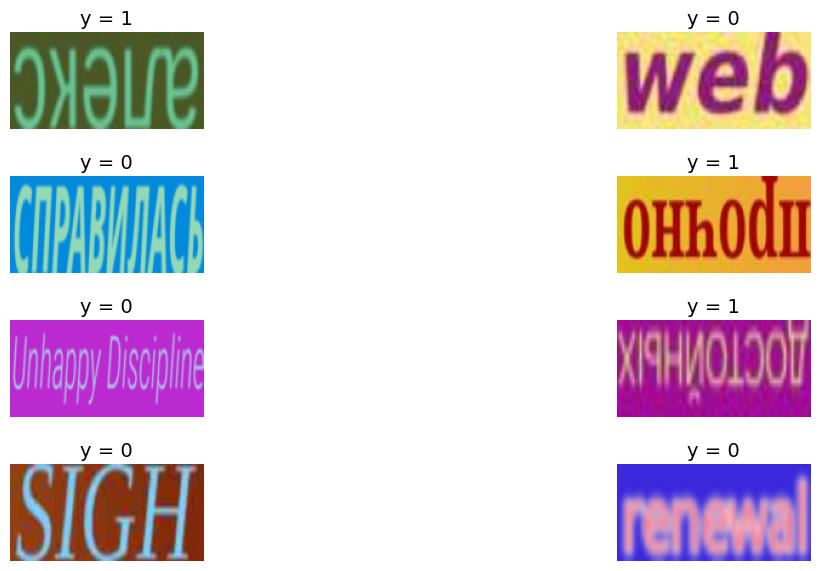

In [59]:
rng = np.random.default_rng(SEED + 100)
gen_counts = np.zeros(len(shares))
for _ in tqdm(range(3000), desc='оценка пропорций генератора'):
    img, _ = render_crop(rng)
    gen_counts[bin_index(img.width / img.height)] += 1

gen_share = gen_counts / gen_counts.sum()
accept = shares.values / np.maximum(gen_share, 1e-6)
ACCEPT = accept / accept.max()

print(pd.DataFrame({'тест': shares.values, 'генератор': gen_share, 'вероятность принять': ACCEPT},
                   index=shares.index).round(3))


class SynthOrientationDataset(torch.utils.data.Dataset):
    def __init__(self, n, seed):
        self.n, self.seed, self.epoch = n, seed, 0

    def __len__(self):
        return self.n

    def __getitem__(self, i):
        rng = np.random.default_rng([self.seed, self.epoch, i])
        while True:
            img, _ = render_crop(rng)
            if rng.random() < ACCEPT[bin_index(img.width / img.height)]:
                break
        y = int(rng.integers(0, 2))
        if y == 1:
            img = img.transpose(Image.Transpose.ROTATE_180)
        return to_tensor(degrade(img, rng), W_REF), y


train_ds = SynthOrientationDataset(n=20000, seed=SEED + 2)

fig, axes = plt.subplots(4, 2, figsize=(16, 6))
for ax, i in zip(axes.ravel(), range(8)):
    x, y = train_ds[i]
    ax.imshow(show_tensor(x[[2, 1, 0]]))
    ax.axis('off')
    ax.set_title(f"y = {y}", fontsize=14)
plt.tight_layout()
plt.show()

In [60]:
t0 = time.time()
_ = [train_ds[i] for i in range(200)]
dt = (time.time() - t0) / 200
print(f"{dt * 1000:.1f} мс на пример → эпоха из {len(train_ds)} примеров ≈ {dt * len(train_ds) / 60:.1f} мин в одном процессе")
print("Ядер CPU:", os.cpu_count())

131.1 мс на пример → эпоха из 20000 примеров ≈ 43.7 мин в одном процессе
Ядер CPU: 2


In [61]:
def make_text(rng, max_ru=4, max_en=3, max_mixed=2):
    kind = rng.random()
    if kind < 0.60:
        words = list(rng.choice(RU_WORDS, rng.integers(1, max_ru + 1)))
    elif kind < 0.75:
        words = list(rng.choice(EN_WORDS, rng.integers(1, max_en + 1)))
    else:
        words = list(rng.choice(RU_WORDS, rng.integers(1, max_mixed + 1)))
        words.insert(int(rng.integers(0, len(words) + 1)), f"{rng.integers(1, 100000)} {rng.choice(UNITS)}")
    text = ' '.join(words)
    case = rng.random()
    return text.upper() if case < 0.4 else text.title() if case < 0.7 else text


def render_crop(rng, accept_fn=None, **text_kw):
    text = make_text(rng, **text_kw)
    font = ImageFont.truetype(str(rng.choice(FONTS)), int(rng.integers(28, 97)))
    bg, fg = contrasting_colors(rng)
    stroke = int(rng.integers(1, 4)) if rng.random() < 0.15 else 0

    x0, y0, x1, y1 = font.getbbox(text, stroke_width=stroke)
    tw, th = x1 - x0, y1 - y0
    mt, mb = (rng.uniform(-0.05, 0.20, 2) * th).astype(int)
    ml, mr = (rng.uniform(-0.03, 0.15, 2) * th).astype(int)
    W, H = max(tw + ml + mr, 8), max(th + mt + mb, 8)

    # Проверка пропорций до рисования: отбракованный кроп не тратит время на фон и текст
    if accept_fn is not None and not accept_fn(W / H):
        return None, text

    img = make_background(rng, W, H, bg)
    ImageDraw.Draw(img).text((ml - x0, mt - y0), text, font=font, fill=fg,
                             stroke_width=stroke, stroke_fill=random_color(rng))
    return img, text

In [62]:
TRAIN_TEXT = dict(max_ru=3, max_en=2, max_mixed=1)

rng = np.random.default_rng(SEED + 100)
gen_counts = np.zeros(len(shares))
def record(aspect):
    gen_counts[bin_index(aspect)] += 1
    return False

for _ in range(5000):
    render_crop(rng, accept_fn=record, **TRAIN_TEXT)

gen_share = gen_counts / gen_counts.sum()
ACCEPT = shares.values / np.maximum(gen_share, 1e-6)
ACCEPT /= ACCEPT.max()
print(pd.DataFrame({'тест': shares.values, 'генератор': gen_share, 'вероятность принять': ACCEPT},
                   index=shares.index).round(3))
print(f"Доля принятых: {(gen_share * ACCEPT).sum():.2f}")


class SynthOrientationDataset(torch.utils.data.Dataset):
    def __init__(self, n, seed):
        self.n, self.seed, self.epoch = n, seed, 0

    def __len__(self):
        return self.n

    def __getitem__(self, i):
        # Генератор на каждый пример: картинка зависит только от (seed, epoch, i),
        # а не от порядка загрузки и числа процессов DataLoader
        rng = np.random.default_rng([self.seed, self.epoch, i])
        accept = lambda a: rng.random() < ACCEPT[bin_index(a)]
        img = None
        while img is None:
            img, _ = render_crop(rng, accept_fn=accept, **TRAIN_TEXT)
        y = int(rng.integers(0, 2))
        if y == 1:
            img = img.transpose(Image.Transpose.ROTATE_180)
        return to_tensor(degrade(img, rng), W_REF), y


train_ds = SynthOrientationDataset(n=20000, seed=SEED + 2)

t0 = time.time()
_ = [train_ds[i] for i in range(200)]
dt = (time.time() - t0) / 200
print(f"\n{dt * 1000:.1f} мс на пример → эпоха ≈ {dt * len(train_ds) / 60 / os.cpu_count():.1f} мин на {os.cpu_count()} ядрах")

              тест  генератор  вероятность принять
aspect                                            
(1.5, 2.0]   0.020      0.009                0.480
(2.0, 3.0]   0.133      0.030                1.000
(3.0, 5.0]   0.363      0.124                0.653
(5.0, 8.0]   0.263      0.246                0.239
(8.0, 12.0]  0.132      0.357                0.083
(12.0, inf]  0.089      0.233                0.085
Доля принятых: 0.22

36.5 мс на пример → эпоха ≈ 6.1 мин на 2 ядрах


## Дообучение модели на синтетических данных

### Проверка синтетической валидации

| Вариант предобработки | Синтетика | Тест (платформа) | RusTitW |
|---|---|---|---|
| Растягивание 80×160 | **0.929**, противоречий 30% | **0.922**, 30% | 0.909 |
| Сохранение пропорций | 0.913, противоречий 41% | 0.905, ~48% | 0.932 |

Синтетическая валидация воспроизводит поведение теста: растягивание лучше, с сохранением пропорций растёт доля противоречий, абсолютные значения близки к результату на платформе. RusTitW этого эффекта не показала из-за свободных рамок разметки. Поэтому дальше **главная валидация — синтетика**, RusTitW — контроль на реальных фото, доля противоречий на тесте — финальная проверка без меток.

### Зачем дообучать

Модель PaddleOCR обучалась в основном на китайском и английском тексте документов. В тесте — кириллица с рекламных баннеров, плотно обрезанная детектором. Отсюда ~30% противоречий между прогонами и перекос в сторону класса «180°». Модель уже умеет различать ориентацию, поэтому не обучаем её с нуля, а продолжаем обучение с текущих весов (fine-tuning) на данных, похожих на тест.

### Обучающие данные

- Синтетические кропы генерируются на лету, отдельный seed (`SEED + 2`), они не совпадают с валидационными (`SEED + 1`).
- Каждый пример однозначно задаётся тройкой (seed, эпоха, номер примера): результат воспроизводим и не зависит от числа процессов загрузки, а в каждой эпохе модель видит новые картинки.
- Пропорции кропов приводятся к распределению теста выборкой с отбраковкой (rejection sampling): кроп принимается с вероятностью `доля интервала в тесте / доля у генератора`. Проверка пропорций делается до отрисовки, поэтому отбракованные кропы почти ничего не стоят.
- Для обучения тексты короче, чем в валидации (до 3 русских слов), чтобы реже отбраковывать и чаще получать короткие русские кропы.
- Вход модели — 80×160 с растягиванием, через функцию `to_tensor`, которая совпадает с `processor` с точностью до округления.

### Параметры обучения

- 4 эпохи по 20 000 примеров, батч 128.
- Функция потерь — кросс-энтропия со сглаживанием меток 0.05: цели 0.025 и 0.975 вместо 0 и 1, чтобы снизить переуверенность модели.
- Оптимизатор AdamW, максимальная скорость обучения 3·10⁻⁴ с расписанием OneCycle (плавный рост, затем спад до нуля).
- После каждой эпохи — оценка на синтетической валидации и RusTitW с TTA. Лучшая по синтетике модель сохраняется на Drive.
- Эпоха 0 — оценка до обучения: должна совпасть с бейзлайном и подтвердить, что новый путь предсказания работает так же, как `processor`.

**Критерий успеха:** синтетика растёт, RusTitW не падает. Если растёт только синтетика, модель подстроилась под стиль генератора.

In [63]:
EPOCHS, LR, TRAIN_BATCH = 4, 3e-4, 128


def get_logits(out):
    return out.logits if getattr(out, 'logits', None) is not None else out.last_hidden_state


def stretch_predictor(m):
    @torch.no_grad()
    def predict(imgs):
        x = torch.stack([to_tensor(im, W_REF) for im in imgs]).to(device)
        return get_logits(m(pixel_values=x)).softmax(-1)[:, IDX_180].cpu().numpy()
    return predict


def evaluate_model(m):
    m.eval()
    fn = stretch_predictor(m)
    res = {'синтетика': metrics(syn, *two_passes(syn, load_syn, fn, BATCH)),
           'RusTitW': metrics(val, *two_passes(val, load_val_image, fn, BATCH))}
    return {f'{d}: {k}': v for d, r in res.items() for k, v in r.items() if k != '1−Brier, один прогон'}


In [64]:
set_seed(SEED)
ft_model = AutoModelForImageClassification.from_pretrained(MODEL_ID).to(device)
loader = torch.utils.data.DataLoader(train_ds, batch_size=TRAIN_BATCH, num_workers=os.cpu_count(), pin_memory=True)
opt = torch.optim.AdamW(ft_model.parameters(), lr=LR, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=LR, total_steps=EPOCHS * len(loader), pct_start=0.1)
loss_fn = torch.nn.CrossEntropyLoss(label_smoothing=0.05)

history = [{'эпоха': 0, **evaluate_model(ft_model)}]
best = history[0]['синтетика: 1−Brier, TTA']
print(pd.DataFrame(history).set_index('эпоха').round(4))

for epoch in range(1, EPOCHS + 1):
    # Датасет копируется в процессы загрузки при каждом новом проходе, поэтому номер эпохи доходит до них
    train_ds.epoch = epoch
    ft_model.train()
    losses = []
    for x, y in tqdm(loader, desc=f'эпоха {epoch}'):
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        loss = loss_fn(get_logits(ft_model(pixel_values=x)), y)
        opt.zero_grad()
        loss.backward()
        opt.step()
        sched.step()
        losses.append(loss.item())

    history.append({'эпоха': epoch, 'loss': np.mean(losses), **evaluate_model(ft_model)})
    print(pd.DataFrame(history).set_index('эпоха').round(4))

    if history[-1]['синтетика: 1−Brier, TTA'] > best:
        best = history[-1]['синтетика: 1−Brier, TTA']
        torch.save(ft_model.state_dict(), OUT_DIR / 'ft_best.pt')
        print(f"сохранена лучшая модель, эпоха {epoch}")

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

  0%|          | 0/18 [00:00<?, ?it/s]

       синтетика: 1−Brier, TTA  синтетика: противоречий  RusTitW: 1−Brier, TTA  RusTitW: противоречий
эпоха                                                                                                
0                       0.9336                   0.2882                  0.909                 0.2473


эпоха 1:   0%|          | 0/157 [00:00<?, ?it/s]

...

       синтетика: 1−Brier, TTA  синтетика: противоречий  RusTitW: 1−Brier, TTA  RusTitW: противоречий    loss
эпоха                                                                                                        
0                       0.9336                   0.2882                 0.9090                 0.2473     NaN
1                       0.9900                   0.0205                 0.9032                 0.1838  0.3148
2                       0.9920                   0.0142                 0.9033                 0.1967  0.1485
3                       0.9933                   0.0098                 0.9095                 0.1757  0.1384
сохранена лучшая модель, эпоха 3


эпоха 4:   0%|          | 0/157 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

  0%|          | 0/18 [00:00<?, ?it/s]

       синтетика: 1−Brier, TTA  синтетика: противоречий  RusTitW: 1−Brier, TTA  RusTitW: противоречий    loss
эпоха                                                                                                        
0                       0.9336                   0.2882                 0.9090                 0.2473     NaN
1                       0.9900                   0.0205                 0.9032                 0.1838  0.3148
2                       0.9920                   0.0142                 0.9033                 0.1967  0.1485
3                       0.9933                   0.0098                 0.9095                 0.1757  0.1384
4                       0.9935                   0.0095                 0.9066                 0.1789  0.1358
сохранена лучшая модель, эпоха 4


In [65]:
ft_model.load_state_dict(torch.load(OUT_DIR / 'ft_best.pt'))
model.eval()
ft_model.eval()
predictors = {'исходная': stretch_predictor(model), 'дообученная': stretch_predictor(ft_model)}
datasets = {'RusTitW': (val, load_val_image), 'синтетика': (syn, load_syn), 'тест': (df, load_test)}

runs = {(d, m): two_passes(frame, load_fn, fn, BATCH)
        for d, (frame, load_fn) in datasets.items() for m, fn in predictors.items()}
np.savez(OUT_DIR / 'runs_orig_ft.npz', **{f'{d}|{m}|{k}': arr for (d, m), pair in runs.items()
                                          for k, arr in zip(('orig', 'rot'), pair)})


def logit(p):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p))

def calibrate(p, T):
    return 1 / (1 + np.exp(-logit(p) / T))

def passes(d, variant, T=1.0):
    (o0, r0), (o1, r1) = runs[(d, 'исходная')], runs[(d, 'дообученная')]
    o, r = {'исходная': (o0, r0), 'дообученная': (o1, r1), 'ансамбль': ((o0 + o1) / 2, (r0 + r1) / 2)}[variant]
    return calibrate(o, T), calibrate(r, T)

def score(frame, p_o, p_r, mask=None):
    mask = np.ones(len(frame), bool) if mask is None else mask
    p = (p_o + 1 - p_r) / 2
    return 1 - brier_score(frame.y.values[mask], p[mask], frame.weight.values[mask])


names = val.image_name.unique()
half_a = set(np.random.default_rng(SEED).permutation(names)[:len(names) // 2])
mask_a = val.image_name.isin(half_a).values
mask_b = ~mask_a
T_GRID = np.round(np.arange(0.5, 5.01, 0.05), 2)

rows = []
for variant in ['исходная', 'дообученная', 'ансамбль']:
    T_best = max(T_GRID, key=lambda T: score(val, *passes('RusTitW', variant, T), mask_a))
    for T in [1.0, T_best]:
        o_t, r_t = passes('тест', variant, T)
        rows.append({
            'вариант': variant + ('' if T == 1.0 else f' + T={T}'),
            'RusTitW B': score(val, *passes('RusTitW', variant, T), mask_b),
            'синтетика': score(syn, *passes('синтетика', variant, T)),
            'тест: противоречий': ((o_t > 0.5) == (r_t > 0.5)).mean(),
            'тест: неуверенных': ((o_t + 1 - r_t) / 2 > 0.2).mean() - ((o_t + 1 - r_t) / 2 >= 0.8).mean(),
        })

print(pd.DataFrame(rows).set_index('вариант').round(4))

  0%|          | 0/18 [00:00<?, ?it/s]

  0%|          | 0/18 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

                      RusTitW B  синтетика  тест: противоречий  тест: неуверенных
вариант                                                                          
исходная                 0.9147     0.9336              0.2998             0.3428
исходная + T=1.85        0.9153     0.9389              0.2998             0.3950
дообученная              0.9135     0.9935              0.0684             0.1698
дообученная + T=0.85     0.9158     0.9942              0.0684             0.1498
ансамбль                 0.9285     0.9766              0.1405             0.2982
ансамбль + T=0.55        0.9352     0.9812              0.1405             0.2260


### Итоги дообучения и выбор варианта для сабмита 3

**Дообучение (4 эпохи на синтетике).**

| Эпоха | Синтетика: 1−Brier (TTA) | RusTitW: 1−Brier (TTA) | RusTitW: противоречий |
|---|---|---|---|
| 0 (исходная) | 0.9336 | 0.9090 | 24.7% |
| 4 | 0.9935 | 0.9066 | 17.9% |

На синтетике модель почти сразу выходит на 0.99: обучающие и валидационные кропы рисует один генератор, и модель выучивает его стиль. Поэтому для дообученной модели синтетическая валидация завышена и дальше используется только для справки. На реальных фото (RusTitW) качество не изменилось: противоречий меньше, но ошибки стали увереннее, а Brier такие ошибки сильно штрафует.

**Сравниваемые варианты.**
- **Исходная и дообученная** модели по отдельности.
- **Ансамбль** — среднее вероятностей двух моделей для каждого прогона, затем TTA. Модели обучались на разных данных и ошибаются на разных кропах, поэтому среднее исправляет часть ошибок каждой.
- **Калибровка температурой.** Логит вероятности делится на число T: T > 1 делает ответы менее уверенными, T < 1 — более уверенными. Какой класс выбран, при этом не меняется. T подбирается по сетке 0.5–5.0.

**Честная оценка калибровки.** RusTitW делится пополам по фотографиям (кропы одного фото целиком попадают в одну половину). На половине A подбирается T, на половине B сравниваются все варианты.

| Вариант | RusTitW, половина B | Противоречий на тесте |
|---|---|---|
| Исходная | 0.9147 | 30.0% |
| Исходная + T = 1.85 | 0.9153 | 30.0% |
| Дообученная | 0.9135 | 6.8% |
| Дообученная + T = 0.85 | 0.9158 | 6.8% |
| Ансамбль | 0.9285 | 14.1% |
| **Ансамбль + T = 0.55** | **0.9352** | 14.1% |

**Выводы.**
- Дообученная модель на тесте противоречит себе в 7% случаев вместо 30%: тест ближе к синтетике, чем к RusTitW. Но на реальных фото она не лучше исходной, поэтому отдельно не используется.
- Ансамбль лучше обеих моделей на реальных фото (+0.014) и вдвое снижает долю противоречий на тесте. Улучшились оба независимых сигнала.
- Для ансамбля оптимальна T = 0.55 < 1: когда модели не согласны, их среднее сползает к 0.5, и калибровка возвращает оправданную уверенность. Прирост (+0.007) измерен на половине B, не участвовавшей в подборе T.

**Сабмит 3: ансамбль исходной и дообученной моделей, TTA, калибровка T = 0.55.**

In [66]:
T_ENS = 0.55

o, r = passes('тест', 'ансамбль', T_ENS)
df['p_180_ens'] = (o + 1 - r) / 2

preds = df.assign(image_id=df.image_id.str.rsplit('.', n=1).str[0])[['image_id', 'p_180_ens']]
sub = sample_sub[['image_id']].merge(preds.rename(columns={'p_180_ens': 'p_180'}), on='image_id', how='left')

assert sub.image_id.tolist() == sample_sub.image_id.tolist()
assert sub.p_180.notna().all() and sub.p_180.between(0, 1).all()

backup = OUT_DIR / 'sub_03_ensemble_T055.csv'
assert not backup.exists(), f"{backup.name} уже есть"
sub.to_csv('submission.csv', index=False, float_format='%.6f')
sub.to_csv(backup, index=False, float_format='%.6f')

print(sub.head())
print(f"Средний p_180: {sub.p_180.mean():.3f}")
print(f"Согласие с сабмитом 1 (по решению): {((sub.p_180 > 0.5) == (pd.read_csv(OUT_DIR / 'sub_01_baseline_tta.csv').p_180 > 0.5)).mean():.1%}")
files.download('submission.csv')

     image_id     p_180
0  test_00000  0.085927
1  test_00001  0.997584
2  test_00002  0.999716
3  test_00003  0.012863
4  test_00004  0.999316
Средний p_180: 0.502
Согласие с сабмитом 1 (по решению): 95.9%


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Сабмит 3 — результат и связь валидаций с тестом

**Результат:** 1 − Brier = **0.9602** (Brier = 0.0398). Ошибка по сравнению с сабмитом 1 (0.9223) уменьшилась почти вдвое.

| Сабмит | Вариант | Тест |
|---|---|---|
| 1 | исходная модель, растягивание, TTA | 0.9223 |
| 2 | исходная модель, сохранение пропорций, TTA | 0.9054 |
| 3 | ансамбль исходной и дообученной, TTA, T = 0.55 | **0.9602** |

**Смесь валидаций как замена тесту.** Результаты на тесте хорошо описываются взвешенной суммой двух валидаций: 0.54 × синтетика + 0.46 × RusTitW.

| Вариант | Синтетика | RusTitW (половина B) | Смесь | Тест |
|---|---|---|---|---|
| Исходная модель | 0.9336 | 0.9147 | 0.925 | 0.922 |
| Ансамбль + T = 0.55 | 0.9812 | 0.9352 | 0.960 | 0.960 |

Коэффициент 0.54 подобран по сабмиту 3, а сабмит 1 в подборе не участвовал и совпал с точностью до 0.003. Смесь используется как ориентир для выбора параметров без траты сабмитов. Ограничение: она наследует ошибки отдельных валидаций. Например, для сохранения пропорций (сабмит 2) RusTitW дала неверный сигнал, и смесь его не исправляет. Коэффициент получен по результатам на тесте — это использование обратной связи от сабмитов.

Прогноз для дообученной модели без ансамбля: 0.54 × 0.9942 + 0.46 × 0.9158 ≈ 0.958 — хуже ансамбля, отдельно не отправляется.

### Подбор доли моделей в ансамбле и температуры

Ансамбль в сабмите 3 — простое среднее (доля дообученной модели w = 0.5). Подбираем w (от 0 до 1 с шагом 0.1) и температуру T (от 0.3 до 2.0 с шагом 0.05) по смеси валидаций. Для честной оценки обе валидации делятся пополам: RusTitW — по фотографиям, синтетика — случайно с фиксированным seed. Параметры подбираются на половинах A, сравниваются на половинах B.



In [67]:
ALPHA = 0.54
syn_a = np.random.default_rng(SEED).random(len(syn)) < 0.5
syn_b = ~syn_a


def passes_w(d, w, T):
    (o0, r0), (o1, r1) = runs[(d, 'исходная')], runs[(d, 'дообученная')]
    return calibrate((1 - w) * o0 + w * o1, T), calibrate((1 - w) * r0 + w * r1, T)


def proxy(w, T, half):
    rus_mask, syn_mask = (mask_a, syn_a) if half == 'A' else (mask_b, syn_b)
    return (ALPHA * score(syn, *passes_w('синтетика', w, T), syn_mask)
            + (1 - ALPHA) * score(val, *passes_w('RusTitW', w, T), rus_mask))


W_GRID = np.round(np.arange(0, 1.01, 0.1), 2)
T_GRID2 = np.round(np.arange(0.3, 2.01, 0.05), 2)
grid = pd.DataFrame([{'w': w, 'T': T, 'A': proxy(w, T, 'A')} for w in W_GRID for T in T_GRID2])

per_w = grid.loc[grid.groupby('w').A.idxmax()].reset_index(drop=True)
per_w['B'] = [proxy(w, T, 'B') for w, T in zip(per_w.w, per_w['T'])]
per_w['тест: противоречий'] = [((o > .5) == (r > .5)).mean()
                               for o, r in (passes_w('тест', w, 1.0) for w in per_w.w)]

current_B = proxy(0.5, 0.55, 'B')
best = per_w.loc[per_w.A.idxmax()]
print(per_w.round(4))
print(f"\nТекущий (w=0.5, T=0.55): B = {current_B:.4f}")
print(f"Лучший по A (w={best.w}, T={best['T']}): B = {best.B:.4f}, прирост {best.B - current_B:+.4f}")

      w     T       A       B  тест: противоречий
0   0.0  1.95  0.9248  0.9276              0.2998
1   0.1  1.35  0.9302  0.9338              0.2874
2   0.2  1.15  0.9356  0.9396              0.2702
3   0.3  0.95  0.9411  0.9457              0.2470
4   0.4  0.75  0.9470  0.9525              0.2135
5   0.5  0.40  0.9536  0.9605              0.1405
6   0.6  0.30  0.9584  0.9665              0.0940
7   0.7  0.45  0.9583  0.9667              0.0776
8   0.8  0.60  0.9565  0.9645              0.0713
9   0.9  0.70  0.9541  0.9617              0.0680
10  1.0  0.80  0.9512  0.9583              0.0684

Текущий (w=0.5, T=0.55): B = 0.9599
Лучший по A (w=0.6, T=0.3): B = 0.9665, прирост +0.0066


In [68]:
from scipy.optimize import minimize

def z_feature(d, m):
    o, r = runs[(d, m)]
    return logit(o) - logit(r)

Z = {d: np.stack([z_feature(d, 'исходная'), z_feature(d, 'дообученная')], axis=1)
     for d in ['синтетика', 'RusTitW', 'тест']}

def stack_proba(c, Zd):
    return 1 / (1 + np.exp(-np.clip(Zd @ c, -50, 50)))

def stack_proxy(c, half):
    rus_mask, syn_mask = (mask_a, syn_a) if half == 'A' else (mask_b, syn_b)
    s = 1 - brier_score(syn.y.values[syn_mask], stack_proba(c, Z['синтетика'][syn_mask]))
    r = 1 - brier_score(val.y.values[rus_mask], stack_proba(c, Z['RusTitW'][rus_mask]), val.weight.values[rus_mask])
    return ALPHA * s + (1 - ALPHA) * r

res = minimize(lambda c: -stack_proxy(c, 'A'), x0=[0.25, 0.25], method='Nelder-Mead')
c = res.x

print(f"c₁ = {c[0]:.3f}, c₂ = {c[1]:.3f}")
print(f"Доля дообученной: {c[1] / c.sum():.2f}, эквивалентная температура: {0.5 / c.sum():.2f}")
print(f"Смесь: A = {stack_proxy(c, 'A'):.4f}, B = {stack_proxy(c, 'B'):.4f}")
print(f"Для сравнения, перебор w=0.7, T=0.45: B = {proxy(0.7, 0.45, 'B'):.4f}")

p_stack = stack_proba(c, Z['тест'])
prev = pd.read_csv(OUT_DIR / 'sub_03_ensemble_T055.csv').p_180.values
order_ok = (df.image_id.str.rsplit('.', n=1).str[0].values == pd.read_csv(OUT_DIR / 'sub_03_ensemble_T055.csv').image_id.values).all()
print(f"\nСогласие с сабмитом 3 по решению: {((p_stack > 0.5) == (prev > 0.5)).mean():.1%} (порядок строк совпадает: {order_ok})")

c₁ = 0.174, c₂ = 0.403
Доля дообученной: 0.70, эквивалентная температура: 0.87
Смесь: A = 0.9644, B = 0.9693
Для сравнения, перебор w=0.7, T=0.45: B = 0.9667

Согласие с сабмитом 3 по решению: 98.6% (порядок строк совпадает: True)


In [69]:
preds = pd.DataFrame({'image_id': df.image_id.str.rsplit('.', n=1).str[0], 'p_180': p_stack})
sub = sample_sub[['image_id']].merge(preds, on='image_id', how='left')

assert sub.image_id.tolist() == sample_sub.image_id.tolist()
assert sub.p_180.notna().all() and sub.p_180.between(0, 1).all()

backup = OUT_DIR / 'sub_04_stacking.csv'
assert not backup.exists(), f"{backup.name} уже есть"
sub.to_csv('submission.csv', index=False, float_format='%.6f')
sub.to_csv(backup, index=False, float_format='%.6f')
np.save(OUT_DIR / 'stacking_coefs.npy', c)

print(sub.head())
print(f"Средний p_180: {sub.p_180.mean():.3f}")
files.download('submission.csv')

     image_id     p_180
0  test_00000  0.011043
1  test_00001  0.997168
2  test_00002  0.996947
3  test_00003  0.015168
4  test_00004  0.997044
Средний p_180: 0.500


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [70]:
files.download('submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [71]:
cache = Path.home() / '.cache' / 'huggingface' / 'hub'
snapshots = next(cache.glob('models--PaddlePaddle--PP-LCNet_x1_0_textline_ori_safetensors')) / 'snapshots'
MODEL_REVISION = next(snapshots.iterdir()).name
print("Версия модели (revision):", MODEL_REVISION)

base = AutoModelForImageClassification.from_pretrained(MODEL_ID, revision=MODEL_REVISION).to(device).eval()
ft = AutoModelForImageClassification.from_pretrained(MODEL_ID, revision=MODEL_REVISION).to(device)
ft.load_state_dict(torch.load(OUT_DIR / 'ft_best.pt', map_location=device))
ft.eval()
coefs = np.load(OUT_DIR / 'stacking_coefs.npy')

z_cols = []
for m in (base, ft):
    o, r = two_passes(df, load_test, stretch_predictor(m), BATCH)
    z_cols.append(logit(o) - logit(r))
p_repro = stack_proba(coefs, np.stack(z_cols, axis=1))

sent = pd.read_csv(OUT_DIR / 'sub_04_stacking.csv')
repro = sample_sub[['image_id']].merge(
    pd.DataFrame({'image_id': df.image_id.str.rsplit('.', n=1).str[0], 'p_180': p_repro}), on='image_id')

diff = (repro.p_180.round(6) - sent.p_180).abs()
print(f"Коэффициенты: {coefs}")
print(f"Макс. разница с отправленным файлом: {diff.max():.2e}, строк с разницей > 1e-6: {(diff > 1e-6).sum()}")

Версия модели (revision): 9f1b0e272ba4e5d89aef7cf52998c6646862c5a7


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Коэффициенты: [0.17404394 0.40308749]
Макс. разница с отправленным файлом: 0.00e+00, строк с разницей > 1e-6: 0


## Сохранение проекта

In [72]:
import shutil

REPO = Path('/content/drive/MyDrive/orientation_repo')
for d in ['src', 'scripts', 'weights']:
    (REPO / d).mkdir(parents=True, exist_ok=True)
(REPO / 'src' / '__init__.py').touch()

shutil.copy(OUT_DIR / 'ft_best.pt', REPO / 'weights' / 'ft_best.pt')
shutil.copy(OUT_DIR / 'stacking_coefs.npy', REPO / 'weights' / 'stacking_coefs.npy')

(REPO / 'src' / 'config.py').write_text(f'''"""Общие константы решения."""

SEED = {SEED}

MODEL_ID = "{MODEL_ID}"
MODEL_REVISION = "{MODEL_REVISION}"

# Вход модели: как в PPLCNetImageProcessor для этой модели
INPUT_HEIGHT = {H_IN}
INPUT_WIDTH = {W_REF}
IMAGE_MEAN = {list(processor.image_mean)}
IMAGE_STD = {list(processor.image_std)}
''')
print((REPO / 'src' / 'config.py').read_text())

"""Общие константы решения."""

SEED = 42

MODEL_ID = "PaddlePaddle/PP-LCNet_x1_0_textline_ori_safetensors"
MODEL_REVISION = "9f1b0e272ba4e5d89aef7cf52998c6646862c5a7"

# Вход модели: как в PPLCNetImageProcessor для этой модели
INPUT_HEIGHT = 80
INPUT_WIDTH = 160
IMAGE_MEAN = [0.406, 0.456, 0.485]
IMAGE_STD = [0.225, 0.224, 0.229]



In [74]:
%%writefile /content/drive/MyDrive/orientation_repo/src/inference.py
"""Предсказание вероятности поворота текста на 180°: предобработка, два прогона, стэкинг."""
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from transformers import AutoModelForImageClassification

from .config import MODEL_ID, MODEL_REVISION, INPUT_HEIGHT, INPUT_WIDTH, IMAGE_MEAN, IMAGE_STD

_MEAN = torch.tensor(IMAGE_MEAN).view(3, 1, 1)
_STD = torch.tensor(IMAGE_STD).view(3, 1, 1)


def to_tensor(im, w=INPUT_WIDTH, h=INPUT_HEIGHT):
    """Повторяет PPLCNetImageProcessor с точностью до округления.

    Ресайз до h×w без сохранения пропорций (сохранение пропорций на тесте ухудшает качество),
    нормализация в порядке RGB, затем разворот каналов в BGR — так модель обучалась в PaddleOCR.
    """
    x = torch.from_numpy(np.asarray(im, dtype=np.float32) / 255).permute(2, 0, 1)
    x = F.interpolate(x[None], size=(h, w), mode='bilinear', align_corners=False, antialias=True)[0]
    return ((x - _MEAN) / _STD)[[2, 1, 0]]


def get_logits(out):

    return out.logits if getattr(out, 'logits', None) is not None else out.last_hidden_state


def load_model(device, weights=None):
    model = AutoModelForImageClassification.from_pretrained(MODEL_ID, revision=MODEL_REVISION).to(device)
    if weights is not None:
        model.load_state_dict(torch.load(weights, map_location=device))
    return model.eval()


def class_180_index(model):
    return next(int(k) for k, v in model.config.id2label.items() if '180' in str(v))


@torch.no_grad()
def predict_p180(model, imgs, device):
    x = torch.stack([to_tensor(im) for im in imgs]).to(device)
    return get_logits(model(pixel_values=x)).softmax(-1)[:, class_180_index(model)].cpu().numpy()


def two_passes(model, paths, aspects, device, batch=256):
    """Вероятность поворота для каждого кропа и для его копии, повёрнутой на 180°.

    Кропы обрабатываются в порядке возрастания отношения сторон: порядок сохранён,
    чтобы численно в точности повторить отправленный сабмит.
    """
    order = np.argsort(aspects)
    p_orig, p_rot = np.empty(len(paths)), np.empty(len(paths))
    for i in range(0, len(paths), batch):
        idx = order[i:i + batch]
        imgs = [Image.open(paths[j]).convert('RGB') for j in idx]
        p_orig[idx] = predict_p180(model, imgs, device)
        p_rot[idx] = predict_p180(model, [im.transpose(Image.Transpose.ROTATE_180) for im in imgs], device)
    return p_orig, p_rot


def logit(p, eps=1e-6):
    p = np.clip(p, eps, 1 - eps)
    return np.log(p / (1 - p))


def orientation_feature(p_orig, p_rot):
    """Признак для стэкинга: разность логитов исходного и повёрнутого кропа.

    Антисимметричен: если поменять кроп и его поворот местами, признак меняет знак,
    и итоговая вероятность превращается в 1 − p.
    """
    return logit(p_orig) - logit(p_rot)


def stack_proba(coefs, features):
    return 1 / (1 + np.exp(-np.clip(features @ coefs, -50, 50)))

Overwriting /content/drive/MyDrive/orientation_repo/src/inference.py


In [75]:
%%writefile /content/drive/MyDrive/orientation_repo/scripts/predict.py
"""Предсказание для тестовых кропов.

Пример: python scripts/predict.py --data test.zip --out submission.csv
"""
import argparse
import sys
import tempfile
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from PIL import Image

ROOT = Path(__file__).resolve().parents[1]
sys.path.insert(0, str(ROOT))

from src.inference import load_model, two_passes, orientation_feature, stack_proba

IMG_EXT = {'.png', '.jpg', '.jpeg', '.webp'}


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument('--data', required=True, help='zip-архив или папка с кропами и sample_submission.csv')
    parser.add_argument('--weights', default=ROOT / 'weights', type=Path)
    parser.add_argument('--out', default='submission.csv')
    parser.add_argument('--batch', default=256, type=int)
    args = parser.parse_args()

    data = Path(args.data)
    if data.suffix == '.zip':
        extracted = Path(tempfile.mkdtemp())
        with zipfile.ZipFile(data) as z:
            z.extractall(extracted)
        data = extracted

    images = sorted(p for p in data.rglob('*') if p.suffix.lower() in IMG_EXT)
    sample = pd.read_csv(next(data.rglob('sample_submission.csv')))
    aspects = np.array([w / h for w, h in (Image.open(p).size for p in images)])
    print(f"Картинок: {len(images)}")

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    models = [load_model(device), load_model(device, args.weights / 'ft_best.pt')]
    features = np.stack([orientation_feature(*two_passes(m, images, aspects, device, args.batch))
                         for m in models], axis=1)
    p_180 = stack_proba(np.load(args.weights / 'stacking_coefs.npy'), features)

    preds = pd.DataFrame({'image_id': [p.stem for p in images], 'p_180': p_180})
    sub = sample[['image_id']].merge(preds, on='image_id', how='left')
    assert sub.p_180.notna().all(), "Для части image_id из sample_submission нет картинок"
    sub.to_csv(args.out, index=False, float_format='%.6f')
    print(f"Сохранено: {args.out}")


if __name__ == '__main__':
    main()

Writing /content/drive/MyDrive/orientation_repo/scripts/predict.py


In [76]:
!cd /content/drive/MyDrive/orientation_repo && python scripts/predict.py --data /content/test_data --out /content/repro_submission.csv

repro = pd.read_csv('/content/repro_submission.csv')
sent = pd.read_csv(OUT_DIR / 'sub_04_stacking.csv')
print("Порядок строк совпадает:", (repro.image_id == sent.image_id).all())
print(f"Макс. разница с сабмитом 4: {(repro.p_180 - sent.p_180).abs().max():.2e}")

Картинок: 20000
Loading weights: 100% 146/146 [00:00<00:00, 4808.51it/s]
Loading weights: 100% 146/146 [00:00<00:00, 5555.77it/s]
Сохранено: /content/repro_submission.csv
Порядок строк совпадает: True
Макс. разница с сабмитом 4: 0.00e+00


In [77]:
%%writefile /content/drive/MyDrive/orientation_repo/src/utils.py
"""Воспроизводимость, метрика и интервалы пропорций кропов."""
import os
import random

import numpy as np
import torch

# Интервалы отношения ширины к высоте вида (a, b]
ASPECT_BINS = np.array([1.5, 2, 3, 5, 8, 12, np.inf])


def set_seed(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def brier_score(y, p, weights=None):
    return float(np.average((np.asarray(p) - np.asarray(y)) ** 2, weights=weights))


def bin_index(aspect):
    """Номер интервала пропорций; всё, что не больше 1.5, относится к первому."""
    return max(int(np.searchsorted(ASPECT_BINS, aspect, side='left')) - 1, 0)


def test_shares(aspects):
    """Доли интервалов пропорций среди тестовых кропов.

    Кропы с отношением сторон не больше 1.5 (0.3% теста) в долях не учитываются.
    """
    aspects = np.asarray(aspects)
    bins = [bin_index(a) for a in aspects[aspects > 1.5]]
    return np.bincount(bins, minlength=len(ASPECT_BINS) - 1) / len(bins)

Writing /content/drive/MyDrive/orientation_repo/src/utils.py


In [78]:
%%writefile /content/drive/MyDrive/orientation_repo/src/rustitw.py
"""Кропы из датасета RusTitW (реальные фото с кириллицей) для валидации и обучения."""
import json

import numpy as np
import pandas as pd
from PIL import Image, ImageOps

from .utils import bin_index, test_shares

# Перенос строки в разметке записан либо как \n, либо как \/n
LINE_SEP_RE = r'\n|\\/n'
MIN_SIDE = 8


def parse_boxes(info, min_aspect=1.5):
    """Однострочные прямоугольные рамки с отношением ширины к высоте не меньше min_aspect.

    Узкие рамки отбрасываются: в RusTitW это вертикальный текст (каждый столбец размечен
    отдельно) и почти квадратные рамки с большим запасом фона — в тесте таких кропов нет.
    """
    rows = []
    for r in info.itertuples():
        for group in json.loads(r.box_and_label):
            for b in group:
                rows.append({'image_name': r.image_name, 'shape': b.get('shape'), 'label': b.get('label', ''),
                             'x': b['left'] * r.width, 'y': b['top'] * r.height,
                             'w': b['width'] * r.width, 'h': b['height'] * r.height})
    boxes = pd.DataFrame(rows)
    boxes['n_lines'] = boxes.label.str.count(LINE_SEP_RE) + 1
    boxes['aspect'] = boxes.w / boxes.h
    keep = (boxes.n_lines == 1) & (boxes['shape'] == 'rectangle') & (boxes.aspect >= min_aspect)
    return boxes[keep].reset_index(drop=True)


def cut_crops(info, boxes, images_dir, out_dir, prefix, min_side=MIN_SIDE):
    out_dir.mkdir(parents=True, exist_ok=True)
    img_size = info.set_index('image_name')[['width', 'height']]
    records = []
    for img_name, group in boxes.groupby('image_name'):
        im = Image.open(images_dir / img_name)
        expected = tuple(img_size.loc[img_name])
        if im.size != expected:
            # Разметка сделана по фото с учётом EXIF-поворота, а PIL сам его не применяет
            im = ImageOps.exif_transpose(im)
            if im.size != expected:
                continue
        im = im.convert('RGB')
        W, H = im.size
        for b in group.itertuples():
            x0, y0 = max(0, round(b.x)), max(0, round(b.y))
            x1, y1 = min(W, round(b.x + b.w)), min(H, round(b.y + b.h))
            if x1 - x0 < min_side or y1 - y0 < min_side:
                continue
            crop_id = f"{prefix}_{len(records):05d}.png"
            im.crop((x0, y0, x1, y1)).save(out_dir / crop_id)
            records.append({'crop_id': crop_id, 'image_name': img_name, 'text': b.label,
                            'w': x1 - x0, 'h': y1 - y0, 'box_aspect': b.aspect})
    crops = pd.DataFrame(records)
    crops['aspect'] = crops.w / crops.h
    return crops


def build_validation(info, images_dir, out_dir, test_aspects, seed):
    """Валидация из RusTitW: кропы, метки поворота и веса под распределение пропорций теста.

    Метка 1 означает, что кроп при чтении поворачивается на 180° (см. load_crop).
    Метки назначаются до удаления рамок с отношением сторон ровно 1.5: в таком порядке
    валидация в точности совпадает с той, на которой подбирались параметры решения.
    """
    crops = cut_crops(info, parse_boxes(info), images_dir, out_dir, 'val')
    crops['y'] = np.random.default_rng(seed).permutation(np.arange(len(crops)) % 2)
    crops = crops[crops.box_aspect > 1.5].reset_index(drop=True)

    crops['bin'] = [bin_index(a) for a in crops.box_aspect]
    crop_share = np.bincount(crops.bin, minlength=len(test_shares(test_aspects))) / len(crops)
    weights = (test_shares(test_aspects) / crop_share)[crops.bin]
    crops['weight'] = weights / weights.mean()
    return crops


def load_crop(crops_dir, row):
    im = Image.open(crops_dir / row.crop_id).convert('RGB')
    return im.transpose(Image.Transpose.ROTATE_180) if row.y == 1 else im

Writing /content/drive/MyDrive/orientation_repo/src/rustitw.py


In [79]:
import sys
sys.path.insert(0, str(REPO))
from src import rustitw

val_check = rustitw.build_validation(info, RUSTITW_DIR / 'real' / 'images', Path('/content/val_check'),
                                     test_aspects=df.aspect.values, seed=SEED)

print("Кропов:", len(val_check), "| было:", len(val))
print("Метки совпадают:", (val_check.y.values == val.y.values).all())
print("Веса совпадают:", np.allclose(val_check.weight.values, val.weight.values))
print("Имена кропов совпадают:", (val_check.crop_id.values == val.crop_id.values).all())

Кропов: 4401 | было: 4401
Метки совпадают: True
Веса совпадают: True
Имена кропов совпадают: True


In [81]:
%%writefile /content/drive/MyDrive/orientation_repo/src/synth.py
"""Генератор синтетических кропов: текст с кириллицей, плотная обрезка как у детектора, деградации."""
import io
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from fontTools.ttLib import TTFont
from PIL import Image, ImageDraw, ImageFilter, ImageFont
from wordfreq import top_n_list

from .inference import to_tensor
from .utils import bin_index

REQUIRED_CHARS = 'АБВЖЯабвжяёЁ' + 'ABCGQabgqy' + '0123456789'
UNITS = ['р', 'руб', 'шт', '%', 'кг', 'м²']
# Настройки текста для обучения: короткие фразы, чтобы реже отбраковывать кропы по пропорциям
TRAIN_TEXT = dict(max_ru=3, max_en=2, max_mixed=1)


@dataclass
class SynthResources:
    fonts: list
    ru_words: list
    en_words: list
    test_heights: np.ndarray  # высоты тестовых кропов: из них выбирается высота синтетического


def font_supports(path, chars=REQUIRED_CHARS):
    try:
        cmap = TTFont(path, fontNumber=0, lazy=True).getBestCmap()
        return all(ord(c) in cmap for c in chars)
    except Exception:
        return False


def load_resources(test_heights, fonts_root='/usr/share/fonts'):
    all_fonts = sorted({p for ext in ('*.ttf', '*.otf') for p in Path(fonts_root).rglob(ext)})
    fonts = [str(p) for p in all_fonts if font_supports(p)]
    ru = [w for w in top_n_list('ru', 30000) if w.isalpha() and len(w) > 1]
    en = [w for w in top_n_list('en', 10000) if w.isalpha() and len(w) > 1]
    return SynthResources(fonts, ru, en, np.asarray(test_heights))


def random_color(rng):
    return tuple(int(c) for c in rng.integers(0, 256, 3))


def luminance(c):
    return 0.299 * c[0] + 0.587 * c[1] + 0.114 * c[2]


def contrasting_colors(rng, min_diff=80):
    while True:
        bg, fg = random_color(rng), random_color(rng)
        if abs(luminance(bg) - luminance(fg)) >= min_diff:
            return bg, fg


def make_text(rng, res, max_ru=4, max_en=3, max_mixed=2):
    kind = rng.random()
    if kind < 0.60:
        words = list(rng.choice(res.ru_words, rng.integers(1, max_ru + 1)))
    elif kind < 0.75:
        words = list(rng.choice(res.en_words, rng.integers(1, max_en + 1)))
    else:
        words = list(rng.choice(res.ru_words, rng.integers(1, max_mixed + 1)))
        words.insert(int(rng.integers(0, len(words) + 1)), f"{rng.integers(1, 100000)} {rng.choice(UNITS)}")
    text = ' '.join(words)
    case = rng.random()
    return text.upper() if case < 0.4 else text.title() if case < 0.7 else text


def make_background(rng, w, h, bg):
    mode = rng.random()
    base = np.array(bg, dtype=np.float32)
    if mode < 0.5:
        arr = np.broadcast_to(base, (h, w, 3))
    elif mode < 0.8:
        # Сдвиг второго цвета ограничен, чтобы градиент не съел контраст с текстом
        end = np.clip(base + rng.uniform(-60, 60, 3), 0, 255)
        t = np.linspace(0, 1, w, dtype=np.float32)[None, :, None]
        arr = np.broadcast_to(base * (1 - t) + end * t, (h, w, 3))
    else:
        noise = rng.normal(0, 25, (h, w, 3)).astype(np.float32)
        arr = base + np.asarray(Image.fromarray(np.clip(noise + 128, 0, 255).astype(np.uint8))
                                .filter(ImageFilter.GaussianBlur(2)), dtype=np.float32) - 128
    return Image.fromarray(np.clip(arr, 0, 255).astype(np.uint8))


def render_crop(rng, res, accept_fn=None, **text_kw):
    """Строка текста на фоне, обрезанная с маленькими случайными полями.

    Поля сверху, снизу и по бокам выбираются независимо, чтобы их размер не выдавал ориентацию.
    Если задан accept_fn, пропорции проверяются до рисования: отбракованный кроп почти ничего не стоит.
    """
    text = make_text(rng, res, **text_kw)
    font = ImageFont.truetype(str(rng.choice(res.fonts)), int(rng.integers(28, 97)))
    bg, fg = contrasting_colors(rng)
    stroke = int(rng.integers(1, 4)) if rng.random() < 0.15 else 0

    x0, y0, x1, y1 = font.getbbox(text, stroke_width=stroke)
    tw, th = x1 - x0, y1 - y0
    mt, mb = (rng.uniform(-0.05, 0.20, 2) * th).astype(int)
    ml, mr = (rng.uniform(-0.03, 0.15, 2) * th).astype(int)
    W, H = max(tw + ml + mr, 8), max(th + mt + mb, 8)

    if accept_fn is not None and not accept_fn(W / H):
        return None, text

    img = make_background(rng, W, H, bg)
    ImageDraw.Draw(img).text((ml - x0, mt - y0), text, font=font, fill=fg,
                             stroke_width=stroke, stroke_fill=random_color(rng))
    return img, text


def degrade(img, rng, test_heights):
    h = int(rng.choice(test_heights))
    w = max(8, round(img.width * h / img.height))
    img = img.resize((w, h), Image.BILINEAR)
    if rng.random() < 0.3:
        f = rng.uniform(1.5, 3.0)
        small = img.resize((max(4, round(w / f)), max(4, round(h / f))), Image.BILINEAR)
        img = small.resize((w, h), Image.BILINEAR)
    if rng.random() < 0.4:
        img = img.filter(ImageFilter.GaussianBlur(rng.uniform(0.3, 1.2)))
    if rng.random() < 0.25:
        arr = np.asarray(img, dtype=np.float32) + rng.normal(0, rng.uniform(3, 12), (h, w, 3))
        img = Image.fromarray(np.clip(arr, 0, 255).astype(np.uint8))
    if rng.random() < 0.7:
        buf = io.BytesIO()
        img.save(buf, format='JPEG', quality=int(rng.integers(30, 96)))
        img = Image.open(io.BytesIO(buf.getvalue())).convert('RGB')
    return img


def make_sample(rng, res, accept_fn=None, **text_kw):
    img = None
    while img is None:
        img, text = render_crop(rng, res, accept_fn, **text_kw)
    y = int(rng.integers(0, 2))
    # Поворот до деградаций: иначе сетка JPEG у перевёрнутых кропов смещена и выдаёт класс
    if y == 1:
        img = img.transpose(Image.Transpose.ROTATE_180)
    return degrade(img, rng, res.test_heights), y, text


def build_synth_validation(res, out_dir, shares, n, seed):
    """Синтетическая валидация: n кропов, доли интервалов пропорций как в тесте (по квотам)."""
    out_dir.mkdir(parents=True, exist_ok=True)
    rng = np.random.default_rng(seed)
    quota = (np.asarray(shares) * n).round().astype(int)
    filled = np.zeros(len(quota), dtype=int)
    records = []
    while (filled < quota).any():
        img, y, text = make_sample(rng, res)
        b = bin_index(img.width / img.height)
        if filled[b] >= quota[b]:
            continue
        filled[b] += 1
        crop_id = f"syn_{len(records):05d}.png"
        img.save(out_dir / crop_id)
        records.append({'crop_id': crop_id, 'y': y, 'text': text, 'w': img.width, 'h': img.height, 'bin': b})
    crops = pd.DataFrame(records)
    crops['aspect'] = crops.w / crops.h
    crops['weight'] = 1.0
    return crops


def estimate_acceptance(res, shares, seed, n=5000, **text_kw):
    """Вероятность принять кроп из каждого интервала пропорций, чтобы доли совпали с тестом."""
    rng = np.random.default_rng(seed)
    counts = np.zeros(len(shares))

    def record(aspect):
        counts[bin_index(aspect)] += 1
        return False

    for _ in range(n):
        render_crop(rng, res, accept_fn=record, **text_kw)
    accept = np.asarray(shares) / np.maximum(counts / counts.sum(), 1e-6)
    return accept / accept.max()


class SynthOrientationDataset(torch.utils.data.Dataset):
    """Обучающие примеры, которые генерируются на лету: (тензор 3×80×160, метка)."""

    def __init__(self, res, accept, n, seed, text_kw=TRAIN_TEXT):
        self.res, self.accept, self.n, self.seed, self.text_kw = res, accept, n, seed, text_kw
        self.epoch = 0

    def __len__(self):
        return self.n

    def __getitem__(self, i):
        # Генератор на каждый пример: картинка зависит только от (seed, epoch, i),
        # а не от порядка загрузки и числа процессов DataLoader
        rng = np.random.default_rng([self.seed, self.epoch, i])
        img, y, _ = make_sample(rng, self.res, lambda a: rng.random() < self.accept[bin_index(a)], **self.text_kw)
        return to_tensor(img), y


Overwriting /content/drive/MyDrive/orientation_repo/src/synth.py


In [82]:
import importlib
from src import synth
importlib.reload(synth)

res = synth.load_resources(df.h.values)
print("Шрифтов:", len(res.fonts), "| совпадает с ноутбуком:", res.fonts == FONTS)

accept_check = synth.estimate_acceptance(res, test_shares_vals := shares.values, SEED + 100, **synth.TRAIN_TEXT)
print("Вероятности приёма совпадают:", np.allclose(accept_check, ACCEPT))

ds_check = synth.SynthOrientationDataset(res, accept_check, n=20000, seed=SEED + 2)
same = all(torch.equal(ds_check[i][0], train_ds[i][0]) and ds_check[i][1] == train_ds[i][1] for i in range(20))
print("Обучающие примеры совпадают:", same)

syn_check = synth.build_synth_validation(res, Path('/content/syn_check'), shares.values, N_SYN, SEED + 1)
print("Синтетика: кропов", len(syn_check), "| метки:", (syn_check.y.values == syn.y.values).all(),
      "| размеры:", ((syn_check.w.values == syn.w.values) & (syn_check.h.values == syn.h.values)).all())
same_px = all(np.array_equal(np.asarray(Image.open(Path('/content/syn_check') / a)), np.asarray(Image.open(SYN_DIR / a)))
              for a in syn.crop_id.values[:50])
print("Первые 50 картинок совпадают попиксельно:", same_px)

Шрифтов: 135 | совпадает с ноутбуком: True
Вероятности приёма совпадают: True
Обучающие примеры совпадают: False
Синтетика: кропов 4000 | метки: True | размеры: True
Первые 50 картинок совпадают попиксельно: True


In [83]:
print("Эпоха в ноутбуке:", train_ds.epoch, "| в модуле:", ds_check.epoch)

for epoch in [0, train_ds.epoch]:
    train_ds.epoch = ds_check.epoch = epoch
    same = all(torch.equal(ds_check[i][0], train_ds[i][0]) and ds_check[i][1] == train_ds[i][1] for i in range(20))
    print(f"Эпоха {epoch}: обучающие примеры совпадают: {same}")

Эпоха в ноутбуке: 4 | в модуле: 0
Эпоха 0: обучающие примеры совпадают: True
Эпоха 4: обучающие примеры совпадают: True


In [84]:
%%writefile /content/drive/MyDrive/orientation_repo/src/evaluation.py
"""Оценка на валидациях и подбор коэффициентов стэкинга."""
import numpy as np
import torch
from PIL import Image
from scipy.optimize import minimize

from .inference import get_logits, class_180_index, to_tensor, orientation_feature, stack_proba
from .utils import brier_score

# Вес синтетики в смеси валидаций. Подобран по результатам сабмитов на тесте:
# с ним смесь совпала с тестом для ансамбля (0.960) и для исходной модели (0.925 против 0.922)
ALPHA = 0.54


def stretch_predictor(model, device):
    idx = class_180_index(model)

    @torch.no_grad()
    def predict(imgs):
        x = torch.stack([to_tensor(im) for im in imgs]).to(device)
        return get_logits(model(pixel_values=x)).softmax(-1)[:, idx].cpu().numpy()
    return predict


def two_passes_frame(predict_fn, frame, load_fn, batch=256):
    """Два прогона (кроп и его поворот) для кропов из таблицы; load_fn(row) -> PIL.Image."""
    order = np.argsort(frame.aspect.values)
    p_orig, p_rot = np.empty(len(frame)), np.empty(len(frame))
    for i in range(0, len(frame), batch):
        idx = order[i:i + batch]
        imgs = [load_fn(r) for r in frame.iloc[idx].itertuples()]
        p_orig[idx] = predict_fn(imgs)
        p_rot[idx] = predict_fn([im.transpose(Image.Transpose.ROTATE_180) for im in imgs])
    return p_orig, p_rot


def score(frame, p, mask=None):
    """Взвешенный 1 − Brier на части валидации."""
    mask = np.ones(len(frame), bool) if mask is None else mask
    return 1 - brier_score(frame.y.values[mask], p[mask], frame.weight.values[mask])


def split_halves(rus_val, syn_val, seed):
    """Половины A (подбор параметров) и B (проверка).

    RusTitW делится по

Writing /content/drive/MyDrive/orientation_repo/src/evaluation.py


In [85]:
%%writefile /content/drive/MyDrive/orientation_repo/src/train.py
"""Дообучение PP-LCNet на сгенерированных примерах."""
import numpy as np
import torch
from tqdm.auto import tqdm

from .inference import get_logits, load_model
from .utils import set_seed


def train_model(dataset, device, ckpt_path, seed, epochs=4, lr=3e-4, batch=128, num_workers=2):
    set_seed(seed)
    model = load_model(device)
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch, num_workers=num_workers, pin_memory=True)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=lr, total_steps=epochs * len(loader), pct_start=0.1)
    # Сглаживание меток снижает переуверенность модели, которую сильно штрафует Brier Score
    loss_fn = torch.nn.CrossEntropyLoss(label_smoothing=0.05)

    for epoch in range(1, epochs + 1):
        # Датасет копируется в процессы загрузки при каждом новом проходе, поэтому номер эпохи доходит до них
        dataset.epoch = epoch
        model.train()
        losses = []
        for x, y in tqdm(loader, desc=f'эпоха {epoch}'):
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            loss = loss_fn(get_logits(model(pixel_values=x)), y)
            opt.zero_grad()
            loss.backward()
            opt.step()
            sched.step()
            losses.append(loss.item())
        print(f"эпоха {epoch}: loss {np.mean(losses):.4f}")

    torch.save(model.state_dict(), ckpt_path)
    return model.eval()

Writing /content/drive/MyDrive/orientation_repo/src/train.py


In [86]:
from src import evaluation, inference
importlib.reload(evaluation)

feats = {d: np.stack([inference.orientation_feature(*runs[(d, 'исходная')]),
                      inference.orientation_feature(*runs[(d, 'дообученная')])], axis=1)
         for d in ['синтетика', 'RusTitW']}
halves = evaluation.split_halves(val, syn, SEED)
coefs_check = evaluation.fit_stacking(feats, val, syn, halves)

print("Коэффициенты:", coefs_check, "| сохранённые:", np.load(REPO / 'weights' / 'stacking_coefs.npy'))
print("Совпадают:", np.allclose(coefs_check, np.load(REPO / 'weights' / 'stacking_coefs.npy')))
print(f"Смесь на B: {evaluation.mixed_score(coefs_check, feats, val, syn, halves['B']):.4f} (было 0.9693)")

SyntaxError: unterminated triple-quoted string literal (detected at line 46) (evaluation.py, line 44)

In [87]:
!wc -l /content/drive/MyDrive/orientation_repo/src/evaluation.py /content/drive/MyDrive/orientation_repo/src/train.py
!tail -5 /content/drive/MyDrive/orientation_repo/src/evaluation.py

  46 /content/drive/MyDrive/orientation_repo/src/evaluation.py
  35 /content/drive/MyDrive/orientation_repo/src/train.py
  81 total

def split_halves(rus_val, syn_val, seed):
    """Половины A (подбор параметров) и B (проверка).

    RusTitW делится по


In [88]:
%%writefile /content/drive/MyDrive/orientation_repo/src/evaluation.py
"""Оценка на валидациях и подбор коэффициентов стэкинга."""
import numpy as np
import torch
from PIL import Image
from scipy.optimize import minimize

from .inference import get_logits, class_180_index, to_tensor, orientation_feature, stack_proba
from .utils import brier_score

# Вес синтетики в смеси валидаций. Подобран по результатам сабмитов на тесте:
# с ним смесь совпала с тестом для ансамбля (0.960) и для исходной модели (0.925 против 0.922)
ALPHA = 0.54


def stretch_predictor(model, device):
    idx = class_180_index(model)

    @torch.no_grad()
    def predict(imgs):
        x = torch.stack([to_tensor(im) for im in imgs]).to(device)
        return get_logits(model(pixel_values=x)).softmax(-1)[:, idx].cpu().numpy()
    return predict


def two_passes_frame(predict_fn, frame, load_fn, batch=256):
    """Два прогона (кроп и его поворот) для кропов из таблицы; load_fn(row) -> PIL.Image."""
    order = np.argsort(frame.aspect.values)
    p_orig, p_rot = np.empty(len(frame)), np.empty(len(frame))
    for i in range(0, len(frame), batch):
        idx = order[i:i + batch]
        imgs = [load_fn(r) for r in frame.iloc[idx].itertuples()]
        p_orig[idx] = predict_fn(imgs)
        p_rot[idx] = predict_fn([im.transpose(Image.Transpose.ROTATE_180) for im in imgs])
    return p_orig, p_rot


def score(frame, p, mask=None):
    """Взвешенный 1 − Brier на части валидации."""
    mask = np.ones(len(frame), bool) if mask is None else mask
    return 1 - brier_score(frame.y.values[mask], p[mask], frame.weight.values[mask])


def split_halves(rus_val, syn_val, seed):
    """Половины A (подбор параметров) и B (проверка).

    RusTitW делится по фотографиям, чтобы кропы одного фото не оказались в обеих половинах.
    """
    names = rus_val.image_name.unique()
    half_a = set(np.random.default_rng(seed).permutation(names)[:len(names) // 2])
    rus_a = rus_val.image_name.isin(half_a).values
    syn_a = np.random.default_rng(seed).random(len(syn_val)) < 0.5
    return {'A': (rus_a, syn_a), 'B': (~rus_a, ~syn_a)}


def mixed_score(coefs, feats, rus_val, syn_val, masks, alpha=ALPHA):
    """Смесь валидаций: alpha × синтетика + (1 − alpha) × RusTitW для стэкинга с коэффициентами coefs."""
    rus_mask, syn_mask = masks
    s = score(syn_val, stack_proba(coefs, feats['синтетика']), syn_mask)
    r = score(rus_val, stack_proba(coefs, feats['RusTitW']), rus_mask)
    return alpha * s + (1 - alpha) * r


def fit_stacking(feats, rus_val, syn_val, halves, x0=(0.25, 0.25)):
    res = minimize(lambda c: -mixed_score(c, feats, rus_val, syn_val, halves['A']),
                   x0=list(x0), method='Nelder-Mead')
    return res.x

Overwriting /content/drive/MyDrive/orientation_repo/src/evaluation.py


In [89]:
!wc -l /content/drive/MyDrive/orientation_repo/src/evaluation.py

66 /content/drive/MyDrive/orientation_repo/src/evaluation.py


In [90]:
!tail -2 /content/drive/MyDrive/orientation_repo/src/evaluation.py

                   x0=list(x0), method='Nelder-Mead')
    return res.x


In [91]:
from src import evaluation, inference
importlib.reload(evaluation)

feats = {d: np.stack([inference.orientation_feature(*runs[(d, 'исходная')]),
                      inference.orientation_feature(*runs[(d, 'дообученная')])], axis=1)
         for d in ['синтетика', 'RusTitW']}
halves = evaluation.split_halves(val, syn, SEED)
coefs_check = evaluation.fit_stacking(feats, val, syn, halves)

print("Коэффициенты:", coefs_check, "| сохранённые:", np.load(REPO / 'weights' / 'stacking_coefs.npy'))
print("Совпадают:", np.allclose(coefs_check, np.load(REPO / 'weights' / 'stacking_coefs.npy')))
print(f"Смесь на B: {evaluation.mixed_score(coefs_check, feats, val, syn, halves['B']):.4f} (было 0.9693)")

Коэффициенты: [0.17404394 0.40308749] | сохранённые: [0.17404394 0.40308749]
Совпадают: True
Смесь на B: 0.9693 (было 0.9693)


In [92]:
from importlib.metadata import version
import platform

PACKAGES = ['numpy', 'pandas', 'pillow', 'torch', 'transformers', 'safetensors', 'huggingface_hub',
            'scipy', 'tqdm', 'fonttools', 'wordfreq', 'matplotlib']

lines = [f"{p}=={version(p)}" for p in PACKAGES]
(REPO / 'requirements.txt').write_text(
    f"# Python {platform.python_version()}, проверено в Google Colab (GPU T4)\n" + '\n'.join(lines) + '\n')
print((REPO / 'requirements.txt').read_text())

# Python 3.13.15, проверено в Google Colab (GPU T4)
numpy==2.1.3
pandas==2.2.3
pillow==11.3.0
torch==2.11.0+cu128
transformers==5.17.0
safetensors==0.8.0
huggingface_hub==1.29.0
scipy==1.16.3
tqdm==4.67.3
fonttools==4.64.0
wordfreq==3.1.1
matplotlib==3.10.0



In [93]:
text = (REPO / 'requirements.txt').read_text()
text = text.replace(f"torch=={version('torch')}", f"torch=={version('torch').split('+')[0]}")
(REPO / 'requirements.txt').write_text(text)
print(text)

# Python 3.13.15, проверено в Google Colab (GPU T4)
numpy==2.1.3
pandas==2.2.3
pillow==11.3.0
torch==2.11.0
transformers==5.17.0
safetensors==0.8.0
huggingface_hub==1.29.0
scipy==1.16.3
tqdm==4.67.3
fonttools==4.64.0
wordfreq==3.1.1
matplotlib==3.10.0



In [95]:
readme = '''# Определение поворота текста на 180°

Результат на тесте: **1 − Brier = 0.9734**.

## Как я решал задачу

Нужно определить, перевёрнут ли текст на кропе, и выдать вероятность этого. Метрика — Brier Score, поэтому важна не только правильность, но и честная уверенность: уверенная ошибка стоит почти 1, ответ 0.5 — всего 0.25.

Размеченных данных нет, но они и не нужны: любая надпись, стоящая нормально, после поворота на 180° становится примером перевёрнутого текста. Так я получал метки автоматически, без ручной разметки.

**Бейзлайн.** Взял открытый классификатор ориентации строки из PaddleOCR (PP-LCNet, 1.7 млн параметров). Каждый кроп прогоняю дважды — как есть и перевёрнутым — и усредняю ответы: если модель противоречит сама себе, итог уходит к 0.5, а не к уверенной ошибке. Результат на тесте — 0.922.

**Валидация.** Собрал из двух частей. Первая — реальные фото с русским текстом из датасета RusTitW: вырезал однострочные надписи, половину перевернул, метрику взвешивал под распределение форм кропов в тесте. Вторая — синтетика: генератор рисует русский и английский текст разными шрифтами на цветных плашках, плотно обрезает его, как детектор, и ухудшает качество до уровня тестовых кропов.

**Ошибка, которая многому научила.** Модель сжимает любой кроп до 80×160, и я попробовал сохранять пропорции. На фото из RusTitW это помогло, а на тесте результат упал до 0.905. Причина — плотность обрезки: в тесте текст вырезан вплотную, а в RusTitW рамки с запасом фона. Синтетика эту разницу увидела, RusTitW — нет. После этого я проверял каждую идею на обеих валидациях, а на тесте без меток смотрел, как часто модель противоречит сама себе.

**Дообучение и стэкинг.** Дообучил модель на синтетике (4 эпохи, ~50 минут на T4). Одна она на реальных фото лучше не стала, но исходная и дообученная модели ошибаются на разных кропах. Итоговая вероятность — сигмоида от взвешенной суммы признаков двух моделей (признак — разность логитов кропа и его поворота), веса 0.174 и 0.403. Веса подбирал на половине валидаций, проверял на другой половине. Результат на тесте — 0.973.

Сабмиты по порядку: готовая модель — 0.922; сохранение пропорций — 0.905; среднее двух моделей с калибровкой — 0.960; стэкинг — 0.973.

## Производительность

Итоговое решение — две копии PP-LCNet по 1.67 млн параметров (файл весов 6.8 МБ), 4 прогона сети на кроп (2 модели × кроп и его поворот). Один прогон одной модели по двум ориентациям работает со скоростью около 480 кропов/с на T4 вместе с чтением файлов, итоговое решение примерно вдвое медленнее.

## Структура

- `scripts/predict.py` — тестовые кропы → `submission.csv`
- `src/inference.py` — предобработка, модели, два прогона, стэкинг
- `src/synth.py` — генератор синтетических кропов
- `src/rustitw.py` — валидация из RusTitW
- `src/evaluation.py` — метрики, половины валидаций, подбор стэкинга
- `src/train.py` — дообучение
- `weights/` — веса дообученной модели и коэффициенты стэкинга
- `solution.ipynb` — ноутбук со всем ходом решения и пояснениями

## Как получить submission.csv

```bash
pip install -r requirements.txt
python scripts/predict.py --data путь/к/test.zip --out submission.csv
```

`--data` принимает zip-архив или папку с кропами и `sample_submission.csv`. Исходная модель скачивается с Hugging Face по зафиксированной версии (`src/config.py`), дообученные веса и коэффициенты берутся из `weights/`. Проверено: результат совпадает с отправленным файлом во всех 20 000 строках. PyTorch в Google Colab уже установлен; на своей машине его лучше поставить по инструкции с pytorch.org под свою версию CUDA.

## Как повторить валидацию и обучение

- Синтетика генерируется кодом. Нужны шрифты: `apt-get install fonts-dejavu fonts-liberation fonts-freefont-ttf fonts-paratype fonts-noto-core fonts-roboto fonts-open-sans fonts-ubuntu`.
- RusTitW: скачать папки `test/real` (валидация) и при желании `train/real` с Kaggle: https://www.kaggle.com/datasets/hardtype/rustitw-russian-language-visual-text-recognition
- Все случайности зафиксированы seed; каждый синтетический пример зависит только от (seed, эпоха, номер). Обучение на GPU может отличаться в последних знаках из-за недетерминированных вычислений, поэтому сабмит воспроизводится из сохранённых весов.

## Использованные открытые ресурсы

- Модель PP-LCNet_x1_0_textline_ori (PaddleOCR), Apache 2.0: https://huggingface.co/PaddlePaddle/PP-LCNet_x1_0_textline_ori_safetensors
- Датасет RusTitW (Markov et al., 2023, arXiv:2303.16531), Apache 2.0
- Библиотеки: PyTorch, transformers, NumPy, pandas, Pillow, SciPy, fontTools, wordfreq
- Шрифты из пакетов Ubuntu (DejaVu, Liberation, FreeFont, PT, Noto, Roboto, Open Sans, Ubuntu)

Внешние API и большие языковые модели не используются, ручной разметки тестовых данных нет.
'''
(REPO / 'README.md').write_text(readme)
(REPO / '.gitignore').write_text('__pycache__/\n*.pyc\n.ipynb_checkpoints/\n*.zip\ndata/\n')
print("README.md и .gitignore записаны")

README.md и .gitignore записаны
